<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.891 · Aprendizaje automático · PEC2</p>
<p style="margin: 0; text-align:right;">2025-1 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# PEC 2: Métodos no supervisados

En esta práctica exploraremos el <strong>aprendizaje no supervisado</strong> con un caso real: el análisis y agrupamiento de miles de recetas. A partir de datos textuales y de ingredientes, crearemos distintas representaciones (desde <strong><em>embeddings</em> semánticos de modelos de lenguaje</strong> hasta vectores <strong><em>one-hot</em></strong>) para descubrir patrones sin etiquetas. Usaremos <strong>UMAP</strong> para reducir dimensionalidad y distintas técnicas de <strong><em>clustering</em></strong> para segmentar, observando cómo la elección de representación y métrica de distancia condiciona las estructuras detectadas y su interpretación.

La PEC consta de dos ejercicios:

 - **Clustering con distintas estrategias**: k-means y regla del codo, basadas en densidad y jerárquicas.
 - **Aplicación**: clustering y reducción de dimensionalidad culinaria, distintas maneras de descubrir grupos de recetas en base a sus metadatos.

**Importante**: cada uno de los ejercicios puede suponer varios minutos de ejecución, por lo que la entrega debe hacerse en formato notebook y en formato html, donde se vea el código, los resultados y comentarios de cada ejercicio. Se puede exportar el notebook a html desde el menú File → Download as → HTML.

**Importante**: existe un tipo de celda especial para albergar texto. Este tipo de celda os será muy útil para responder a las diferentes preguntas teóricas planteadas a lo largo de cada PEC. Para cambiar el tipo de celda a este tipo, elegid en el menú: Cell → Cell Type → Markdown.

**Importante**: la solución planteada no debe utilizar métodos, funciones o parámetros declarados "deprecated" en futuras versiones.

**Importante**: es conveniente que utilicéis una semilla con un valor fijo (en este Notebook se os propone la variable seed inicializada a 100) en todos aquellos métodos o funciones que contengan alguna componente aleatoria para aseguraros de que obtendréis siempre el mismo resultado en las distintas ejecuciones de vuestro código.

**Importante**: si la ejecución de una celda toma más de 20 minutos puedes reducir el número de filas del dataframe para agilizar el proceso.

**Importante**: no olvidéis poner vuestro nombre y apellidos en la siguiente celda.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Nombre y apellidos: JULIO UBEDA QUESADA</strong>
</div>

---

Para ello vamos a necesitar las siguientes librerías:

In [1]:
import ast
from collections import Counter

import random
import pickle
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform, cdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sentence_transformers import SentenceTransformer
from sklearn import cluster
from sklearn.cluster import KMeans, DBSCAN, MeanShift, estimate_bandwidth, AgglomerativeClustering
from scipy.spatial.distance import cdist
import hdbscan
from sklearn import datasets
from sklearn import manifold
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
from sklearn.preprocessing import MultiLabelBinarizer
import tqdm
import umap.umap_ as umap
from urllib.parse import unquote

import warnings
warnings.filterwarnings("ignore")

## 1. Métodos de *clustering* (4 puntos)

Este ejercicio trata de explorar distintas técnicas de agrupamiento ajustándolas a distintos conjuntos de datos.

El objetivo es doble: entender la influencia de los parámetros en su comportamiento, y conocer sus limitaciones en la búsqueda de estructuras de datos.

### Generación de los conjuntos de datos

In [3]:
X_blobs, y_blobs = datasets.make_blobs(n_samples=1000, n_features=2, centers=4, cluster_std=1.6, random_state=42)
X_moons, y_moons = datasets.make_moons(n_samples=1000, noise=.07, random_state=42)
X_circles, y_circles = datasets.make_circles(n_samples=1000, factor=.5, noise=.05, random_state=42)

Cada dataset tiene 2 variables: una variable *X* que contiene 2 features (columnas) y tantas filas como muestras. Y una variable *y* que alberga las etiquetas que identifican cada cluster.

A lo largo del ejercicio no se usará la variable *y* (sólo con el objetivo de visualizar). El objetivo es a través de los distintos modelos de *clustering* conseguir encontrar las estructuras descritas por las variables *y*.

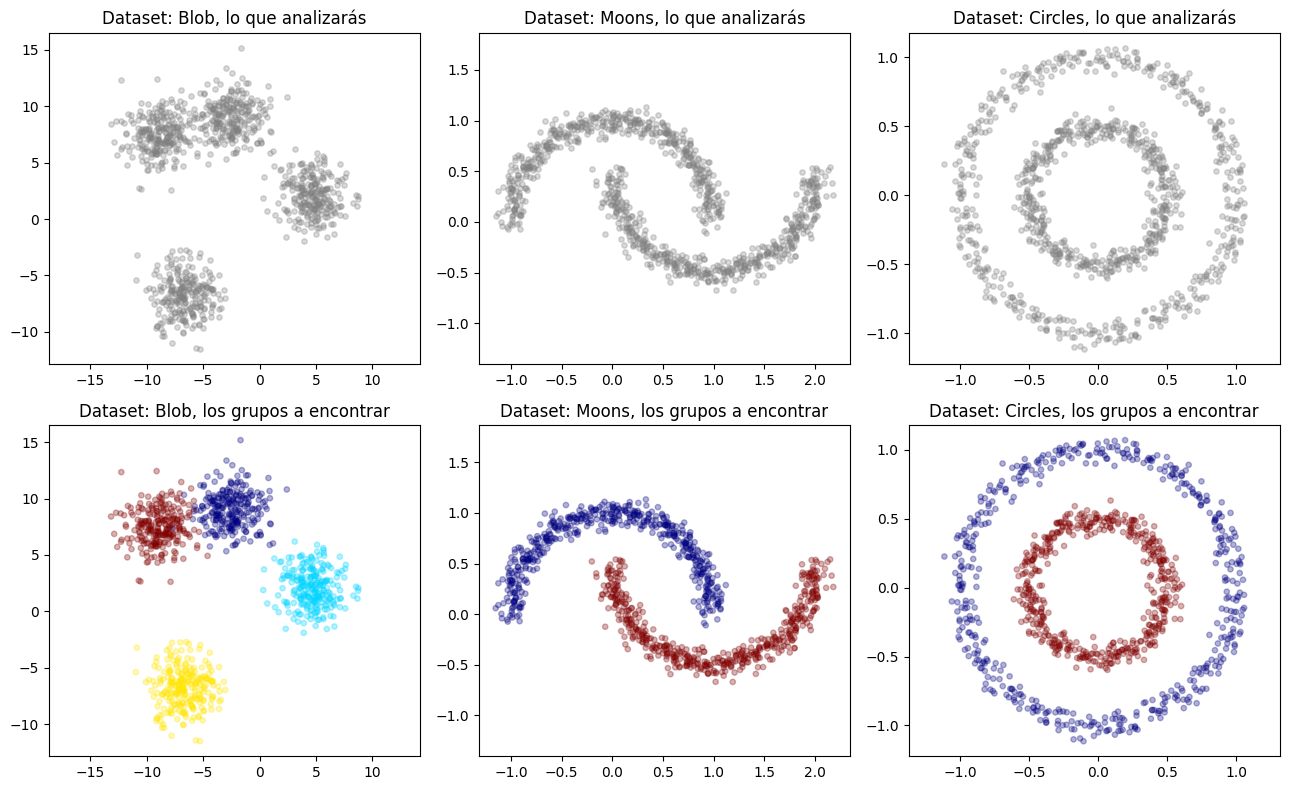

In [4]:
fig, axis = plt.subplots(2, 3, figsize=(13, 8))
for i, (X, y, ax, name) in enumerate(zip([X_blobs, X_moons, X_circles] * 2,
                                         [None] * 3 + [y_blobs, y_moons, y_circles],
                                         axis.reshape(-1),
                                         ['Blob', 'Moons', 'Circles'] * 2)):
    ax.set_title('Dataset: {}, '.format(name) + ('lo que analizarás' if i < 3 else 'los grupos a encontrar'))
    if y is not None:
        ax.scatter(X[:,0], X[:,1], s=15, c=y, alpha=.3, cmap='jet')
    else:
        ax.scatter(X[:,0], X[:,1], s=15, c='gray', alpha=.3, cmap='jet')
    ax.axis('equal')
plt.tight_layout()

### 1 a. K-means

En este apartado se pide probar el algoritmo *k-means* sobre los tres datasets presentados anteriormente ajustando con los parámetros adecuados y analizar sus resultados.

In [5]:
X, y = X_blobs, y_blobs

Para estimar el número de clusters a detectar por *k-means*. Una técnica para estimar $k$ es, como se explica en la teoría:
> Los criterios anteriores (minimización de distancias intra grupo o maximización de distancias inter grupo) pueden usarse para establecer un valor adecuado para el parámetro k. Valores k para los que ya no se consiguen mejoras significativas en la homogeneidad interna de los segmentos o la heterogeneidad entre segmentos distintos, deberían descartarse.

Lo que popularmente se conocer como *regla del codo*.

Primero es necesario calcular la suma de los errores cuadráticos ([*SSE*](https://bl.ocks.org/rpgove/0060ff3b656618e9136b)) que consiste en la suma de todos los errores (distancia de cada punto a su centroide asignado) al cuadrado.

$$SSE = \sum_{i=1}^{K} \sum_{x \in C_i} euclidean(x, c_i)^2$$

Donde $K$ es el número de clusters a buscar por *k-means*, $x \in C_i$ son los puntos que pertenecen a i-ésimo cluster, $c_i$ es el centroide del cluster $C_i$ (al que pertenece el punto $x$), y $euclidean$ es la [distancia euclídea](https://en.wikipedia.org/wiki/Euclidean_distance).

Este procedimiento realizado para cada posible valor $k$, resulta en una función monótona decreciente, donde el eje $x$ representa los distintos valores de $k$, y el eje $y$ el $SSE$. Intuitivamente se podrá observar un significativo descenso del error, que indicará el valor idóneo de $k$.

**Se pide realizar la representación gráfica de la regla del codo junto a su interpretación, utilizando la librería ```matplotlib``` y la implementación en scikit-learn de [*k-means*](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).**

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de la regla del codo en el dataset Blobs.
</div>

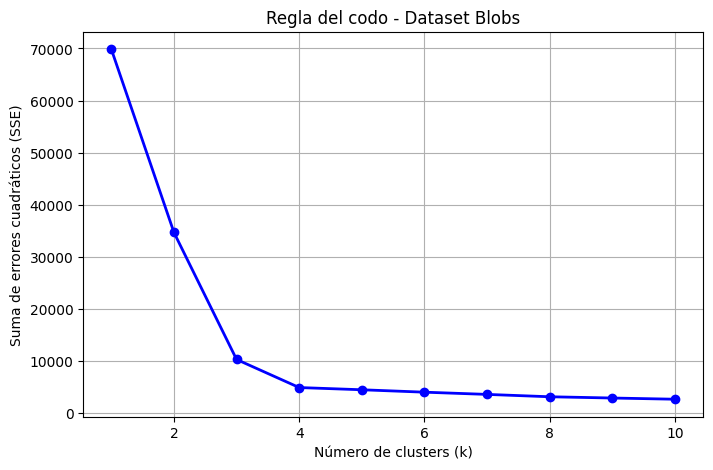

In [6]:
# =============================================================
# Cálculo y visualización de la regla del codo
# =============================================================

# Semilla para reproducibilidad
seed = 100

# Rango de posibles valores de k
k_values = range(1, 11)

# Lista para almacenar los valores SSE (inertia_ en sklearn)
sse = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=seed)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)  # inertia_ = suma de distancias cuadradas (SSE)

# Representación gráfica
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, 'bo-', linewidth=2)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Suma de errores cuadráticos (SSE)')
plt.title('Regla del codo - Dataset Blobs')
plt.grid(True)
plt.savefig(r'../Visualizaciones/regla_del_codo_blobs.png', dpi=300)
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué se interpreta en la gráfica? ¿Cómo podría mejorarse la elección de $k$?.  
</div>

La gráfica muestra la **Suma de Errores Cuadráticos (SSE)** en función del número de clusters ($k$). Se observa:

- **Decrecimiento pronunciado**: Entre $k$ = 1 y $k$ = 4, el SSE disminuye drásticamente (de ~70,000 a ~5,000).
- **"Codo" en $k$ = 4:** A partir de $k$ = 4, la reducción del error se vuelve mucho más gradual y marginal.
- **Estabilización**: Desde $k$ = 5 en adelante, la mejora es prácticamente imperceptible.

Por lo tanto, el punto óptimo está claramente en **$k$ = 4**, ya que añadir más clusters no proporciona una reducción significativa del error. Este es el "codo" de la curva, donde se equilibra la complejidad del modelo con la calidad del agrupamiento.

Además de la regla del codo, se podría utilizar:

- **Método del Silhouette Score**: Mide qué tan bien está asignado cada punto a su cluster comparado con otros clusters (valores entre -1 y 1, siendo 1 óptimo).
- **Método de Gap Statistic**: Compara la SSE observada con la esperada bajo una distribución de referencia aleatoria.

> Estos dos últimos métodos se pueden revisar más a fondo en: https://openaccess.uoc.edu/server/api/core/bitstreams/859ca353-d4f7-4448-a284-6454decfc950/content

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de los grupos en el dataset Blobs.
</div>

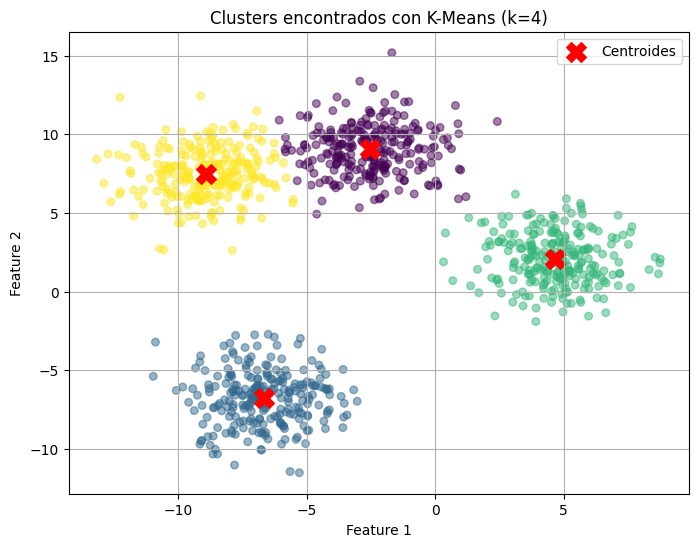

In [7]:
# ==========================================================
# Cálculo y visualización de los grupos
# ==========================================================

# Aplicamos KMeans con el k óptimo (4)
k_optimo = 4
kmeans = KMeans(n_clusters=k_optimo, random_state=seed)
y_pred = kmeans.fit_predict(X)

# Obtenemos los centroides
centroides = kmeans.cluster_centers_

# Visualización de los clusters encontrados
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=30, cmap='viridis', alpha=0.5)
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.title('Clusters encontrados con K-Means (k=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.savefig(r'../Visualizaciones/clusters_kmeans_blobs.png', dpi=300)
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

`K-Means` ha identificado **4 clusters bien diferenciados**:

- **Cluster amarillo** (arriba-izquierda): ~(-9, 7).
- **Cluster morado** (centro-arriba): ~(-2, 9).
- **Cluster verde** (derecha-centro): ~(5, 2). 
- **Cluster azul** (abajo-izquierda): ~(-7, -7).

Los centroides (marcas rojas en X) están bien posicionados en el centro de cada agrupación natural de puntos.

El algoritmo `K-Means` ha funcionado **excepcionalmente bien** en este caso por varios motivos:

- **Separación clara**: Los clusters tienen una separación espacial evidente, con poca o ninguna superposición entre grupos
- **Forma esférica**: Los clusters son aproximadamente circulares/esféricos, lo cual es ideal para `K-Means` (que asume distancias euclidianas y clusters convexos)
- **Tamaños similares**: Los 4 clusters tienen aproximadamente el mismo número de puntos, lo que evita que `K-Means` favorezca clusters más grandes
- **Densidad homogénea**: La densidad de puntos dentro de cada cluster es relativamente uniforme
- **Dataset sintético "Blobs"**: Este dataset fue generado específicamente con `make_blobs`, diseñado para crear clusters gaussianos bien separados (el escenario ideal para `K-Means`).

Por lo tanto, `K-Means` es perfecto para este tipo de datos. En casos reales con clusters de formas irregulares, densidades variables o con ruido, otros algoritmos como `DBSCAN` o *clustering* jerárquico podrían ser más apropiados.

In [8]:
X, y = X_moons, y_moons

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de la regla del codo en el dataset Moons.
</div>

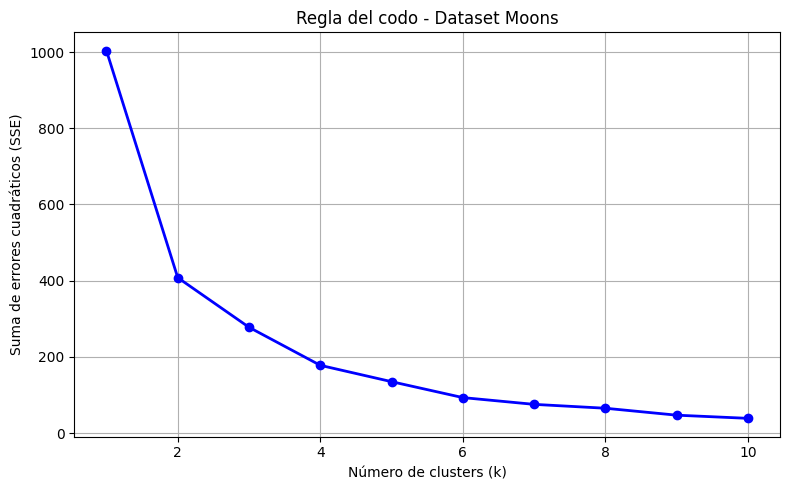

In [9]:
# ==========================================================
# Regla del codo - Dataset Moons
# ==========================================================

# Rango de valores posibles para k
k_values = range(1, 11)
sse = []

# Calcular SSE para cada k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=seed)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# Graficar la regla del codo
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, 'bo-', linewidth=2)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Suma de errores cuadráticos (SSE)')
plt.title('Regla del codo - Dataset Moons')
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/regla_del_codo_moons.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué se interpreta en la gráfica? ¿Cómo podría mejorarse la elección de $k$?.  
</div>

La gráfica muestra un comportamiento muy diferente al caso de "blobs":

- **Decrecimiento continuo suave**: El SSE disminuye de forma gradual desde $k$ = 1 (~1000) hasta $k$=10 (~40).
- **Sin "codo" claro**: No hay un punto de inflexión obvio donde la mejora se estabilice dramáticamente.
- **Ambigüedad**: Podríamos considerar  $k$ = 2, $k$ = 3 o $k$ = 4 como posibles "codos" débiles.
- **Reducción significativa hasta $k$=4**: La mayor parte de la reducción ocurre entre $k$ = 1 y $k$ = 4.

La ausencia de un codo claro es una señal de alarma que indica que `K-Means` no es apropiado para este tipo de datos. La estructura subyacente no consiste en clusters esféricos/convexos.

Por lo tanto para este dataset específico podría mejorarse la eleccion de $k$:

- **Silhouette Score**: Probablemente mostraría valores bajos incluso para $k$ = 2, confirmando que `K-Means` no captura bien la estructura.
- **Inspección visual previa**: Una simple visualización 2D revelaría inmediatamente que los datos tienen forma de "lunas" no convexas.

Con todo esto, el analista deberia  **considerar otros algoritmos** puesto que la regla del codo sugiere que quizás no deberíamos usar `K-Means`

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de los grupos en el dataset Moons.
</div>

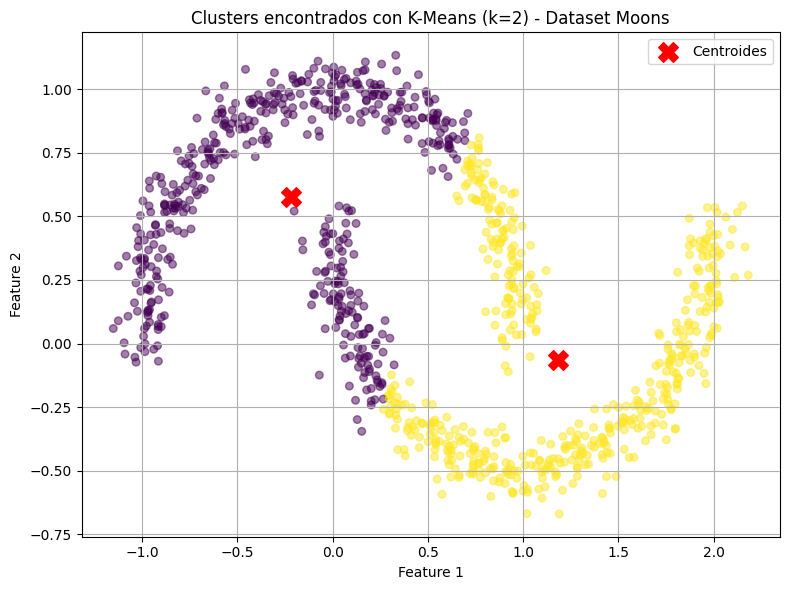

In [10]:
# ==========================================================
# Visualización de clusters - Dataset Moons
# ==========================================================

# Suponemos que la regla del codo sugiere k=2 (aunque K-means no agrupa bien este dataset)
k_optimo = 2

kmeans = KMeans(n_clusters=k_optimo, random_state=seed)
y_pred = kmeans.fit_predict(X)
centroides = kmeans.cluster_centers_

# Visualización de los clusters encontrados
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=30, cmap='viridis', alpha=0.5)
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.title('Clusters encontrados con K-Means (k=2) - Dataset Moons')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/clusters_kmeans_moons.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

`K-Means` con $k$ = 2 ha producido un resultado **para nada satisfactorio**:

- **Cluster morado**: Agrupa la parte superior de ambas lunas + parte de la izquierda.
- **Cluster amarillo**: Agrupa la parte inferior/derecha de ambas lunas.
- **División artificial**: Los centroides están posicionados en (~-0.3, 0.6) y (~1.2, -0.1), dividiendo el espacio de forma lineal/vertical, no siguiendo las formas naturales.

Con la imagen superior se observa por tanto que la estructura real del dataset son dos lunas entrelazadas (semicírculos cóncavos), pero `K-Means` ha creado una división casi vertical que corta transversalmente ambas lunas.

Las razones fundamentales son las limitaciones inherentes de `K-Means`:
1. **Asunción de convexidad**: `K-Means` asume que los clusters son convexos (formas que se pueden "abrazar" con una línea recta sin salirse). Las lunas son cóncavas y tienen forma de media luna, violando completamente esta asunción.
2. **Uso de distancia euclidiana**: `K-Means` asigna puntos al centroide más cercano usando distancia euclidiana (línea recta). En este caso:
   - Puntos en el **centro del espacio** están equidistantes de ambas lunas.
   - La decisión se vuelve arbitraria y se basa en la posición de los centroides iniciales
   - No captura la **conectividad topológica** de las lunas.

3. **Fronteras lineales**: Las fronteras de decisión de `K-Means` son hiperplanos (líneas rectas en 2D). Es imposible separar dos lunas entrelazadas con una línea recta.
4. **Optimización basada en centroides**: El algoritmo minimiza la distancia cuadrática a centroides, lo que favorece clusters esféricos de tamaño similar. Las lunas tienen forma alargada y curvada.

> Fuente [Tecnicas de clustering](https://openaccess.uoc.edu/server/api/core/bitstreams/859ca353-d4f7-4448-a284-6454decfc950/content)

In [11]:
X, y = X_circles, y_circles

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de la regla del codo en el dataset Circles.
</div>

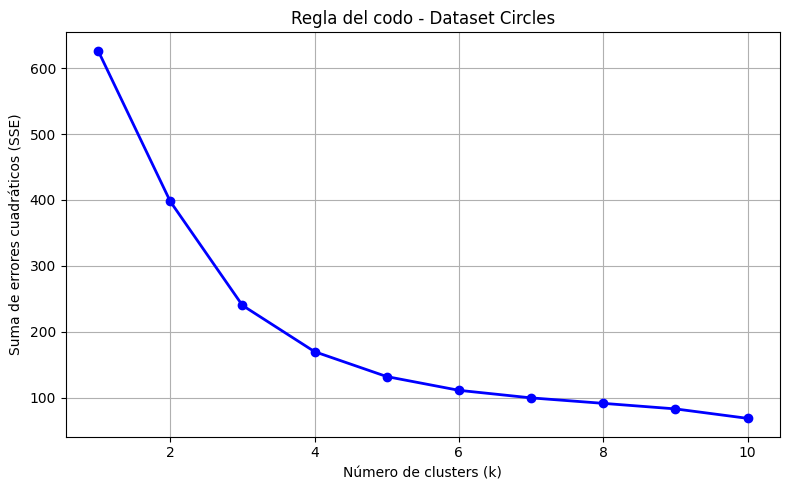

In [12]:
# ==========================================================
# Regla del codo - Dataset Circles
# ==========================================================

# Rango de valores posibles para k
k_values = range(1, 11)
sse = []

# Calcular SSE (inercia) para cada k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=seed)
    kmeans.fit(X_circles)
    sse.append(kmeans.inertia_)

# Graficar la regla del codo
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, 'bo-', linewidth=2)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Suma de errores cuadráticos (SSE)')
plt.title('Regla del codo - Dataset Circles')
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/regla_del_codo_circles.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué se interpreta en la gráfica? ¿Cómo podría mejorarse la elección de $k$?.  
</div>

La curva del codo muestra:

- **Decrecimiento continuo y gradual**: El SSE disminuye suavemente desde ~625 ($k$ = 1) hasta ~65 ($k$ = 10).
- **Sin codo definido**: Similar al caso "moons", no hay un punto de inflexión claro.
- **Posible "codo débil" en $k$ = 2-3**: Hay una ligera disminución de la pendiente alrededor de $k$ = 2, pero continúa bajando significativamente después.
- **Reducción sostenida**: La mejora continúa incluso hasta $k$ = 7-8, lo cual es sospechoso.

Por lo tanto, la ausencia de un codo pronunciado es otra señal de advertencia. Si tuviera que elegir basándome solo en esta gráfica, $k$ = 2 podría parecer razonable (lo cual tiene sentido conceptualmente: círculo interior vs exterior), pero la curva sugiere que `K-Means` está luchando para encontrar una estructura natural.

Una vez más, para este dataset podría mejorarse la eleccion de $k$ usando:

- **Silhouette Score**: Probablemente mostraría valores muy bajos para k=2, indicando que los clusters están mal definidos o se superponen según la métrica de K-Means
- **Visualización exploratoria**: Una simple gráfica 2D revelaría inmediatamente la estructura de círculos concéntricos

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de los grupos en el dataset Circles.
</div>

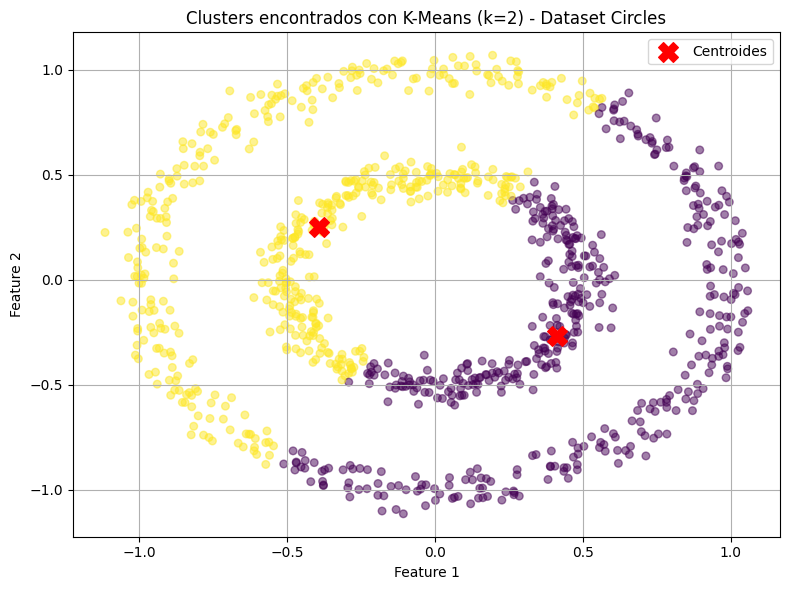

In [13]:
# ==========================================================
# Visualización de clusters - Dataset Circles
# ==========================================================

# La regla del codo podría sugerir k=2 (pero no representa bien los círculos)
k_optimo = 2

kmeans = KMeans(n_clusters=k_optimo, random_state=seed)
y_pred = kmeans.fit_predict(X)
centroides = kmeans.cluster_centers_

# Visualización de los clusters encontrados
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=30, cmap='viridis', alpha=0.5)
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.title('Clusters encontrados con K-Means (k=2) - Dataset Circles')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/clusters_kmeans_circles.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

`K-Means` con $k$ = 2 ha producido un resultado **desastroso y completamente incorrecto**:

- **Cluster amarillo** (izquierda): Agrupa aproximadamente la mitad izquierda de ambos círculos.
- **Cluster morado** (derecha): Agrupa aproximadamente la mitad derecha de ambos círculos.
- **División vertical**: Los centroides están en aproximadamente (-0.4, 0.25) y (0.4, -0.25), creando una partición vertical/diagonal del espacio.
- **Estructura real ignorada**: El algoritmo ha ignorado que hay un círculo pequeño interior y un anillo exterior.

Mientras que la **estructura real** consiste en dos círculos concéntricos (uno pequeño centrado en el origen y un anillo exterior), `K-Means` los ha cortado verticalmente como si fueran una pizza.

Este es el peor caso posible para K-Means. Las razones son:
1. **Imposibilidad geométrica con distancia euclidiana**: K-Means usa distancia euclidiana desde centroides. Es decir, si se considera un punto en el círculo interior:
   - Su distancia a cualquier punto del círculo exterior puede ser similar o menor que la distancia a otro punto del círculo interior en el lado opuesto
   - Los dos centroides encontrados están aproximadamente equidistantes de muchos puntos en ambos círculos
   - Por lo que, no hay forma de separar círculos concéntricos usando solo distancia euclidiana desde dos puntos centrales
2. **Estructura no convexa y anidada**: `K-Means` solo puede crear regiones mediante hiperplanos divisores (fronteras lineales), lo cual es imposible para círculos concéntricos y anidados.
3. **Centroides mal posicionados**: Los centroides de `K-Means` se posicionan en el centro de masa de los puntos asignados, lo cual minimiza el SSE global pero no captura la estructura real.
4. **Falsa simetría**: La distribución es radialmente simétrica, por lo que cualquier división lineal que pase por el centro tiene un SSE similar. Esto es por que, `K-Means` converge a una de estas divisiones arbitrarias basándose en la inicialización aleatoria.

### 1 b. Algoritmos basados en densidad: DBScan

En este apartado se pide aplicar clustering por densidad como [DBSCAN](https://en.wikipedia.org/wiki/DBSCAN) a los datasets anteriores para detectar los grupos subyacentes.

In [14]:
X, y = X_blobs, y_blobs

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de <a href="http://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html">DBSCAN en scikit-learn</a> jugando con los parámetros <i>eps</i> y <i>min_samples</i> para encontrar los grupos (y <i>outliers</i>) del dataset Blobs.
</div>

DBSCAN - Blobs: 2 clusters detectados, 10 outliers


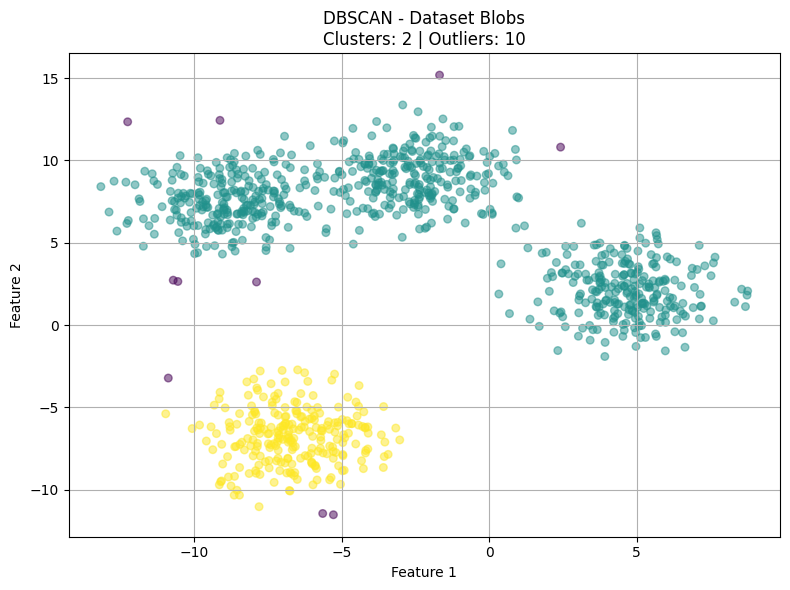

In [15]:
# ==========================================================
# DBSCAN - Dataset Blobs
# ==========================================================

# Ajustamos DBSCAN según dispersión
dbscan_blobs = DBSCAN(eps=1.5, min_samples=5)
y_pred_blobs = dbscan_blobs.fit_predict(X)

# Identificar ruido (outliers = etiqueta -1)
n_clusters = len(set(y_pred_blobs)) - (1 if -1 in y_pred_blobs else 0)
n_noise = list(y_pred_blobs).count(-1)

print(f"DBSCAN - Blobs: {n_clusters} clusters detectados, {n_noise} outliers")

# Visualización
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y_pred_blobs, cmap='viridis', s=30, alpha=0.5)
plt.title(f'DBSCAN - Dataset Blobs\nClusters: {n_clusters} | Outliers: {n_noise}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/dbscan_blobs.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

El proceso de **clustering `DBSCAN`** ha arrojado resultados inesperados para este conjunto de datos, agrupando los **cuatro clusters naturales** en solo **dos grandes grupos** y detectando **diez puntos atípicos (*outliers*)**:

- **Cluster Superior** (Turquesa/Verde-Azulado): Este grupo incorrectamente fusionó lo que deberían ser tres clusters separados.
- **Cluster Inferior** (Amarillo): Este grupo solo representa correctamente a uno de los cuatro clusters originales.
- **Outliers Detectados** (10): Se identificaron diez puntos atípicos (morados), dispersos en el espacio, lo cual es una detección correcta de puntos aislados.

La causa principal del resultado radica en la elección de un parámetro $\epsilon$ (eps) excesivamente grande para este conjunto de datos.$\epsilon$ (eps) = 1.5. En este dataset de "blobs" (grupos con forma de mancha), la distancia de 1.5 es lo suficientemente grande como para "conectar" clusters adyacentes que deberían estar separados. Los puntos ubicados en los bordes de clusters cercanos están a menos de 1.5 unidades de distancia, creando "puentes" de densidad que fuerzan a `DBSCAN` a fusionar varios grupos en uno solo. Por lo tanto, al establecer $\epsilon = 1.5$, la definición de "densamente conectado" se expandió tanto que incluyó los puentes entre los clusters, lo que llevó a la fusión de los grupos superiores.

Posibles formas de mejorar el clustering seria ajustando los parámetros, aumentando `Min_Samples` y reduciendo $\epsilon$ para que el procedimiento identifique más agrupaciones.

In [16]:
X, y = X_moons, y_moons

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de DBSCAN jugando con los parámetros <i>eps</i> y <i>min_samples</i> para encontrar los grupos (y <i>outliers</i>) del dataset Moons.
</div>

DBSCAN - Moons: 2 clusters detectados, 0 outliers


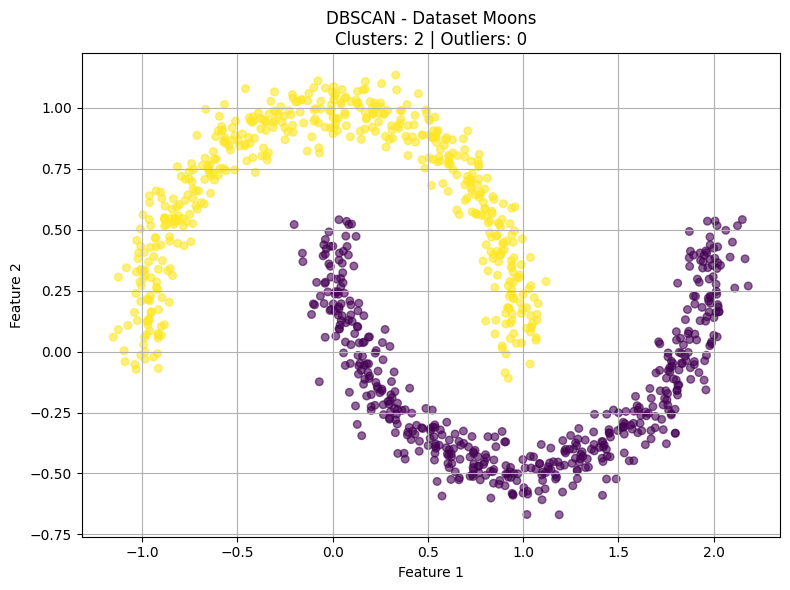

In [17]:
# ==========================================================
# DBSCAN - Dataset Moons
# ==========================================================

# Ajustar DBSCAN — este dataset requiere eps pequeño para captar la forma
dbscan_moons = DBSCAN(eps=0.2, min_samples=5)
y_pred_moons = dbscan_moons.fit_predict(X)

n_clusters = len(set(y_pred_moons)) - (1 if -1 in y_pred_moons else 0)
n_noise = list(y_pred_moons).count(-1)

print(f"DBSCAN - Moons: {n_clusters} clusters detectados, {n_noise} outliers")

# Visualización
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y_pred_moons, cmap='viridis', s=30, alpha=0.6)
plt.title(f'DBSCAN - Dataset Moons\nClusters: {n_clusters} | Outliers: {n_noise}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/dbscan_moons.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

El proceso de **clustering `DBSCAN`** ha arrojado resultados perfectos para este conjunto de datos, logrando la **separación exacta** de los dos clusters con forma de luna y **no detectando puntos atípicos (*outliers*)**:

- **Cluster Amarillo**: Representa la Luna Superior completa.
- **Cluster Morado**: Representa la Luna Inferior completa.
- **Outliers Detectados (0)**: Se logró una identificación excelente al no etiquetar ningún punto como atípico.
  
Este resultado satisfactorio se debe a una combinación de la naturaleza del algoritmo `DBSCAN` y el ajuste preciso de sus parámetros:

1. **Captura de conectividad**: A diferencia de algoritmos como K-Means, DBSCAN no asume que los clusters son esféricos o convexos. Su capacidad para identificar regiones de alta densidad conectadas le permite:
   - Seguir estructuras curvas y alargadas (como las lunas).
   - Ignorar la forma geométrica y centrarse solo en la densidad.
2. **Parámetros ajustados correctamente**: El éxito se debe a que los parámetros $\epsilon$ (eps) y $\text{min\_samples}$ fueron establecidos para reflejar la densidad y separación del dataset:
   - $\epsilon$ (eps) = 0.2: Este valor es lo suficientemente pequeño como para no conectar las dos lunas (que están separadas por aproximadamente 0.5 unidades). A la vez, es lo suficientemente grande como para conectar los puntos DENTRO de cada luna (donde la distancia típica entre vecinos es de 0.1 a 0.15).
   - $\text{min\_samples} = 5$: Este valor es adecuado para la densidad de las lunas, lo que ayuda a filtrar el ruido sin fragmentar los clusters principales.
3. **Caso ideal para DBSCAN**: El dataset de las lunas representa el caso de uso ideal para DBSCAN porque:
   - Tienen una **densidad uniforme**.
   - Están **bien separadas** en el espacio (un hueco claro entre ellas).
   - Cada luna es inherentemente una **región densa y conectada**.

In [18]:
X, y = X_circles, y_circles

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de DBSCAN jugando con los parámetros <i>eps</i> y <i>min_samples</i> para encontrar los grupos (y <i>outliers</i>) del dataset Circles.
</div>

DBSCAN - Circles: 2 clusters detectados, 0 outliers


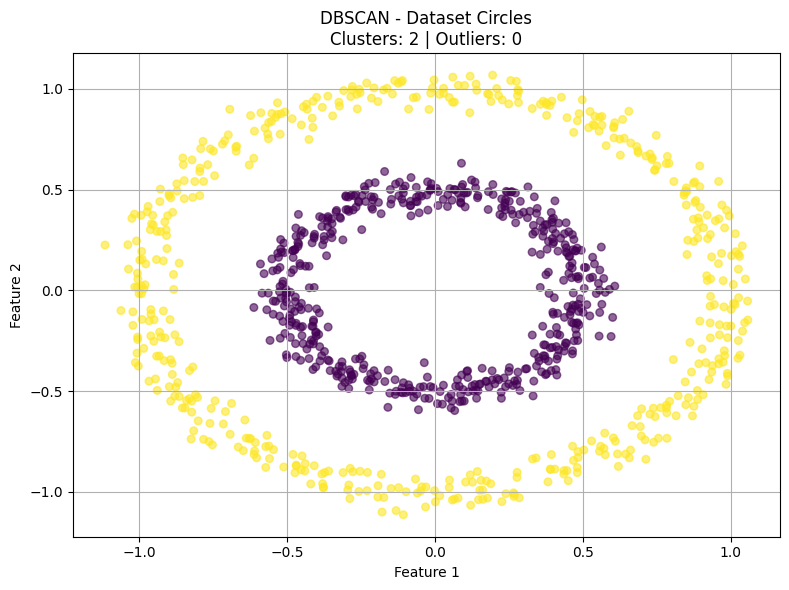

In [19]:
# ==========================================================
# DBSCAN - Dataset Circles
# ==========================================================

# Ajustar DBSCAN — requiere eps moderado
dbscan_circles = DBSCAN(eps=0.2, min_samples=5)
y_pred_circles = dbscan_circles.fit_predict(X)

n_clusters = len(set(y_pred_circles)) - (1 if -1 in y_pred_circles else 0)
n_noise = list(y_pred_circles).count(-1)

print(f"DBSCAN - Circles: {n_clusters} clusters detectados, {n_noise} outliers")

# Visualización
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y_pred_circles, cmap='viridis', s=30, alpha=0.6)
plt.title(f'DBSCAN - Dataset Circles\nClusters: {n_clusters} | Outliers: {n_noise}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/dbscan_circles.png', dpi=300)
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

El proceso de **clustering `DBSCAN`** ha evidencia **resultados muy buenos** para este conjunto de datos, logrando una **separación perfecta** de los dos clusters concéntricos (círculo interior y anillo exterior) y **no detectando puntos atípicos (*outliers*)**:
- **Cluster Amarillo**: Representa el Círculo Exterior (Anillo) completo.
- **Cluster Morado**: Representa el Círculo Interior completo.
- **Outliers Detectados (0)**: Se obtuvo una identificación ideal al no etiquetar ningún punto como atípico.

El éxito de este resultado se debe a la ventaja de `DBSCAN` para manejar estructuras no convexas o anidadas, sumada a un ajuste de parámetros muy preciso:

1. **Estructuras Anidadas**: `DBSCAN` sobresale en este tipo de dataset porque:No utiliza centroides ni distancias a puntos centrales, que son la debilidad de K-Means en estructuras concéntricas.Solo considera la conectividad y densidad local.El círculo interior y el anillo exterior son, para DBSCAN, simplemente dos regiones densas espacialmente separadas.
2. **Parámetros Óptimos**: El éxito se debe a que los parámetros $\epsilon$ (eps) y $\text{min\_samples}$ fueron establecidos para reflejar la densidad y separación del dataset:
   - El parámetro $\epsilon$ (eps) de 0.2 fue crucial para garantizar que la brecha entre el anillo y el círculo interior no se "conectara". Este valor es menor que la distancia de separación entre los dos clusters (que es aproximadamente 0.3-0.4 unidades). Esto asegura que los **puntos del círculo interior NO puedan alcanzar el anillo**, evitando la fusión de los grupos. Simultáneamente, 0.2 es lo suficientemente grande para que los puntos **DENTRO** de cada estructura (con distancias típicas de vecinos de 0.1-0.15) se consideren densamente conectados, permitiendo la formación de los clusters.
   - $\text{min\_samples} = 5$: Este valor garantiza que solo las regiones con suficiente densidad (es decir, el círculo y el anillo) sean consideradas clusters válidos.

### 1 c. Algoritmos jerárquicos

En este apartado se pide visualizar mediante un [dendrograma](https://en.wikipedia.org/wiki/Dendrogram) la construcción progresiva de los grupos mediante un algoritmo jerárquico aglomerativo (estrategia *bottom-up*). Con ello se pretende encontrar un método gráfico para entender el comportamiento del algoritmo y encontrar los *clusters* deseados en cada dataset.

In [20]:
X, y = X_blobs, y_blobs

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de <a href="https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html">clustering jerárquico de scipy</a> probando distintos <a href="https://en.wikipedia.org/wiki/Hierarchical_clustering#Linkage_criteria">criterios de enlace o <i>linkage</i></a> permitiendo identificar los clusters subyacentes (mostrando su resultado) y su dendrograma para el dataset Blobs.<br>
Puedes importar las librerías necesarias para ello.
</div>

In [21]:
import os

# Crear carpeta de salida
output_dir = r"../Visualizaciones/"
os.makedirs(output_dir, exist_ok=True) # Ejecutar solo si no se ha creado ya

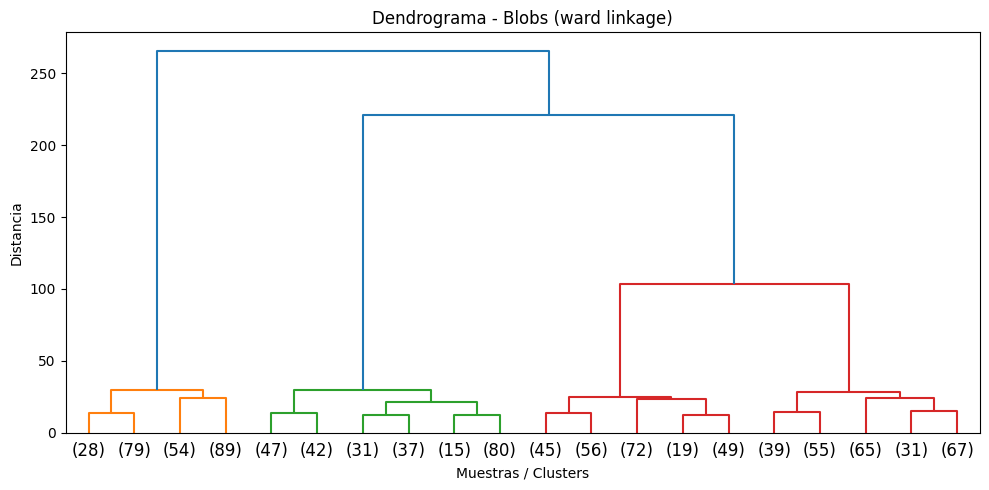

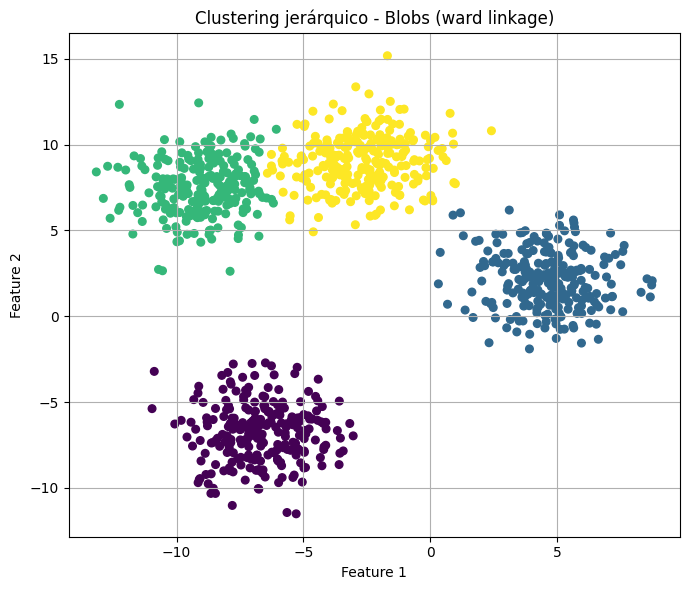

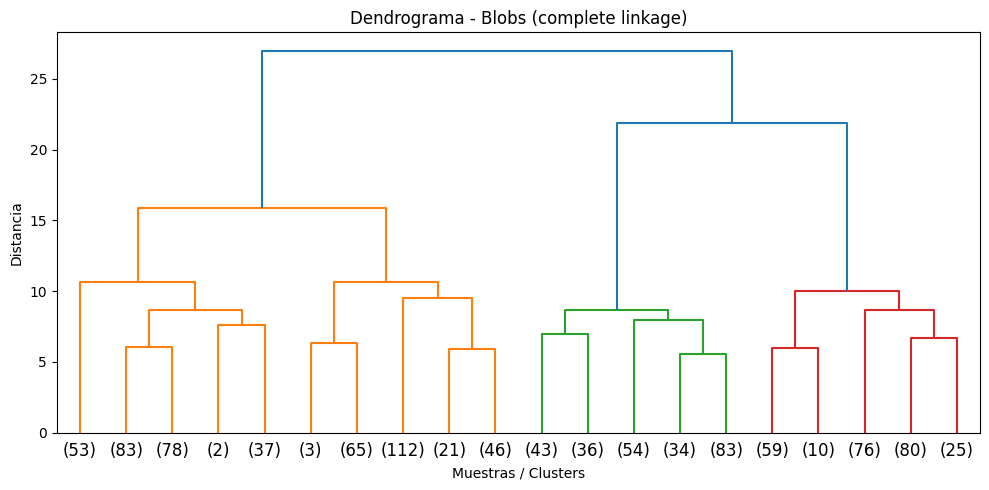

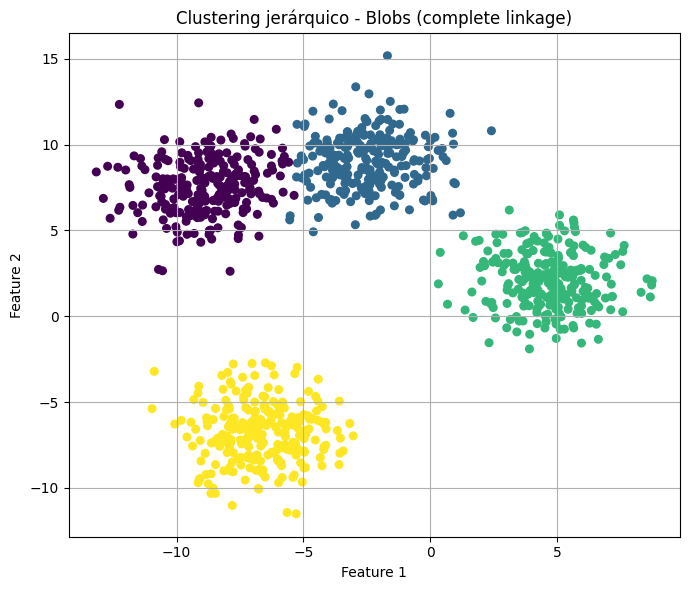

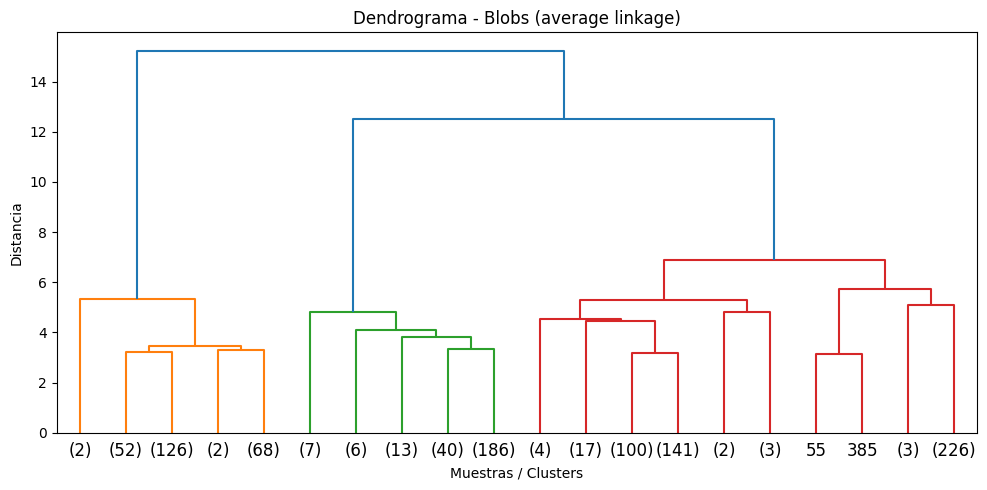

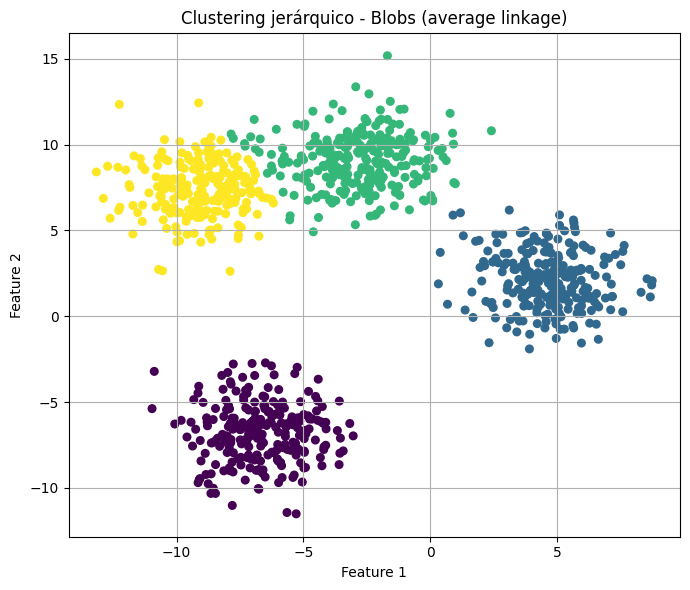

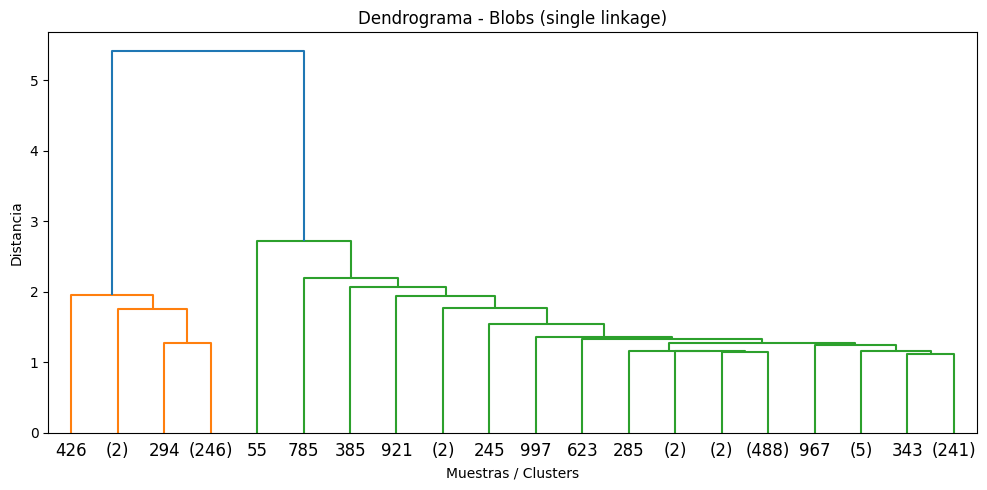

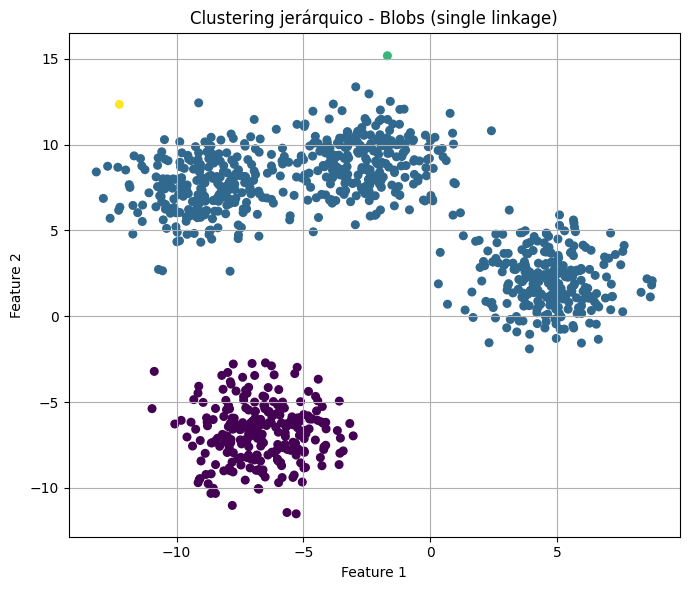

In [22]:
# ==========================================================
# Clustering jerárquico - Dataset Blobs
# ==========================================================

# Distinctos enlaces ("linkage") probados: 'ward', 'complete', 'average', 'single'
linkages = ['ward', 'complete', 'average', 'single']

for method in linkages:
    Z = linkage(X, method=method)

    # Dendrograma
    plt.figure(figsize=(10, 5))
    dendrogram(Z, truncate_mode='lastp', p=20)
    plt.title(f"Dendrograma - Blobs ({method} linkage)")
    plt.xlabel("Muestras / Clusters")
    plt.ylabel("Distancia")
    plt.tight_layout()
    ruta_dendo = os.path.join(output_dir, f"dendrograma_blobs_{method}.png")
    plt.savefig(ruta_dendo, dpi=300)
    plt.show()

    # Cortar el dendrograma para obtener clusters
    y_pred = fcluster(Z, t=4, criterion='maxclust')

    # Visualización de clusters resultantes
    plt.figure(figsize=(7,6))
    plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=30)
    plt.title(f"Clustering jerárquico - Blobs ({method} linkage)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.tight_layout()

    ruta_clusters = os.path.join(output_dir, f"clusters_blobs_{method}.png")
    plt.savefig(ruta_clusters, dpi=300)
    plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Interpreta el dendrograma y comenta qué criterio de enlace se ha comportado mejor. ¿Por qué?
</div>

El análisis de los distintos **criterios de enlace (*linkage*)** muestra diferencias claras tanto en la estructura de los dendrogramas como en la calidad de los clusters obtenidos.

- **Average Linkage:**
  - El dendrograma obtenido con *average linkage* muestra una estructura clara y equilibrada, con cuatro ramas principales bien diferenciadas (colores naranja, verde, rojo y azul en los niveles bajos). Las fusiones iniciales se producen a distancias relativamente pequeñas, entre 3 y 5, mientras que la unión de los cuatro grupos principales ocurre a distancias mucho mayores, en torno a 12–15.
Este salto o “gap” entre niveles indica una separación natural en cuatro grupos bien definidos.

- **Complete Linkage:**
  - El dendrograma de *complete linkage* presenta una estructura algo más desbalanceada que la del método anterior. Se observan dos ramas principales que se fusionan a una distancia muy alta (alrededor de 26), y dentro de cada una hay subdivisiones que ocurren a distancias medias (entre 8 y 15).
  Las fusiones finales muestran una mayor dispersión en las alturas del dendrograma, reflejando cierta asimetría en la estructura jerárquica.

- **Single Linkage**

  - En este caso, el dendrograma revela un problema claro: una estructura extremadamente desbalanceada provocada por el conocido *[efecto cadena](https://openaccess.uoc.edu/server/api/core/bitstreams/6a121978-e877-4f5d-a76c-b6ff0138f8d1/content)* (*chaining*). La primera gran fusión ocurre a distancia muy baja (~2), y a partir de ahí aparece una rama azul dominante que crece progresivamente a medida que se van uniendo los puntos. No existe una separación clara en cuatro niveles distintos, y el dendrograma pierde legibilidad.

-  **Ward Linkage**
   - El dendrograma de *Ward linkage* es el más equilibrado y fácil de interpretar. Se observan cuatro ramas principales claramente separadas, con fusiones iniciales a distancias pequeñas (20–30) y un salto muy pronunciado antes de la fusión de los grupos principales, que se produce entre 100 y 250.
   Este gran salto facilita enormemente la identificación del punto de corte óptimo en el dendrograma.

Por lo tanto, **el método que mejor se comporta en este dataset es Ward linkage**. Su dendrograma es el más interpretable, con un salto muy claro entre fusiones internas y externas (20–30 frente a 100–250), lo que permite determinar fácilmente el número óptimo de clusters. Además, este criterio es coherente con la geometría de los datos: los *blobs* son aproximadamente esféricos y están bien separados, justo el tipo de estructura que *Ward* busca al minimizar la varianza interna.

In [23]:
X, y = X_moons, y_moons

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de <a href="https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html">clustering jerárquico de scipy</a> probando distintos <a href="https://en.wikipedia.org/wiki/Hierarchical_clustering#Linkage_criteria">criterios de enlace o <i>linkage</i></a> permitiendo identificar los clusters subyacentes (mostrando su resultado) y su dendrograma para el dataset Moons.<br>
Puedes importar las librerías necesarias para ello.
</div>

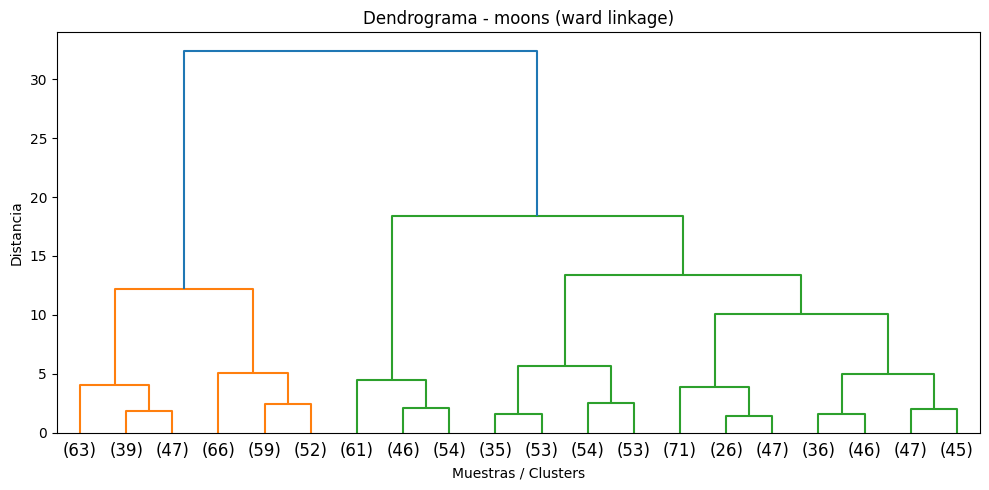

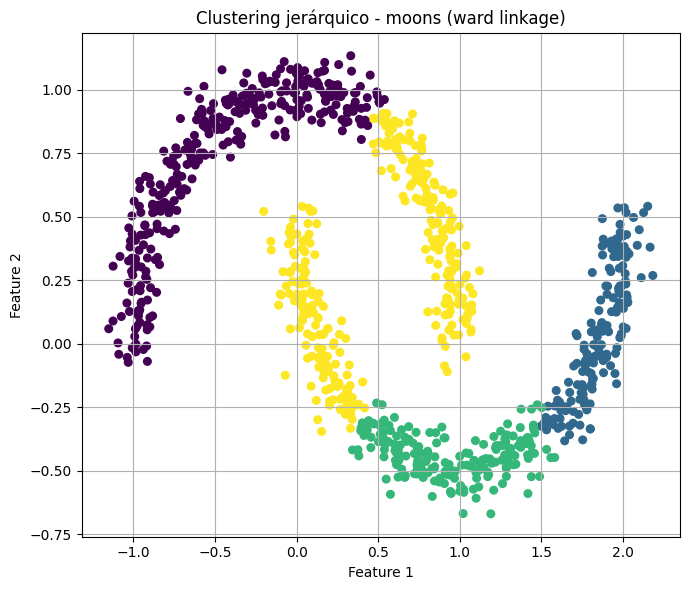

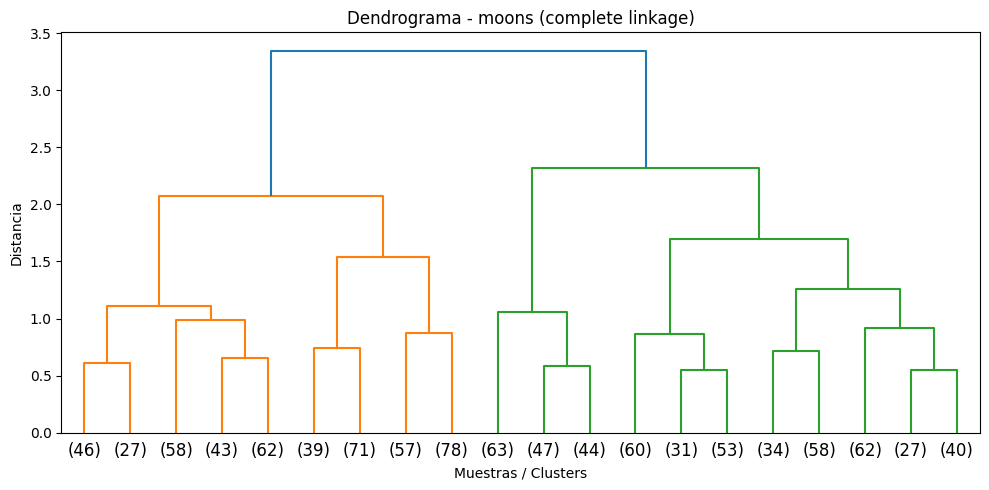

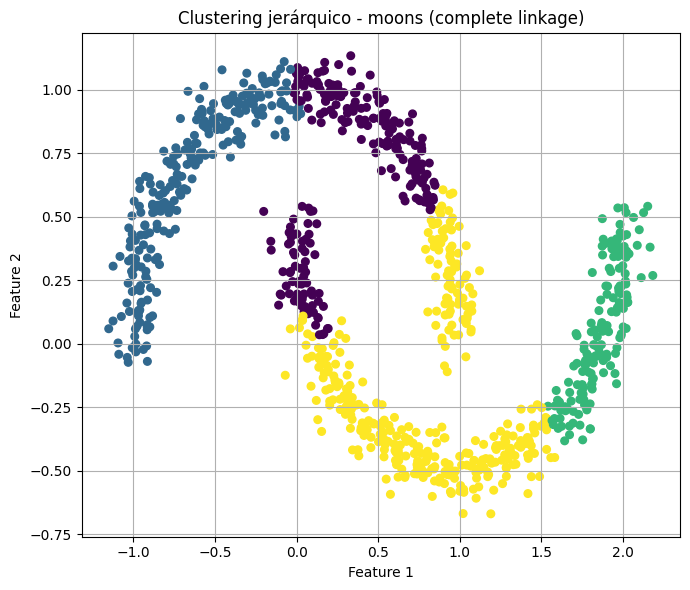

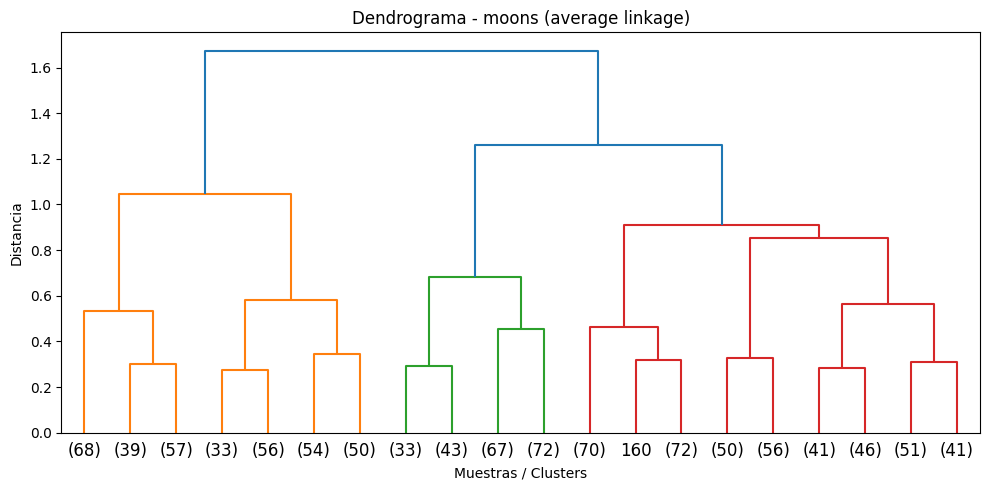

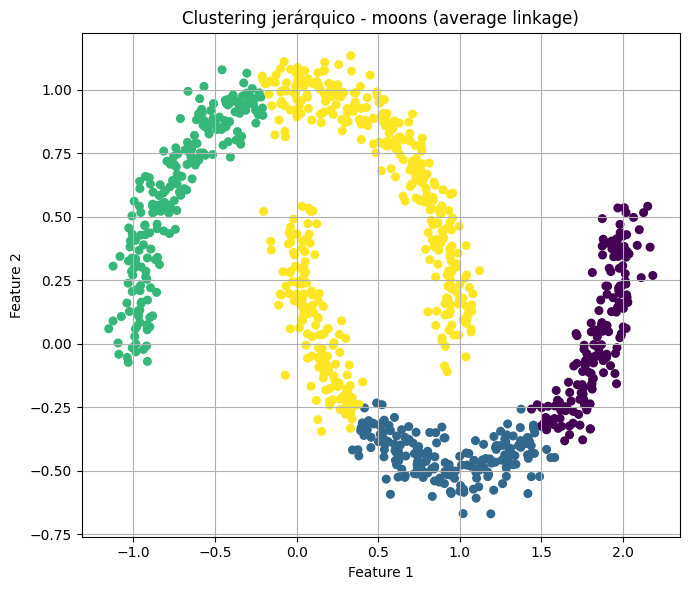

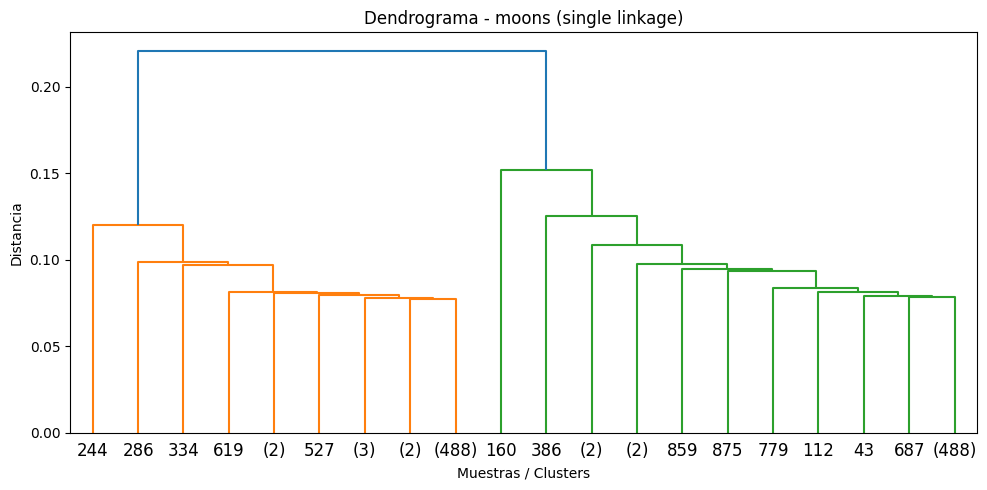

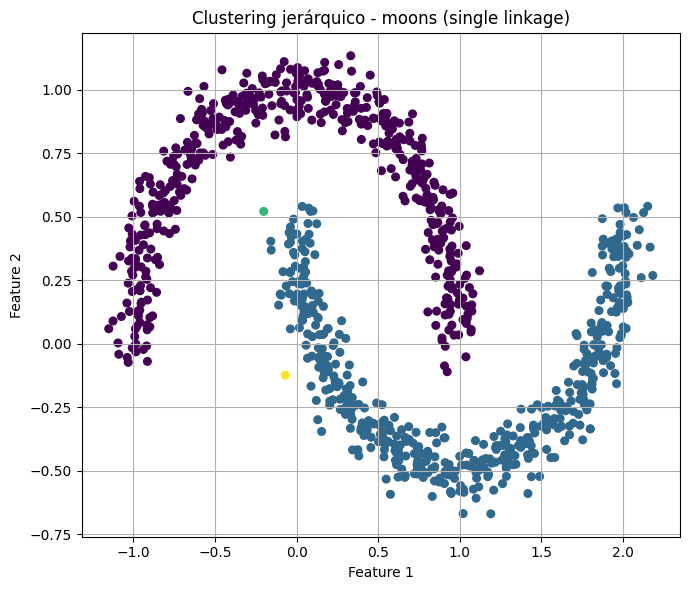

In [24]:
# ==========================================================
# Clustering jerárquico - Dataset moons
# ==========================================================

# Distinctos enlaces ("linkage") probados: 'ward', 'complete', 'average', 'single'
linkages = ['ward', 'complete', 'average', 'single']

for method in linkages:
    Z = linkage(X, method=method)

    # Dendrograma
    plt.figure(figsize=(10, 5))
    dendrogram(Z, truncate_mode='lastp', p=20)
    plt.title(f"Dendrograma - moons ({method} linkage)")
    plt.xlabel("Muestras / Clusters")
    plt.ylabel("Distancia")
    plt.tight_layout()
    ruta_dendo = os.path.join(output_dir, f"dendrograma_moons_{method}.png")
    plt.savefig(ruta_dendo, dpi=300)
    plt.show()

    # Cortar el dendrograma para obtener clusters
    y_pred = fcluster(Z, t=4, criterion='maxclust')

    # Visualización de clusters resultantes
    plt.figure(figsize=(7,6))
    plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=30)
    plt.title(f"Clustering jerárquico - moons ({method} linkage)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.tight_layout()
    ruta_clusters = os.path.join(output_dir, f"clusters_moons_{method}.png")
    plt.savefig(ruta_clusters, dpi=300)
    plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Interpreta el dendrograma y comenta qué criterio de enlace se ha comportado mejor. ¿Por qué?
</div>

Al aplicar los distintos criterios de enlace sobre el dataset *Moons*, los resultados muestran comportamientos muy contrastados según la forma de las lunas y la manera en que cada algoritmo calcula las distancias entre clusters.

- **Average Linkage:** 
  - El dendrograma muestra una estructura relativamente equilibrada, con fusiones progresivas desde distancias bajas hasta un salto final moderado. Aun así, el clustering **no logra reflejar correctamente la estructura en forma de lunas**, ya que las divisiones tienden a ser verticales o diagonales, dando lugar a varios grupos pequeños en lugar de las dos medias lunas esperadas. Esto ocurre porque el método **promedia las distancias** entre todos los puntos de los clusters, y en este dataset las lunas están separadas más claramente en dirección horizontal. El algoritmo, al centrarse en distancias promedio, prefiere dividir verticalmente, donde las separaciones medias son mayores, antes que seguir las curvas naturales.

- **Complete Linkage:** 
  - El dendrograma se vuelve más desbalanceado y las fusiones finales ocurren a distancias mucho más altas. Este método es especialmente sensible a la elongación de los grupos ([es sensible a los valores outliers](https://openaccess.uoc.edu/server/api/core/bitstreams/6a121978-e877-4f5d-a76c-b6ff0138f8d1/content)), ya que **se basa en la distancia máxima entre puntos**. Al intentar minimizar el diámetro de los clusters, tiende a cortar el espacio en franjas verticales que atraviesan ambas lunas, produciendo resultados completamente incorrectos. En lugar de identificar las dos formas curvas, el algoritmo crea divisiones artificiales que reducen el tamaño máximo de cada grupo, sacrificando la coherencia estructural.

- **Single Linkage** 
  - Por el contrario *single linkage* muestra un dendrograma extremadamente desbalanceado (efecto *chaining*), pero esta vez ese problema se convierte en una ventaja. Aunque la estructura parece caótica, el clustering resultante es casi perfecto, observando como cada luna queda representada como una cadena continua de puntos conectados. Esto es debido a que se fusionan grupos si existe al menos un par de puntos cercanos, lo que encaja de forma ideal con las lunas, ya que dentro de cada una hay una densa red de vecinos próximos, mientras que entre ellas existe un pequeño pero claro hueco. Así, el algoritmo sigue la conectividad de las curvas y logra una separación natural, con solo unos pocos puntos ambiguos.

- **Ward Linkage:** 
  - Ofrece un resultado algo mejor que *Complete*, pero sigue siendo **inadecuado para este tipo de estructura**. Su dendrograma presenta una gran rama dominante y un salto final muy alto, lo que refleja fusiones tardías y poco coherentes. Al **minimizar la varianza dentro de cada grupo**, *Ward* favorece clusters compactos y aproximadamente esféricos, una suposición que las lunas violan completamente. De modo que como las formas son cóncavas, los centroides caen fuera de las lunas, lo que confunde la asignación de puntos y provoca cortes diagonales que dividen los arcos naturales en segmentos artificiales.

Por lo tanto, el método que mejor se adapta al dataset *Moons* es claramente **Single Linkage**. Su sensibilidad a la conectividad local le permite seguir las formas curvadas sin imponer una estructura convexa ni depender de medidas globales de distancia. Volver a resaltar que, lo que en otros contextos sería una debilidad (la tendencia a encadenar puntos sucesivos) aquí se convierte en la clave para detectar las lunas con precisión. En cambio, *Complete* y *Ward* fallan al intentar imponer geometrías compactas, mientras que *Average* se queda en un punto intermedio..

In [25]:
X, y = X_circles, y_circles

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de <a href="https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html">clustering jerárquico de scipy</a> probando distintos <a href="https://en.wikipedia.org/wiki/Hierarchical_clustering#Linkage_criteria">criterios de enlace o <i>linkage</i></a> permitiendo identificar los clusters subyacentes (mostrando su resultado) y su dendrograma para el dataset Circles.<br>
Puedes importar las librerías necesarias para ello.
</div>

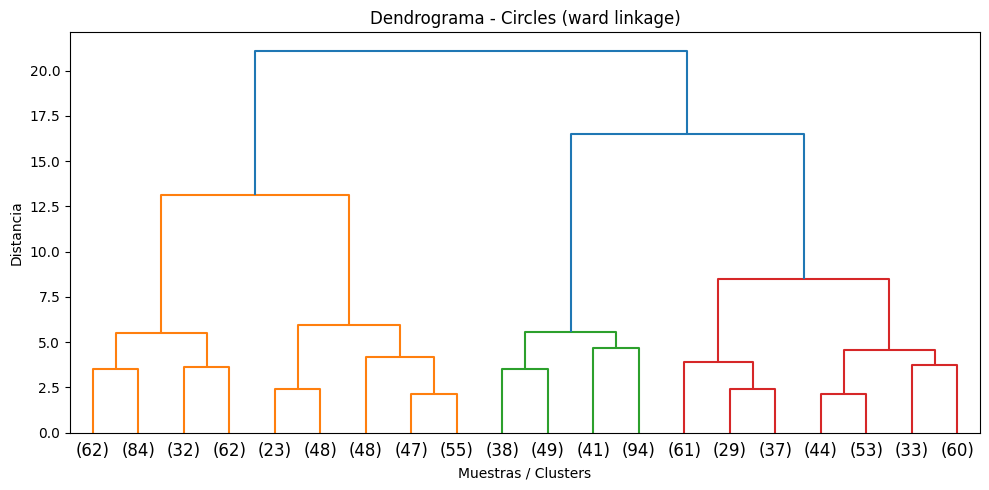

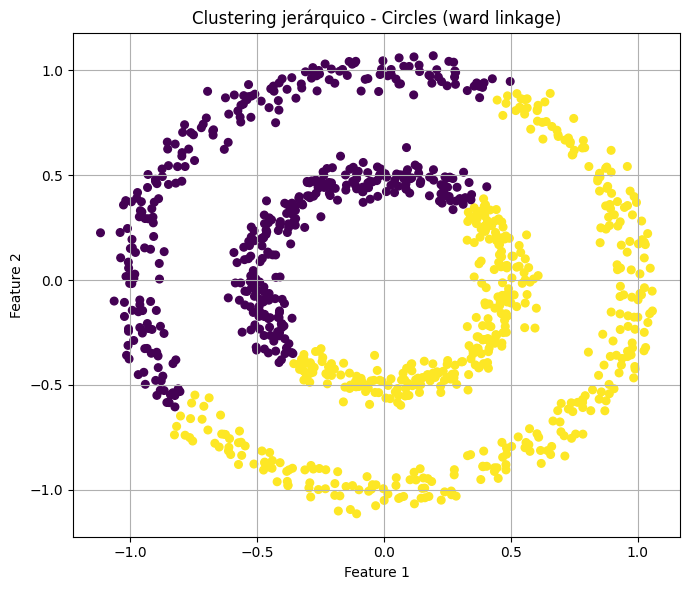

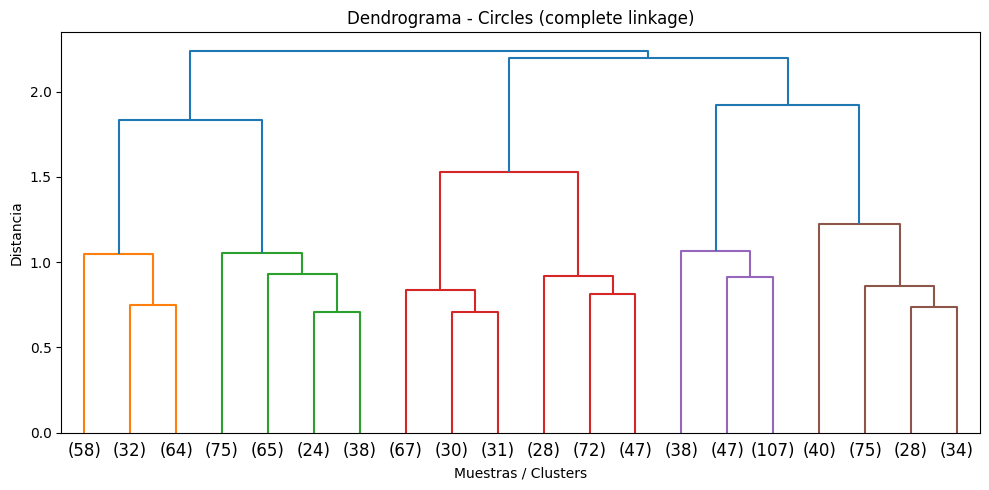

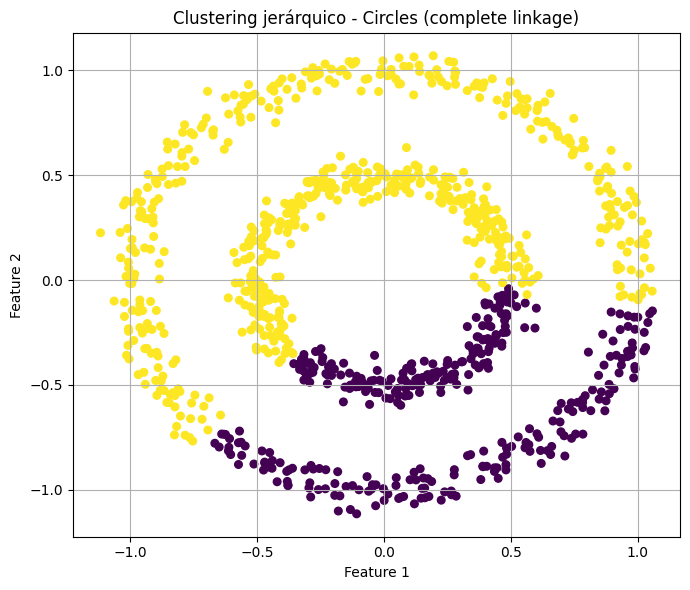

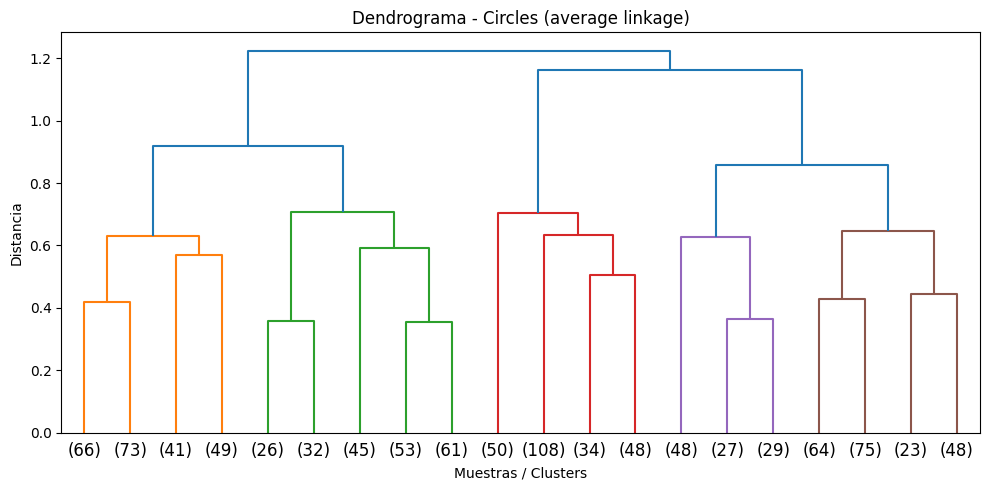

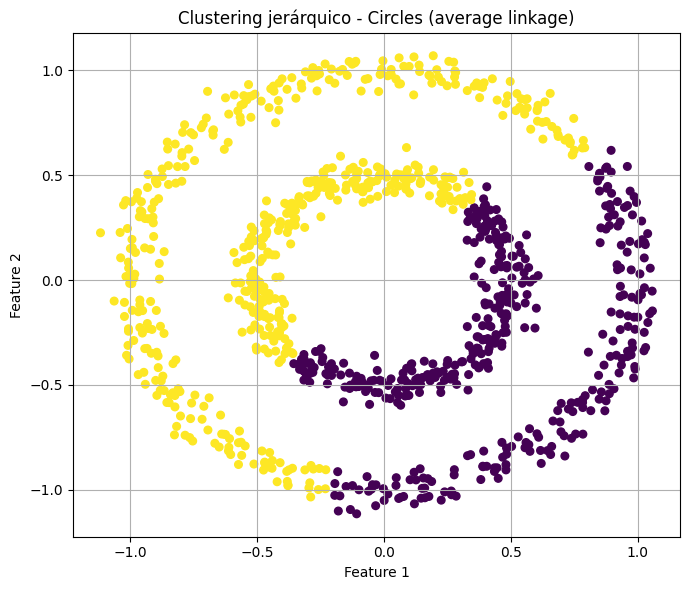

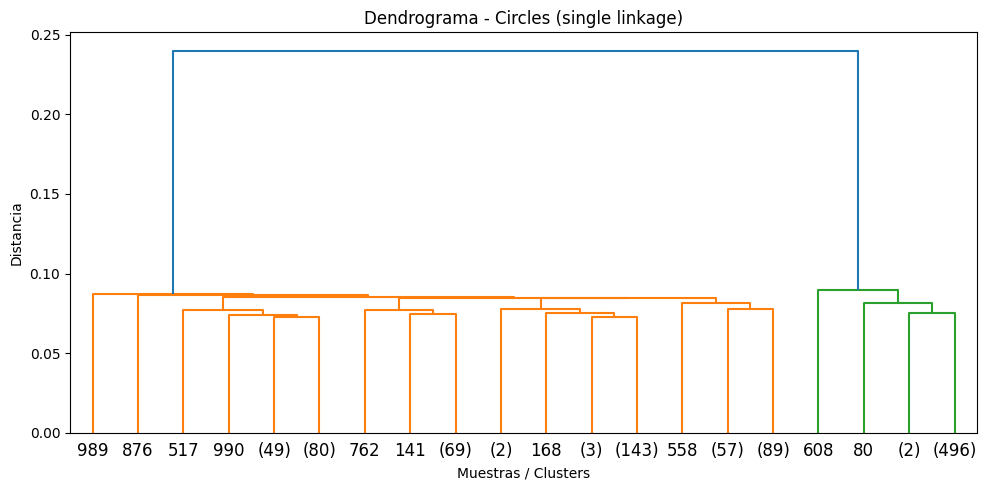

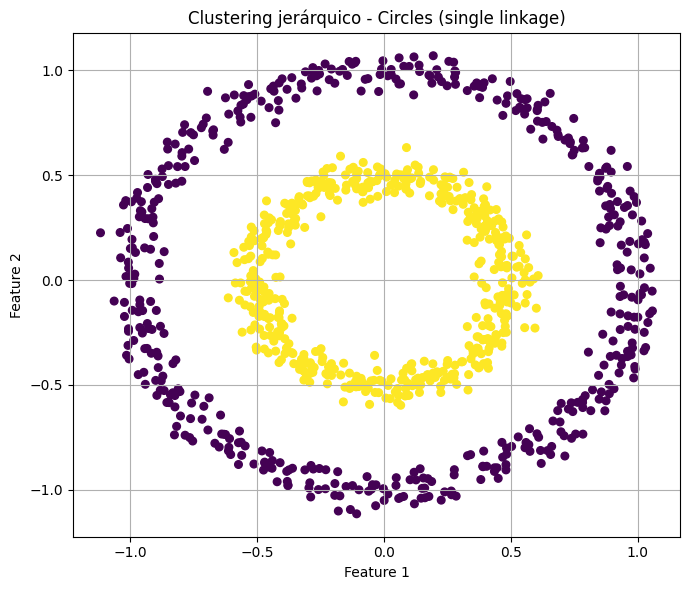

In [26]:
# ==========================================================
# Clustering jerárquico - Dataset Circles
# ==========================================================

linkages = ['ward', 'complete', 'average', 'single']

for method in linkages:
    Z = linkage(X, method=method)

    plt.figure(figsize=(10, 5))
    dendrogram(Z, truncate_mode='lastp', p=20)
    plt.title(f"Dendrograma - Circles ({method} linkage)")
    plt.xlabel("Muestras / Clusters")
    plt.ylabel("Distancia")
    plt.tight_layout()

    ruta_dendo = os.path.join(output_dir, f"dendrograma_circles_{method}.png")
    plt.savefig(ruta_dendo, dpi=300)
    plt.show()

    # Intentamos cortar en 2 clusters (círculo interior/exterior)
    y_pred = fcluster(Z, t=2, criterion='maxclust')

    plt.figure(figsize=(7,6))
    plt.scatter(X[:,0], X[:,1], c=y_pred, cmap='viridis', s=30)
    plt.title(f"Clustering jerárquico - Circles ({method} linkage)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.tight_layout()

    ruta_clusters = os.path.join(output_dir, f"clusters_circles_{method}.png")
    plt.savefig(ruta_clusters, dpi=300)
    plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Interpreta el dendrograma y comenta qué criterio de enlace se ha comportado mejor. ¿Por qué?
</div>

Al aplicar distintos criterios de enlace al dataset *Circles*, los resultados muestran comportamientos muy distintos según la geometría del método y la estructura de los datos.

- **Average Linkage**
  - El dendrograma presenta una estructura compleja y sin saltos claros, pero el clustering con *$k$ = 2* logra separar correctamente el círculo interior y el anillo exterior. Aunque hay algunas asignaciones ambiguas, el método funciona razonablemente bien gracias a que **capta la distancia promedio entre los puntos de cada grupo**, suficiente para distinguir el pequeño hueco que los separa.

- **Complete Linkage**:
  - Produce resultados similares, pero con una separación más limpia y fronteras mejor definidas. Su dendrograma muestra una estructura más equilibrada y un hueco o *gap* moderado entre niveles, lo que refleja que preserva mejor la distancia entre las dos regiones. Al **usar la distancia máxima entre puntos**, evita que se formen “puentes” entre el círculo y el anillo.

- **Single Linkage**:
  - Al contrario, *single linkage* genera un dendrograma muy desbalanceado debido al efecto *chaining*, pero ofrece la mejor clasificación posible, al separar los dos círculos de forma perfecta y sin errores. Aunque el dendrograma parece caótico, **este método detecta conectividad más que compacidad**, lo que encaja perfectamente con la forma circular y continua del dataset. El anillo y el círculo se forman como dos cadenas bien separadas, sin puntos que conecten ambas estructuras.

- **Ward Linkage** 
  - Es el que se comporta peor. Tiende a fusionar grupos prematuramente y produce divisiones incorrectas que cortan el anillo de forma diagonal. Esto ocurre porque ***Ward* minimiza la varianza interna y asume clusters compactos y convexos**, una suposición que el dataset *Circles* no cumple. El anillo, al tener un hueco central, rompe esas condiciones y confunde al algoritmo.

Por lo tanto, el resultado más destacable es que **Single Linkage** se adapta sorprendentemente bien a la geometría circular, mientras que los demás métodos funcionan correctamente pero con limitaciones, y **Ward** falla por completo debido a la forma no convexa de los datos.

## 2. *Clustering* y reducción de dimensionalidad culinaria: (6 puntos)

En este ejercicio exploraremos cómo mediante clustering podemos descubrir patrones ocultos en miles de recetas reales de Food.com. Partiremos de un conjunto de unas 30.000 recetas con su nombre, descripción e ingredientes, y nuestro objetivo será agruparlas por similitud para ver qué tipos de platos emergen sin supervisión: ¿se juntan los postres? ¿los platos con ajo? ¿las recetas mediterráneas?

Probaremos distintas formas de representar las recetas: desde una codificación one-hot basada en los ingredientes, hasta embeddings semánticos generados con modelos de lenguaje (como MiniLM). Con ello veremos cómo cambia la estructura de los datos según el tipo de representación y qué tipo de similitud capturan mejor.

Finalmente aplicaremos técnicas de reducción de dimensionalidad con UMAP y varios métodos de clustering que podrás probar (KMeans, DBSCAN, HDBSCAN, Mean-shift, jerárquico...) para visualizar y analizar los grupos resultantes. Terminaremos interpretando los clusters más grandes a través de sus ingredientes y recetas representativas, comparando qué enfoque refleja mejor la *lógica culinaria* del conjunto.

In [2]:
### FUNCIONES AUXILIARES ###

def describe_df(data):
    """
    Proporciona un resumen del DataFrame, incluyendo forma, tipos de datos, estadísticas básicas,
    conteo de valores nulos, valores únicos, mediana y rango de fechas para columnas tipo datetime.

    :param data: DataFrame de pandas.
    :return: DataFrame con el resumen del DataFrame dado.
    """
    # Crear base del resumen
    total = len(data)
    summary = pd.DataFrame({
        'Column': data.columns,
        'Data Type': data.dtypes.astype(str),
        'Non-null Count': data.count().values,
        '% Null Values': ((data.isnull().sum() / total) * 100).round(2).values,
        'Unique Values': data.nunique().values
    })

    summary['Shape'] = f"{data.shape[0]} rows, {data.shape[1]} columns"

    # Estadísticas para columnas numéricas
    numeric_cols = data.select_dtypes(include=['number']).columns
    if not numeric_cols.empty:
        describe_stats = data[numeric_cols].describe().T
        describe_stats = describe_stats.rename(columns={'50%': 'median'})[
            ['mean', 'median', 'std', 'min', '25%',  '75%', 'max']
        ]
        describe_stats.reset_index(inplace=True)
        describe_stats.rename(columns={'index': 'Column'}, inplace=True)

        summary = pd.merge(summary, describe_stats, on='Column', how='left')

    # Rango de fechas para columnas datetime
    datetime_cols = data.select_dtypes(include=['datetime', 'datetime64[ns]']).columns
    if not datetime_cols.empty:
        date_ranges = pd.DataFrame({
            'Column': datetime_cols,
            'Min Date': data[datetime_cols].min().values,
            'Max Date': data[datetime_cols].max().values
        })
        summary = pd.merge(summary, date_ranges, on='Column', how='left')

    return summary

def detect_duplicates(df):
    """
    Detecta duplicados en un DataFrame y devuelve un nuevo DataFrame con los duplicados.

    :param df: DataFrame de pandas.
    :return: DataFrame con los duplicados detectados.
    """
    try:
        return df[df.duplicated(keep=False)]
    except Exception as e:
        print("Error detectando duplicados:", e)
        return None

def unique_df(df):
    """
    Imprime un resumen de las categorías únicas para las variables categóricas de un DataFrame.

    :param df: DataFrame de pandas.
    """
    categorical_columns = df.select_dtypes(include=['category', 'object']).columns

    if len(categorical_columns) == 0:
        print("No se encontraron columnas categóricas u objeto en el DataFrame.")
        return

    for column in categorical_columns:
        print(f"Resumen para la columna '{column}':\n{df[column].unique()}\n")

In [2]:
# Carga del dataset de recetas
df = pd.read_csv(r'../Data/recipes.csv')

# Visualización de las primeras filas
df.head(3)

,id,name,description,ingredients,ingredients_raw_str,serving_size,servings,steps,tags,search_terms
0,56594,Sun-Dried Tomato Palmiers,"from ""INVITATION TO DINNER"" cookbook","['garlic cloves', 'pesto sauce', 'frozen puff ...","[""2 garlic cloves, peeled and finely min...",1 (675 g),1,"['Preheat the oven to 350 degrees F.', 'Stir t...","['60-minutes-or-less', 'time-to-make', 'course...",{'appetizer'}
1,311362,Char Siu Pork Corn and Bok Choy Stir Fry,Here is another wok recipe I like stir fry's a...,"['peanut oil', 'pork fillets', 'garlic cloves'...","[""2 tablespoons peanut oil"",""600 g p...",1 (364 g),4,['Heat 1 tabelspoon of oil in a wok and cook p...,"['60-minutes-or-less', 'time-to-make', 'course...","{'pork', 'dinner'}"
2,248335,Black Cat Fudge,These adorable fudge peices will be a huge hit...,"['semisweet chocolate', 'butter', 'light corn ...","[""8 ounces semisweet chocolate, coarsely ...",1 (42 g),24,"['Line 11x7 inches pan with foil, extending fo...","['time-to-make', 'course', 'preparation', 'occ...",{'dessert'}


In [29]:
# Resumen del DataFrame
describe_df(df)

,Column,Data Type,Non-null Count,% Null Values,Unique Values,Shape,mean,median,std,min,25%,75%,max
0,id,int64,50000,0.00,50000,"50000 rows, 10 columns",270316.64732,269245.5,154109.531409,41.0,137629.75,403126.5,537804.0
1,name,object,50000,0.00,47154,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,description,object,49053,1.89,48245,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ingredients,object,50000,0.00,49939,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ingredients_raw_str,object,50000,0.00,49984,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,serving_size,object,50000,0.00,2605,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,servings,int64,50000,0.00,89,"50000 rows, 10 columns",6.68870,4.0,8.609285,1.0,4.00,8.0,390.0
7,steps,object,50000,0.00,49967,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,tags,object,50000,0.00,46201,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,search_terms,object,50000,0.00,11451,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# Detección de duplicados
detect_duplicates(df)

,id,name,description,ingredients,ingredients_raw_str,serving_size,servings,steps,tags,search_terms


In [31]:
#  Resumen de las categorías únicas para variables categóricas
unique_df(df)

Resumen para la columna 'name':
['Sun-Dried Tomato Palmiers' 'Char Siu Pork Corn and Bok Choy Stir Fry'
 'Black Cat Fudge' ... 'Mexican Dip' 'Thai Basil Shrimp'
 'Roasted Eggplant and Tomato Pizza']

Resumen para la columna 'description':
['from "INVITATION TO DINNER" cookbook'
 "Here is another wok recipe I like stir fry's as they are quick, easy and reasonably priced to prepare and they are a great way to use up your left over vegetables in a nutritious meal. I served as is but it would go well with steamed rice, as I said yesterday we are watching our carb intake at the moment. This again would serve 3 good portions 4 smaller ones as is, or 4 good portions if served with rice.\r\n\r\nNote: Char Siu Sauce also know as chinese BBQ sauce. It is a paste like ingredient that is dark-red-brown in colour and has a sweet and spicy flavour. Made from fermented soy beans, honey and various spices."
 'These adorable fudge peices will be a huge hit with the kids.' ...
 'This is an original sala

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Crea una nueva columna en el <em>DataFrame</em> que contenga, en una sola cadena de texto,
    <strong>toda la información disponible de cada receta</strong>. Concatena, en ese orden:
  <ul>
    <li>Título (<code>name</code>)</li>
    <li>Descripción (<code>description</code>)</li>
    <li>Lista de ingredientes (<code>ingredients</code>)</li>
    <li>Pasos de preparación (<code>steps</code>)</li>
    <li>Etiquetas (<code>tags</code>) y, si existe, términos de búsqueda (<code>search_terms</code>)</li>
  </ul>
  <p>
    Esta columna representará una descripción textual completa de la receta y se usará en el siguiente paso
    para generar sus <strong>embeddings semánticos</strong>.
  </p>
  <p>
    Ten en cuenta:
  </p>
  <ul>
    <li>Convierte listas o conjuntos a texto legible (por ejemplo, separando por comas).</li>
    <li>Gestiona valores nulos para evitar errores de concatenación.</li>
    <li>Verifica que el texto resultante mantiene la información relevante y es coherente.</li>
  </ul>
</div>

### 2.1. Limpieza y normalizacion

Algunas columnas vienen con listas codificadas como texto (pej.: "['garlic cloves', 'pesto sauce', 'frozen puff pastry', 'fontina', 'parmigiano-reggiano cheese', 'sun-dried tomato', 'fresh ground black pepper']"). Esto significa que la lista está almacenada como texto, no como lista real de Python.

De modo que para evitar errores las convierto a texto legible, creando la funcion safe_to_text(). Posteriormente construyo la nueva columna con las columnas indicadas en el enunciado, completando los valores nulos (si los hubiera) con un espacio vacio.

In [3]:
# =============================================================
# Limpieza y normalizacion
# =============================================================

def safe_to_text(x):
    """
    Convierte listas o conjuntos codificados como texto en una cadena legible.
    Gestiona valores nulos y errores de parseo.
    """
    if pd.isna(x):
        return ""
    if isinstance(x, str):
        try:
            val = ast.literal_eval(x)
            if isinstance(val, (list, set)):
                return ", ".join(map(str, val))
        except (ValueError, SyntaxError):
            pass
    return str(x)

# --- Construcción robusta de la columna unificada ---
sep = " | "  # Separador seguro que no aparece en el texto

df['text_full'] = (
    df['name'].fillna('') + sep +
    df['description'].fillna('') + sep +
    df['ingredients'].apply(safe_to_text) + sep +
    df['steps'].apply(safe_to_text) + sep +
    df['tags'].apply(safe_to_text) + sep +
    df['search_terms'].apply(safe_to_text)
)

# Aseguramos limpieza final (sin separadores repetidos, espacios extra, etc.)
df['text_full'] = (
    df['text_full']
      .str.replace(r'\s+', ' ', regex=True)
      .str.replace(r'(\|\s*){2,}', '| ', regex=True)  # evita duplicados de separador
      .str.strip('| ')
      .str.strip()
)

print(f"Primeros valores de 'text_full':\n{df['text_full'].unique()[:5]}")

Primeros valores de 'text_full':
['Sun-Dried Tomato Palmiers | from "INVITATION TO DINNER" cookbook | garlic cloves, pesto sauce, frozen puff pastry, fontina, parmigiano-reggiano cheese, sun-dried tomato, fresh ground black pepper | Preheat the oven to 350 degrees F., Stir the minced garlic into the prepared pesto., Unfold the pastry sheets and on a lightly floured board roll them slightly with a rolling pin to make a rectangle that measures 11 by 12 inches., Cut each pastry sheet in half lengthwise., Spread 1/4 of the pesto (2 tablespoons) over the entire surface of each pastry sheet., Divide and sprinkle the cheeses and sun-dried tomatoes over the pesto on each pastry sheet and season each with a pinch of pepper., Tightly roll each sheet, starting at a long side, into a 1-inch-wide log., Using a sharp serrated knife, cut each log into about twenty-four 1/2-inch slices and place then on ungreased baking sheets 1 1/2 inches apart., (The palmiers may be baked right away or refrigerated 

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Genera los <strong>embeddings semánticos</strong> de las recetas utilizando el modelo 
    <code>all-MiniLM-L6-v2</code> de la librería <code>sentence-transformers</code>.
    Este modelo es una versión ligera de BERT que transforma frases completas en vectores numéricos
    que capturan su significado.
  <p>
    Usa como entrada la columna con toda la información de la receta (título, descripción, ingredientes, pasos y etiquetas)
    para obtener una representación semántica de cada una.
  </p>
  <p>
    Incrementa el parámetro <code>batch_size</code> en <code>encode()</code> para aprovechar mejor los recursos 
    y activa <code>show_progress_bar=True</code> para visualizar el progreso durante la generación de embeddings.
  </p>
</div>

A continuación genero los [embeddings](https://openwebinars.net/blog/embeddings/) semánticos de las recetas usando el modelo [`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) de `sentence-transformers`, tomando como entrada la columna `text_full` que unifique en la celda anterior para generar:
- `embeddings`: tipo array de numpy de forma (n_recetas, 384)   .
- `df[embeddings]`: Columna con cada vector para futuras búsquedas semánticas.

In [33]:
# =============================================================
# Carga del modelo de embeddings semánticos
# =============================================================

# all-MiniLM-L6-v2 es un modelo ligero y eficiente (384 dimensiones)
model = SentenceTransformer('all-MiniLM-L6-v2')

# --- Generación de embeddings a partir del texto unificado ---
# Uso batch_size alto para eficiencia y barra de progreso para seguimiento
embeddings = model.encode(
    df['text_full'].tolist(),
    batch_size=64,              
    show_progress_bar=True,
    convert_to_numpy=True
)

# --- Almacenamos los embeddings como columna separada o matriz ---
df['embedding'] = list(embeddings)

# Verificamos tamaño y forma
print(f"Embeddings generados: {embeddings.shape}")
print(df[['name', 'embedding']].head(3))

Batches: 100%|██████████| 782/782 [33:26<00:00,  2.57s/it]


Embeddings generados: (50000, 384)
                                       name  \
0                 Sun-Dried Tomato Palmiers   
1  Char Siu Pork Corn and Bok Choy Stir Fry   
2                           Black Cat Fudge   

                                           embedding  
0  [-0.0877346, 0.0032689937, -0.057603378, 0.022...  
1  [-0.113627344, -0.025649745, -0.020737397, 0.0...  
2  [0.024063755, -0.03868188, 0.024933089, 0.0333...  


Con el objeto de poder seguir trabajando con el jupyter notebook si tener que volver a ejecutar todo lo anterior (que en tiempo es sobre unos 25 minutos), guardo el dataframe, junto a la columna de embeddings. De este modo, puedo cargar el dataframes con los embeddings ya generados y seguir desde este punto. 

In [34]:
# Guardamos el DataFrame
with open(r'../Data/df_with_embeddings.pkl', 'wb') as f:
    pickle.dump(df, f)

In [3]:
# Cargar el DataFrame con los embeddings
with open(r'../Data/df_with_embeddings.pkl', 'rb') as f:
    df = pickle.load(f)

print(df.head())
print(df['embedding'].iloc[0].shape)  

embeddings = np.vstack(df['embedding'].values)
print(f"Embeddings reconstruidos con forma: {embeddings.shape}")

       id                                      name  \
0   56594                 Sun-Dried Tomato Palmiers   
1  311362  Char Siu Pork Corn and Bok Choy Stir Fry   
2  248335                           Black Cat Fudge   
3  102357              Hot Pickled Vegetable Medley   
4  195095                             Shopska Salad   

                                         description  \
0               from "INVITATION TO DINNER" cookbook   
1  Here is another wok recipe I like stir fry's a...   
2  These adorable fudge peices will be a huge hit...   
3  This has such a colorful presentation and so g...   
4  The salad is named after the people living in ...   

                                         ingredients  \
0  ['garlic cloves', 'pesto sauce', 'frozen puff ...   
1  ['peanut oil', 'pork fillets', 'garlic cloves'...   
2  ['semisweet chocolate', 'butter', 'light corn ...   
3  ['carrots', 'cauliflower', 'jalapeno peppers',...   
4  ['tomatoes', 'onions', 'cucumber', 'red bell p...

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Reduce los <strong>embeddings</strong> obtenidos a un espacio de <strong>2 dimensiones</strong> utilizando 
    <code>UMAP</code> (<em>Uniform Manifold Approximation and Projection</em>), una técnica de reducción de dimensionalidad
    que conserva la estructura local de los datos en espacios de alta dimensión.
  <p>
    UMAP busca representar los datos en un espacio más pequeño manteniendo la relación entre puntos similares,
    lo que lo hace ideal para visualizar embeddings en 2D y detectar grupos o patrones de manera intuitiva.
    En comparación con <em>t-SNE</em>, UMAP es más rápido, escalable, permite la proyección de nuevos puntos y preserva mejor la estructura global de los datos.
    Puedes consultar una comparación visual detallada en 
    <a href="https://pair-code.github.io/understanding-umap/" target="_blank">esta página</a>.
  </p>
  <p>
    Aplica UMAP sobre la matriz de embeddings y guarda el resultado en una nueva variable que contenga las coordenadas 2D
    de cada receta para su posterior visualización o análisis.
  </p>
</div>

Una vez obtenidos los embeddings semánticos, se reducen a 2 las dimensiones utilizando [`UMAP`](https://pair-code.github.io/understanding-umap/) (*Uniform Manifold Approximation and Projection*) para poder visualizarlos y/o detectar patrones de similitud entre recetas. Consiguiendo un dataframe con 2 coordenadas 2D (`df['umap_x]` y `df['umap]`), listo para graficar.

In [36]:
# =============================================================
# Configuración y aplicación de UMAP
# =============================================================

# n_neighbors controla la preservación de la estructura local
# min_dist regula la compactación del mapa (valores bajos agrupan más los puntos)
# random_state fija la semilla para reproducibilidad
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine', # Siguiendo documentacion de all-MiniLM-L6-v2
    random_state=42
)

# --- Reducción de dimensionalidad ---
embeddings_2d = reducer.fit_transform(embeddings)

# --- Almaceno las coordenadas 2D en el DataFrame ---
df['umap_x'] = embeddings_2d[:, 0] # type: ignore
df['umap_y'] = embeddings_2d[:, 1] # type: ignore

# --- Verificación del resultado ---
print("Reducción UMAP completada.")
print(f"Shape del embedding reducido: {embeddings_2d.shape}") # type: ignore
print(df[['name', 'umap_x', 'umap_y']].head(3))

Reducción UMAP completada.
Shape del embedding reducido: (50000, 2)
                                       name    umap_x     umap_y
0                 Sun-Dried Tomato Palmiers -2.645844   1.872724
1  Char Siu Pork Corn and Bok Choy Stir Fry  3.132428  -1.176890
2                           Black Cat Fudge -0.514086  11.974957


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Visualiza el resultado de la reducción a 2D con <code>UMAP</code> mediante un <strong>scatter plot</strong>.
    Representa cada receta como un punto en el plano y observa si se forman grupos o regiones con mayor densidad.
  <p>
    Para mejorar la legibilidad del gráfico:
  </p>
  <ul>
    <li>
      Ajusta el parámetro <code>alpha</code> para controlar la <strong>transparencia</strong> de los puntos:
      valores más bajos (por ejemplo, 0.3) permiten visualizar mejor las zonas donde los puntos se solapan,
      haciendo más visibles las regiones densas.
    </li>
    <li>
      Reduce el parámetro <code>s</code> (tamaño de los puntos) para evitar que se superpongan en exceso
      y poder distinguir mejor la estructura general del conjunto.
    </li>
  </ul>
</div>

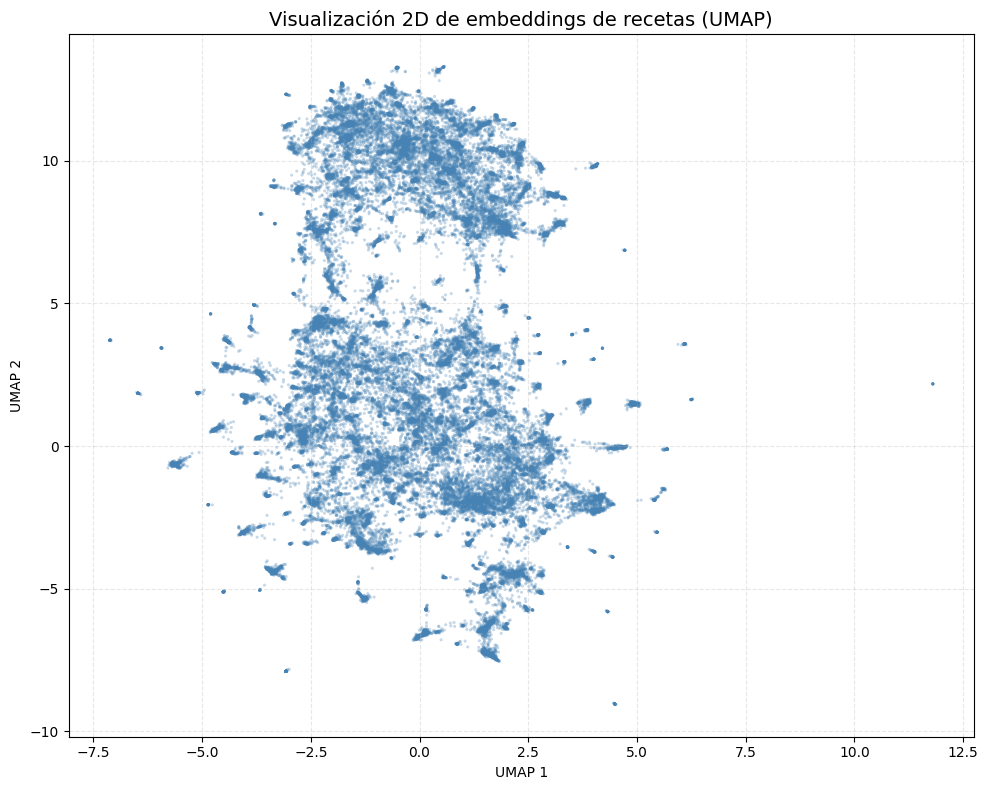

In [37]:
# =============================================================
# Visualización de los embeddings reducidos con UMAP
# =============================================================

# Ajusto el tamaño de los puntos (más pequeño = menos solapamiento)
# Transparencia (menor = más fácil ver densidad)
plt.figure(figsize=(10, 8))
plt.scatter(
    df['umap_x'],
    df['umap_y'],
    s=5,         
    alpha=0.3,    
    c='steelblue',
    edgecolors='none'
)

plt.title("Visualización 2D de embeddings de recetas (UMAP)", fontsize=14)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/embeddings_reducidos_con_UMAP.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> <strong>sobre qué datos realizar el clustering</strong>: 
    ¿sobre los datos reducidos en 2D o sobre los embeddings originales en alta dimensionalidad?
  <p>
    Justifica tu elección explicando las posibles consecuencias de aplicar el algoritmo 
    de clustering sobre una representación reducida en comparación con la original.
  </p>
</div>

La **elección correcta para el clustering** es hacerlo sobre los **embeddings originales** de alta dimensionalidad, no sobre la versión reducida en 2D. Esta decisión es clave para obtener un agrupamiento que sea verdaderamente representativo del significado de los textos.

La razón principal radica en la **preservación de la información semántica** y el propósito fundamental de cada técnica:

* **Embeddings Originales (384D):** Contienen la **estructura semántica completa** que el modelo ha aprendido. Al hacer el *clustering* sobre estas 384 dimensiones, el algoritmo (como `K-Means` o `HDBSCAN`) está agrupando los textos basándose en su **significado real** y sus relaciones de similitud precisas. Esto resulta en una **alta precisión** del *clustering*.
* **Embeddings Reducidos por UMAP (2D):** UMAP es una técnica de reducción de dimensionalidad **no lineal** cuyo propósito principal es la **visualización y exploración de patrones**. Aunque es excelente para dibujar los datos, en el proceso **pierde parte de la información global y distorsiona algunas distancias**. Por lo tanto, si se agrupase sobre la versión 2D, el algoritmo estará trabajando con una **proyección aproximada**, lo que puede llevar a límites de clusters distorsionados o incorrectos.

En resumen, para un análisis riguroso y una visualización clara, el flujo de trabajo recomendado es:

1.  **Fase de Clustering:** Utiliza los **embeddings originales (384D)** como entrada para tu algoritmo de clustering.
2.  **Fase de Visualización:** Una vez se tienen las etiquetas del cluster, se proyectan sobre el plano **UMAP 2D** para poder **interpretar y visualizar** los clusters y sus centroides en un gráfico fácil de entender. 

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Visualiza las recetas en su <strong>espacio original de alta dimensionalidad</strong> utilizando 
    un <strong>dendrograma</strong>. 
    Esto te permitirá analizar la estructura de los datos y comparar si las agrupaciones observadas 
    coinciden con las que aparecían en la proyección 2D de <code>UMAP</code>.
  <p>
    Comenta qué puedes inferir al observar el dendrograma:
    si existen grupos bien definidos o si las fusiones son graduales,
    y cómo se relaciona esa estructura jerárquica con las regiones que aparecían en la visualización reducida.
  </p>
</div>

El objetivo es observar cómo se agrupan las recetas en su espacio original de 384 dimensiones, sin reducir la dimensionalidad. Para ello se ha aplicado un clustering jerárquico aglomerativo, que va uniendo las recetas más parecidas de forma recursiva y genera un árbol jerárquico de fusiones que se puede visualizar mediante un dendrograma.

Recomiendo reducir los datos mediante un muestreo aleatorio de los datos a 25.000 recetas, ya que el análisis con 50.000 puntos ha sido MUY costoso computacionalmente (52 min para el siguiente grafico 'Dendrograma jerárquico de recetas (embeddings originales)' y unos 80 min para el gráfico 'Clusters de recetas con HDBSCAN y visualización UMAP'). Esto se debe a que el algoritmo de clustering jerárquico (función *linkage*) tiene una complejidad cuadrática respecto al número de muestras (O(n^2)). Tambien, el dendrograma sin el muestreo aleatorio se vuelve ininterpretable visualmente (se solaparían todas las ramas). Con la reduccion a 25.000 tarda menos de 20 min para completar las ejecuciones de las celdas.

In [ ]:
# --- Muestra una selección aleatoria (por eficiencia) ---
# (El dendrograma completo con 50.000 puntos sería ininterpretable)
n_samples = 25000  
sample_idx = np.random.choice(len(embeddings), n_samples, replace=False)
embeddings_sample = embeddings[sample_idx]

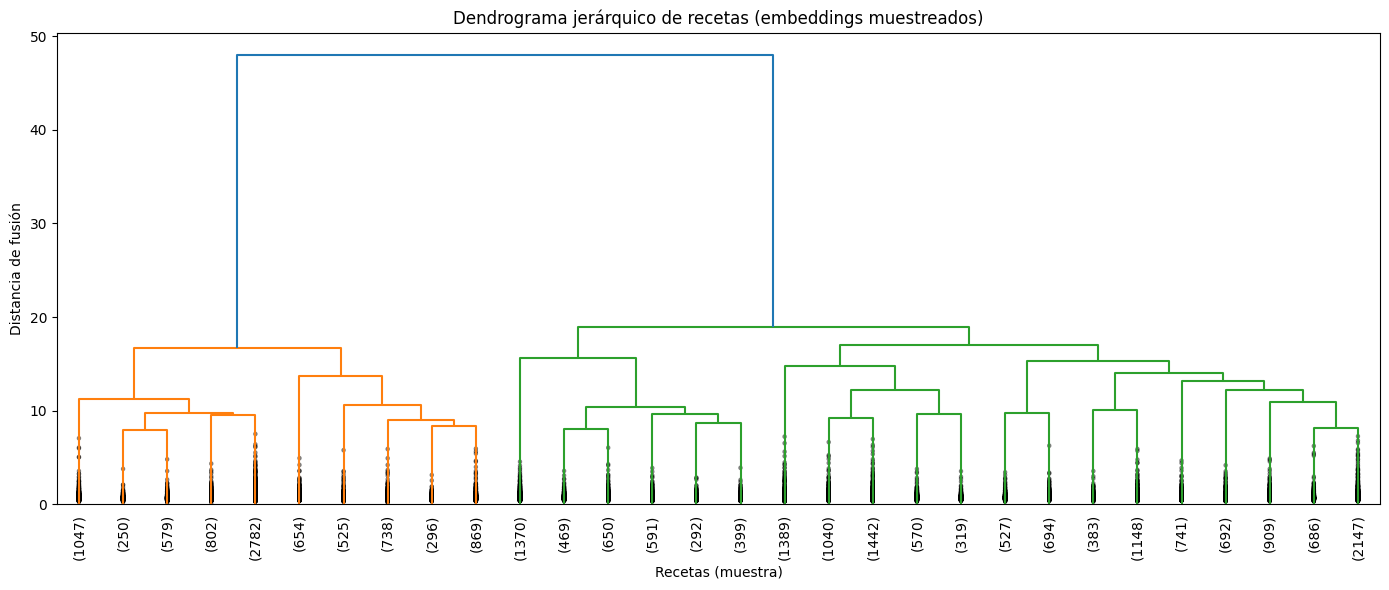

In [ ]:
# =============================================================
# Visualización de la estructura jerárquica
# =============================================================

# --- Cálculo de la matriz de enlace (linkage matrix) ---
# 'ward' minimiza la varianza dentro de cada grupo
linkage_matrix = linkage(embeddings_sample, method='ward')

# --- Visualización del dendrograma ---
plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',     # muestra solo las fusiones más altas
    p=30,                      # número de grupos visibles
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

plt.title("Dendrograma jerárquico de recetas (embeddings muestreados)")
plt.xlabel("Recetas (muestra)")
plt.ylabel("Distancia de fusión")
plt.tight_layout()
plt.savefig(r'../Visualizaciones/dendrograma_recetas.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Dado lo observado en la reducción de dimensionalidad con <code>UMAP</code> y en el dendrograma obtenido,
    decide <strong>qué algoritmo de clustering</strong> utilizarías para identificar los grupos de recetas.
    Explica con qué argumentos lo elegirías y justifica tu respuesta en función de la estructura observada 
    en los datos (densidad, tamaño y forma de los grupos).
</div>

A partir de la observación conjunta del **dendrograma jerárquico** y la **proyección bidimensional obtenida mediante UMAP**, se evidencia que el espacio semántico de las recetas presenta una estructura continua, sin divisiones abruptas ni fronteras claramente definidas entre grupos. El dendrograma muestra fusiones progresivas y homogéneas, sin saltos marcados que indiquen la existencia de jerarquías bien delimitadas; esto sugiere que las similitudes entre recetas varían de manera gradual y que los posibles grupos no están separados por grandes distancias semánticas. Por su parte, el UMAP revela una nube densa y extensa, con áreas localmente más concentradas, pero sin núcleos aislados o regiones vacías entre ellos.

En este contexto, la distribución observada apunta a una organización más cercana a un continuo de recetas que a una segmentación en grupos cerrados. No se aprecia una estructura que responda bien a modelos de densidad irregular o con fronteras difusas, lo que limita la eficacia de algoritmos como `DBSCAN` o `HDBSCAN`, que dependen de contrastes claros entre regiones densas y dispersas. Además, la alta dimensionalidad y el volumen de datos hacen que los métodos basados en densidad resulten computacionalmente costosos, como se ha comprobado con `HDBSCAN` (intenté usarlo y ni reduciendo el numero de muestras completaba la ejecución).

`K-Means`, pese a su simplicidad, se adapta mejor a este tipo de estructura. Al imponer una partición global del espacio y asumir clusters de forma aproximadamente convexa, permite capturar de manera eficiente las grandes tendencias semánticas sin requerir un ajuste fino de parámetros ni un cálculo intensivo de distancias. La elección de un número moderado de clusters ofrece una segmentación estable, equilibrada y fácilmente interpretable, donde cada grupo representa un conjunto de recetas con coherencia temática y proximidad semántica.

Por tanto, considerando la densidad uniforme, la ausencia de fronteras naturales y la necesidad de un método computacionalmente manejable, `K-Means` constituye la opción más adecuada para identificar y analizar los grupos de recetas en este conjunto de datos.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Implementa el algoritmo elegido y analiza sus posibles parámetros para obtener el resultado deseado.
</div>

Comienzo aplicando **el método del codo** sobre un rango de valores posibles para $k$, calculando la suma de los errores cuadráticos dentro de los clusters (*inertia*) para cada valor. Al observar el gráfico, se aprecia que la reducción de la inercia empieza a ser marginal a partir de **$k = 26$**, lo que indica que añadir más clusters no aporta una mejora sustancial en la compactación de los grupos. Por tanto, se selecciona este valor como punto de equilibrio y se implementa el algoritmo **K-Means con $k = 26$**.

De forma complementaria, se evalúa el **coeficiente de Silhouette**, que mide simultáneamente la cohesión interna de los clusters y su separación respecto a los demás. Los resultados muestran que la puntuación de Silhouette se mantiene relativamente estable (en torno a 0.04) desde $k = 9$ hasta $k = 30$, lo que refuerza la elección de $k = 26$ como una solución adecuada. Este valor permite capturar un nivel de detalle suficiente para distinguir categorías culinarias específicas sin fragmentar en exceso la estructura global del conjunto de recetas.

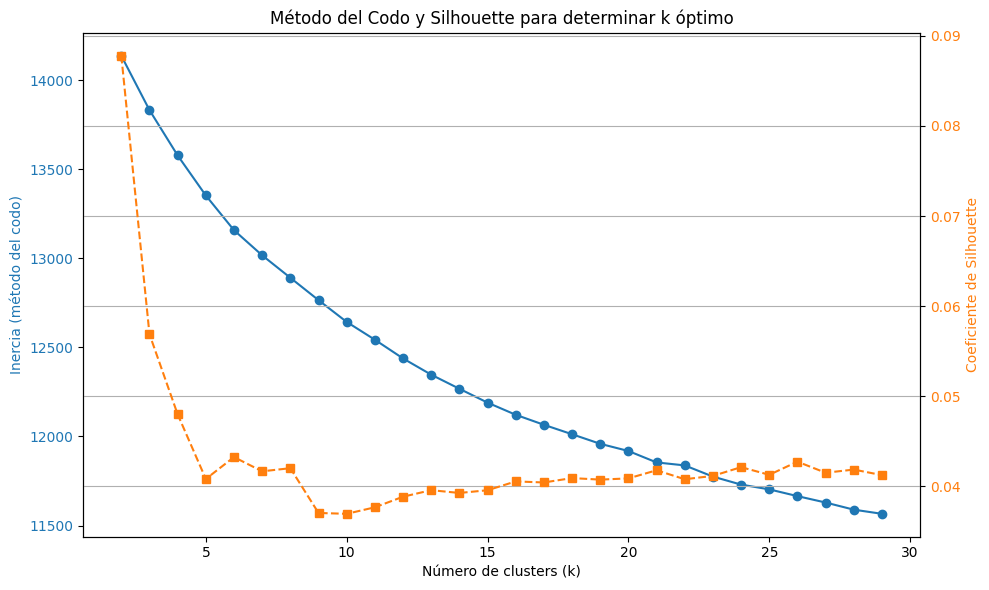

In [ ]:
# ===========================================================================
# Determinación del número óptimo de clusters (K-Means) - MÉTRICA EUCLIDEA
# ===========================================================================

# --- Datos de entrada ---
X = embeddings_sample  

# --- Rango de k a evaluar ---
n_clusters = range(2, 30)  
inertias = []
silhouette_scores = []

# --- Evaluación de KMeans para cada k ---
for k in n_clusters:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,       # nº de inicializaciones diferentes
        max_iter=300,    # nº máximo de iteraciones por ejecución
        init='k-means++' # inicialización inteligente de centroides
    )
    
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)
    
    # Calcular silhouette sólo si hay más de 1 cluster
    silhouette_scores.append(silhouette_score(X, labels))

# =============================================================
# Visualización conjunta
# =============================================================
fig, ax1 = plt.subplots(figsize=(10,6))

color_elbow = 'tab:blue'
color_silhouette = 'tab:orange'

# --- Curva del método del codo (inercia) ---
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia (método del codo)', color=color_elbow)
ax1.plot(n_clusters, inertias, 'o-', color=color_elbow, label='Inercia')
ax1.tick_params(axis='y', labelcolor=color_elbow)

# --- Segundo eje para Silhouette ---
ax2 = ax1.twinx()
ax2.set_ylabel('Coeficiente de Silhouette', color=color_silhouette)
ax2.plot(n_clusters, silhouette_scores, 's--', color=color_silhouette, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color_silhouette)

# --- Título y estética ---
plt.title('Método del Codo y Silhouette (Distancia euclidea)')
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.savefig(r'../Visualizaciones/regla_del_codo_y_silhouette_embeddings_sample_euclidea.png', dpi=300)
plt.show()

En este análisis se ha aplicado el algoritmo **K-Means** para agrupar las recetas en función de sus embeddings semánticos, obtenidos con el modelo *all-MiniLM-L6-v2*.
Tras determinar el número óptimo de grupos mediante los métodos del **codo** y **Silhouette**, se seleccionó un valor de **k = 26**, que representa un punto de equilibrio entre la compacidad de los clusters y la interpretabilidad de los resultados.

El modelo de K-Means se configuró con varios parámetros clave que influyen directamente en la calidad y estabilidad del agrupamiento. En primer lugar, el parámetro **`n_clusters=26`** define el número de grupos que el algoritmo debe encontrar. Este valor no se elige arbitrariamente, sino que se fundamenta en el análisis previo de la evolución de la inercia (suma de distancias internas) y del coeficiente de Silhouette. En este caso, se observó que a partir de 26 clusters la mejora en la inercia era marginal, lo que indicaba que seguir aumentando el número de grupos no aportaba un beneficio real en la separación de las recetas.

El parámetro **`init='k-means++'`** se emplea para mejorar la inicialización de los centroides. En lugar de asignar posiciones completamente aleatorias, este método selecciona puntos iniciales de forma más informada, distribuyéndolos en regiones representativas del espacio de datos. Esto acelera la convergencia y reduce la posibilidad de que el algoritmo quede atrapado en mínimos locales poco representativos, algo especialmente importante cuando se trabaja con embeddings densos y de alta dimensionalidad.

Por su parte, **`n_init=10`** indica que el algoritmo se ejecutará varias veces con diferentes inicializaciones, conservando el resultado que produzca la menor inercia. Este valor garantiza estabilidad en la solución final, evitando que pequeñas variaciones en los centroides iniciales generen resultados inconsistentes. En versiones más recientes de *scikit-learn*, el valor por defecto `'auto'` ajusta automáticamente este parámetro en función del tamaño del conjunto de datos, pero mantenerlo explícitamente en 10 sigue siendo una práctica segura.

El parámetro **`max_iter=300`** establece el número máximo de iteraciones que puede realizar el algoritmo en cada ejecución. Generalmente, el proceso converge antes de alcanzar este límite, pero mantenerlo en 300 asegura que el modelo disponga del tiempo suficiente para estabilizar los centroides. Si no se lograra la convergencia, podría incrementarse este valor, aunque a costa de un mayor tiempo de cómputo.

La opción **`random_state=42`** fija la semilla aleatoria, permitiendo reproducir exactamente los resultados en distintas ejecuciones, algo esencial en entornos de investigación o informes técnicos.

Finalmente, `K-Means` utiliza por defecto una tolerancia (**`tol=1e-4`**) como criterio de parada, que controla cuándo se considera que la variación entre iteraciones sucesivas es lo bastante pequeña para detener el proceso. Este valor suele ser adecuado en la mayoría de los casos y no requiere ajuste salvo que se busque una precisión extrema.

In [ ]:
# =============================================================
# Clustering con K-Means sobre la muestra
# =============================================================

# --- Selección del número de clusters ---
# Determinado con el método del codo o silhouette.
n_clusters = 26   

# --- Inicialización y entrenamiento ---
kmeans = KMeans(
        n_clusters=n_clusters,    # número de clusters elegido
        random_state=42,          # semilla para reproducibilidad
        n_init=10,                # nº de inicializaciones diferentes
        max_iter=300,             # nº máximo de iteraciones por ejecución
        init='k-means++',         # inicialización inteligente de centroides
        tol=1e-4                  # tolerancia para convergencia
)

labels_sample = kmeans.fit_predict(embeddings_sample)

print(f"Clusters encontrados: {n_clusters}")
print(f"Sin ruido explícito (KMeans asigna todos los puntos a algún cluster).")

Clusters encontrados: 26
Sin ruido explícito (KMeans asigna todos los puntos a algún cluster).


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Representa en un <strong>scatter plot</strong> la proyección 2D (UMAP) coloreando cada punto según su
    <code>cluster</code>. Usa una paleta cualitativa rica en colores (como <code>tab20</code>). Si hay más clusters que colores disponibles, reutiliza colores
    aplicando el índice del cluster <em>módulo</em> el número de colores de la paleta.
</div>

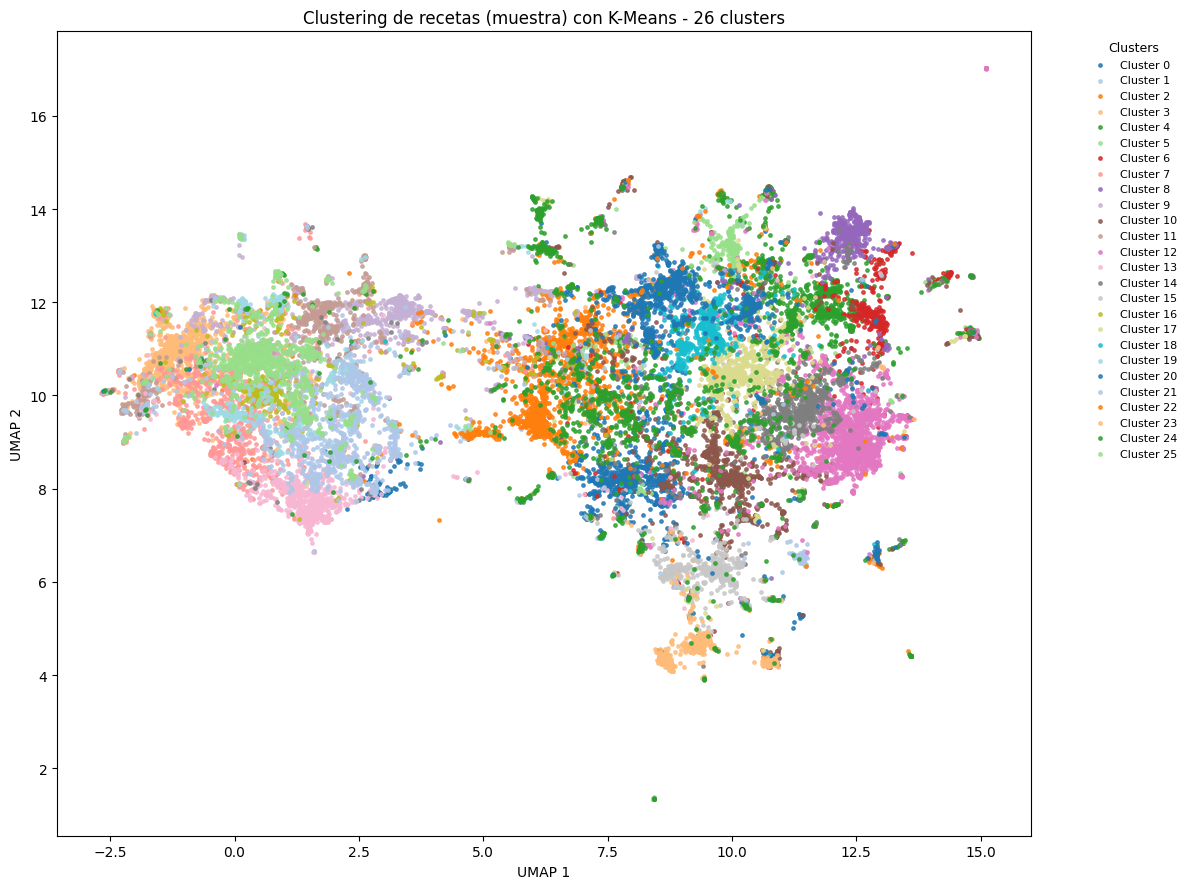

In [58]:
# =============================================================
# Visualización de los clusters (UMAP de la muestra) con leyenda
# =============================================================
reducer_sample = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

embeddings_2d_sample = reducer_sample.fit_transform(embeddings_sample)

# --- Colores de clusters ---
palette = sns.color_palette('tab20', n_colors=n_clusters)
colors = [palette[int(label % len(palette))] for label in labels_sample]

plt.figure(figsize=(12, 9))

# --- Dibujar cada cluster por separado para poder etiquetar ---
for cluster_id in range(n_clusters):
    mask = labels_sample == cluster_id
    plt.scatter(
        embeddings_2d_sample[mask, 0],
        embeddings_2d_sample[mask, 1],
        s=6,
        color=palette[cluster_id % len(palette)],
        alpha=0.8,
        label=f'Cluster {cluster_id}'
    )

# --- Títulos y etiquetas ---
plt.title(f"Clustering de recetas (muestra) con K-Means - {n_clusters} clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# --- Leyenda fuera del área del gráfico ---
plt.legend(
    title="Clusters",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=8,
    title_fontsize=9,
    frameon=False
)

plt.tight_layout()
plt.savefig(r'../Visualizaciones/kmeans_clusters_umap_embeddings_sample.png', dpi=300, bbox_inches='tight')
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Para interpretar el clustering y validar su coherencia, selecciona los <strong>10 grupos</strong> con mayor tamaño y muestra,
    para cada uno, las <strong>5 recetas más cercanas al centroide</strong> (si el método lo define).
</div>

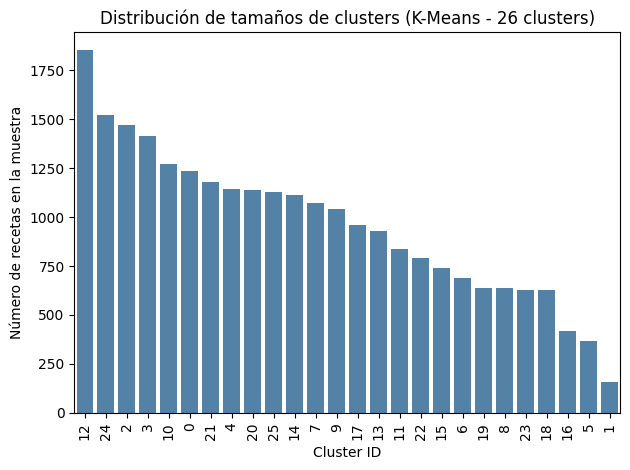


=== Recetas más representativas por cluster (K-Means - muestra) ===

Cluster 0 (1236 recetas en la muestra):
  - Garden Salad
  - Leaf Salad
  - Healthier 7 Layer Salad
  - Mixed Greens with Honey-Lime Dressing
  - Salad

Cluster 1 (160 recetas en la muestra):
  - Roasted Asparagus
  - Grilled Asparagus Medley
  - Mixed Asparagus/Peppers Saute
  - Asparagus
  - Asparagus Parmesan Garlic Spears

Cluster 2 (1470 recetas en la muestra):
  - Party Snack
  - Three Corn and Cheddar Spoon Bread
  - Chili Cheese Cubes
  - Simple Savory Breakfast Casserole
  - Hearty Breakfast Casserole

Cluster 3 (1413 recetas en la muestra):
  - Doubly Chocolate Cookies
  - Healthier Chocolate Chip Cookies
  - Peanut Butter Chocolate Chip Breakfast Cookies
  - Big Chocolate Chip Cookies
  - Easy Chocolate Chip Cookies

Cluster 4 (1145 recetas en la muestra):
  - Hamburger &quot; Steaks&quot; With Onion Gravy
  - Ranch Beef Stew
  - Creamy Beef and Onions
  - Beefy Vegetable Bake
  - Beef Stew

Cluster 5 (365

In [57]:
# =============================================================
# Análisis de los clusters obtenidos (muestra)
# =============================================================
sns.countplot(
    x=labels_sample,
    order=pd.Series(labels_sample).value_counts().index,
    color='steelblue'
)
plt.title(f"Distribución de tamaños de clusters (K-Means - {n_clusters} clusters)")
plt.xlabel("Cluster ID")
plt.ylabel("Número de recetas en la muestra")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/kmeans_tamano_clusters_embeddings_sample.png', dpi=300)
plt.show()

# =============================================================
# Recetas representativas por cluster (en la muestra)
# =============================================================

# --- Extrae nombres de la muestra ---
names_sample = df.iloc[sample_idx]['name'].reset_index(drop=True)

def cluster_representatives_sample(names, embeddings, labels, top_k=5):
    reps = {}
    for c in sorted(set(labels)):
        idx = np.where(labels == c)[0]
        cluster_emb = embeddings[idx]
        centroid = cluster_emb.mean(axis=0, keepdims=True)
        dists = cosine_distances(cluster_emb, centroid).ravel()
        nearest = np.argsort(dists)[:top_k]
        reps[c] = names.iloc[idx[nearest]].tolist()
    return reps

reps_sample = cluster_representatives_sample(names_sample, embeddings_sample, labels_sample)

print("\n=== Recetas más representativas por cluster (K-Means - muestra) ===")
for c, names in reps_sample.items():
    print(f"\nCluster {c} ({np.sum(labels_sample==c)} recetas en la muestra):")
    for name in names:
        print(f"  - {name}")

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Observa los resultados del clustering e interpreta si los grupos obtenidos <strong>tienen sentido</strong> desde un punto de vista culinario. 
    Observa si las recetas dentro de un mismo cluster comparten ingredientes, estilo de preparación o tipo de plato 
    (por ejemplo, salsas, postres, carnes, ensaladas...). 
    Explica brevemente por qué crees que los clusters son o no coherentes.
</div>

Después de analizar las recetas representativas de cada cluster, puedo afirmar que **los clusters tienen una coherencia culinaria muy alta y realmente tienen sentido desde el punto de vista gastronómico**.

En primer lugar, diria que varios clusters demuestran una coherencia perfecta. Por ejemplo, el cluster 0 agrupa exclusivamente ensaladas verdes frescas, con recetas como "*Garden Salad*", "*Leaf Salad*" y "*Mixed Greens with Honey-Lime Dressing*". De manera similar, el cluster 1 es increíblemente específico, enfocándose únicamente en preparaciones de espárragos, ya sean asados, a la parrilla o salteados. Siguiendo con en el mundo de la repostería, encontramos clusters particularmente bien definidos. El cluster 3 reúne exclusivamente galletas de chocolate chip en sus diferentes variaciones, mientras que el cluster 7 agrupa postres cremosos de chocolate como puddings, fudge y caramelos. El cluster 16 es aún más específico, conteniendo únicamente *cheesecakes* en sus distintas presentaciones (clásico, chocolate blanco, vainilla). Por su parte, el cluster 19 agrupa tartas y pies, principalmente de manzana y calabaza. Por otro lado, el cluster 9 captura perfectamente la categoría de panadería con levadura, incluyendo panes caseros y panecillos dulces. El cluster 13 agrupa coherentemente bebidas frías y batidos de frutas, perfectos para el verano.

En segundo lugar, es de resaltar que uno de los patrones más interesantes es cómo el algoritmo ha logrado separar las recetas según la proteína principal. El cluster 4 agrupa preparaciones de carne de res guisada como estofados y hamburguesas con salsa. El cluster 5 se centra específicamente en pavo, con recetas como "*Turkey Chili*" y "*Herb-Crusted Turkey*". El cluster 6 captura bistecs a la parrilla con diferentes marinadas y salsas. El cluster 8 está dedicado a chuletas de cerdo y pulled pork, mientras que el cluster 12, siendo uno de los más grandes, agrupa diversas preparaciones de pollo. El cluster 15 es particularmente interesante porque captura la cocina criolla del sur con camarones, incluyendo "*Shrimp Creole*" y "*BBQ Shrimp*". Finalmente,  el cluster 23 agrupa pescados preparados de diversas formas.

En tercer lugar, es impresionante como el algoritmo también ha logrado identificar estilos culinarios específicos. El cluster 14 captura perfectamente la cocina asiática, con recetas tailandesas, arroz frito y noodles picantes. El cluster 20 agrupa preparaciones tex-mex como tacos, chili y casseroles mexicanas, aunque este cluster muestra algo más de heterogeneidad. Sin embargo, algunos clusters se definen más por la técnica de preparación o el tipo de plato. El cluster 2 agrupa casseroles y preparaciones horneadas saladas. El cluster 10 reúne pasta con salsa de tomate, desde espagueti hasta lasaña. El cluster 11 se especializa en *muffins*, particularmente de banana y nueces. El cluster 17 captura sopas cremosas y caldos vegetales. El cluster 18 agrupa preparaciones de frijoles y legumbres al estilo sureño. El cluster 21 reúne postres de frutas horneadas como crumbles y crisps. El cluster 22 se centra en preparaciones de papa, desde puré hasta gratinados. El cluster 24 agrupa vegetales horneados en gratinados y casseroles. Finalmente, el cluster 25 captura pasteles de chocolate en sus diferentes versiones.

En resumen, el clustering demuestra una **coherencia culinaria excepcional**. El algoritmo ha logrado identificar patrones naturales en las recetas basándose en tres criterios principales: el ingrediente dominante (espárragos, papa, pollo), el tipo de plato o categoría culinaria (ensaladas, sopas, postres), y la técnica de preparación (horneado, guisado, a la parrilla). Lo más impresionante es cómo ha logrado separar finamente diferentes categorías de postres (galletas vs. *puddings* vs. *cheesecakes* vs. *pies* vs. pasteles) y distinguir entre diferentes proteínas animales, asignando clusters específicos a res, cerdo, pollo, pavo, pescado y camarones. Incluso ha capturado estilos culinarios regionales como la cocina asiática y la criolla sureña. Estos resultados sugieren que el clustering basado en ingredientes es altamente efectivo para organizar recetas de manera que tenga sentido desde el punto de vista culinario. Este sistema sería ideal para implementar en un sistema de recomendación de recetas, donde los usuarios podrían descubrir fácilmente variaciones de sus platos favoritos o explorar categorías específicas de cocina que les interesen.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Vamos a crear una nueva representación de las recetas utilizando únicamente sus <strong>ingredientes</strong>. 
    Para ello, genera una matriz <em>one-hot</em> donde cada fila representa una receta y cada columna un ingrediente distinto.
    En esta matriz, el valor será <code>1</code> si la receta contiene ese ingrediente y <code>0</code> en caso contrario.
  <p>
    Puedes utilizar la clase <code>MultiLabelBinarizer</code> de <code>sklearn.preprocessing</code> 
    para transformar automáticamente las listas de ingredientes en vectores binarios.
  </p>
  <ul>
    <li>Usa la columna de ingredientes ya procesada (listas limpias y sin valores nulos).</li>
    <li>Guarda el resultado en una nueva variable o DataFrame y asegúrate de que el número de columnas coincide con el número total de ingredientes únicos.</li>
    <li>Esta representación servirá como nueva base para aplicar técnicas de reducción de dimensionalidad y clustering.</li>
  </ul>
</div>

En este caso, la columna `ingredients` contiene listas almacenadas como texto y con caracteres especiales codificados. Para convertirlas en listas reales y legibles, se define la función `parse_ingredient_list()`, que decodifica, limpia y estandariza los ingredientes, generando la nueva columna `ingredientes_limpios` lista para su análisis.

In [4]:
# --- Aseguramos que los ingredientes sean listas limpias ---
def parse_ingredient_list(x):
    """Convierte una cadena tipo lista en lista real de ingredientes limpios y decodificados."""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return [unquote(str(i)).strip().lower() for i in x if i]
    try:
        val = ast.literal_eval(x)
        if isinstance(val, (list, set)):
            return [unquote(str(i)).strip().lower() for i in val if i]
    except (ValueError, SyntaxError):
        pass
    return []

df['ingredientes_limpios'] = df['ingredients'].apply(parse_ingredient_list)

# Verificamos
df[['name', 'ingredients','ingredientes_limpios']].head(3)

,name,ingredients,ingredientes_limpios
0,Sun-Dried Tomato Palmiers,"['garlic cloves', 'pesto sauce', 'frozen puff ...","[garlic cloves, pesto sauce, frozen puff pastr..."
1,Char Siu Pork Corn and Bok Choy Stir Fry,"['peanut oil', 'pork fillets', 'garlic cloves'...","[peanut oil, pork fillets, garlic cloves, red ..."
2,Black Cat Fudge,"['semisweet chocolate', 'butter', 'light corn ...","[semisweet chocolate, butter, light corn syrup..."


- Para mantener coherencia con los experimentos anteriores, se crea una muestra equivalente:

In [5]:
n_samples = 10000  
sample_idx = np.random.choice(len(df), n_samples, replace=False)
df_sample = df.iloc[sample_idx]

print(f"Número total de columns {df_sample.shape[1]} y filas {df_sample.shape[0]}")

Número total de columns 12 y filas 10000


In [6]:
#--- Inicializamos el binarizador ---
mlb = MultiLabelBinarizer()

# --- Ajustamos y transformamos ---
ingredientes_onehot = mlb.fit_transform(df_sample['ingredientes_limpios'])

# --- Convertimos a DataFrame ---
df_ingredientes_onehot = pd.DataFrame(
    ingredientes_onehot,
    columns=mlb.classes_,
    index=df_sample.index
)

print(f"Número total de ingredientes únicos: {df_ingredientes_onehot.shape[1]}")
print(f"Número total de recetas: {df_ingredientes_onehot.shape[0]}")
print(f"Sparsity (% de ceros): {(df_ingredientes_onehot == 0).sum().sum() / (df_ingredientes_onehot.shape[0] * df_ingredientes_onehot.shape[1]) * 100:.2f}%")
df_ingredientes_onehot.head()

Número total de ingredientes únicos: 5889
Número total de recetas: 10000
Sparsity (% de ceros): 99.84%


,(8.8-oz) pouch precooked basmati rice,1% fat cottage cheese,1% low-fat milk,10% cream,10-inch whole wheat tortillas,12-inch pizza crust,15 bean soup mix,18% table cream,2% buttermilk,2% cheddar cheese,...,yucca root,yukon gold potato,yukon gold potatoes,"yukon gold, red, or other boiling potatoes",za'atar spice mix,zinfandel,ziploc bag,ziti pasta,zucchini,zucchini with italian-style tomato sauce
46841,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
78,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27133,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40890,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10483,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Aplica nuevamente <code>UMAP</code> para reducir la nueva representación <strong>one-hot de ingredientes</strong> 
    a un espacio de <strong>2 dimensiones</strong>. Esta reducción te permitirá visualizar las recetas en función de 
    la similitud de sus ingredientes y detectar posibles agrupaciones o patrones culinarios.
  <ul>
    <li>Usa los mismos parámetros de <code>UMAP</code> que antes para poder comparar visualmente ambas proyecciones.</li>
    <li>Guarda el resultado en una nueva variable con las coordenadas 2D de cada receta.</li>
  </ul>
</div>

In [ ]:
# =============================================================
# Reducción de dimensionalidad con UMAP (ingredientes one-hot)
# =============================================================

# --- Definición del modelo UMAP con los mismos parámetros usados antes ---
reducer_ingredientes = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

# --- Aplicamos UMAP sobre la matriz binaria ---
ingredientes_2d = reducer_ingredientes.fit_transform(df_ingredientes_onehot)

# --- Guardamos las coordenadas resultantes en un nuevo DataFrame ---
df_umap_ingredientes = pd.DataFrame(
    ingredientes_2d,
    columns=['UMAP_1', 'UMAP_2'],
    index=df_ingredientes_onehot.index
)


# --- Verificación del resultado ---
print("Reducción completada.")
print(f"Forma de la nueva representación: {df_umap_ingredientes.shape}")
print(df_umap_ingredientes.head(3))

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Visualiza en un <strong>scatter plot</strong> la nueva proyección en 2D obtenida al aplicar 
    <code>UMAP</code> sobre la representación <strong>one-hot</strong> de los ingredientes. 
    Cada punto debe representar una receta, posicionada según la similitud de sus ingredientes.
</div>

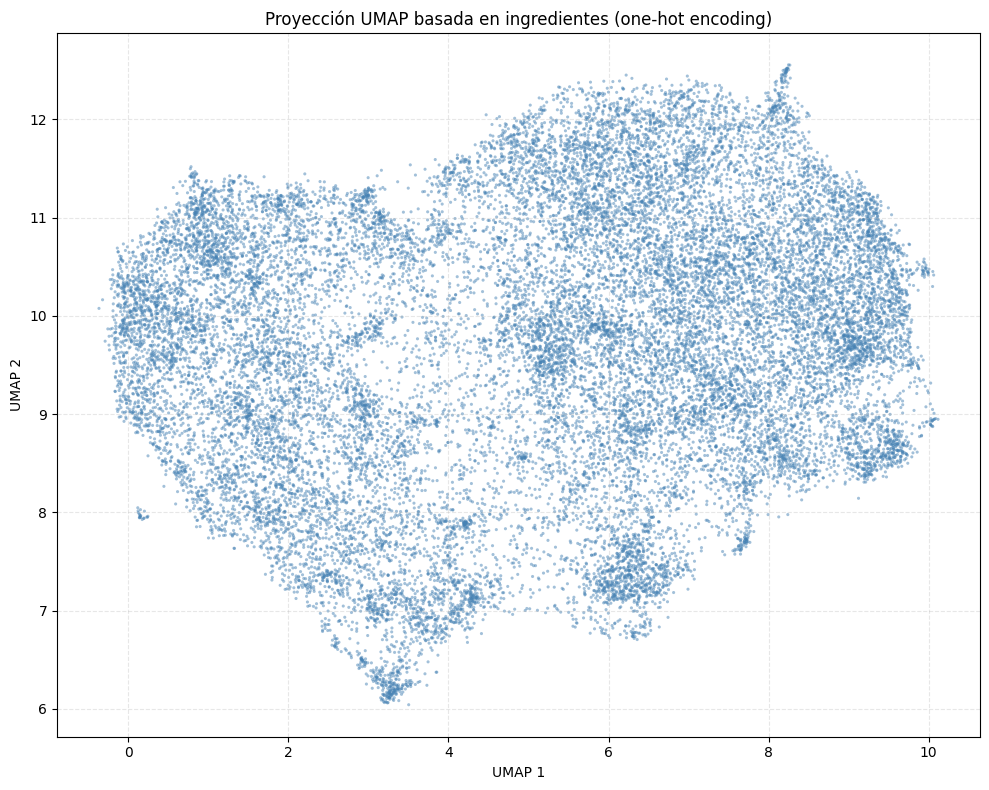

In [ ]:
# =============================================================
# Visualización UMAP basada en ingredientes (one-hot)
# =============================================================

plt.figure(figsize=(10, 8))
plt.scatter(
    df_umap_ingredientes['UMAP_1'], 
    df_umap_ingredientes['UMAP_2'],
    s=5, 
    alpha=0.5, 
    color='steelblue',
    edgecolors='none'
)

plt.title("Proyección UMAP basada en ingredientes (one-hot encoding)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/one_hot_ingredients_con_UMAP.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Compara la visualización obtenida con los <strong>embeddings semánticos</strong> (generados con MiniLM) 
    y la nueva proyección obtenida a partir de la <strong>representación one-hot</strong> de los ingredientes.
    Describe las principales diferencias que observes entre ambas.
  </p>
  <p>
    Justifica tu respuesta planteando una <strong>hipótesis</strong> sobre por qué los puntos se organizan de forma distinta 
    en cada caso. Puedes reflexionar sobre qué tipo de información captura cada representación y cómo eso afecta a la estructura 
    de los grupos observados.
  </p>
</div>

Las dos visualizaciones revelan diferencias fundamentales en cómo cada representación captura la información de las recetas.

**La proyección con embeddings semánticos** muestra una estructura fragmentada en múltiples clusters bien diferenciados, separados por espacios vacíos significativos. Los puntos forman "islas" distintas que sugieren agrupaciones naturales por tipos de cocina o categorías culinarias. Esta distribución refleja cómo MiniLM captura relaciones de significado: entiende que "mozzarella" y "parmesano" son conceptualmente similares, que ciertos ingredientes definen tradiciones culinarias específicas, y que existe una jerarquía semántica entre los alimentos. Los clusters probablemente, como se vio en apartados anteriores, corresponden a cocina italiana, asiática, postres y otras categorías, mientras que los espacios vacíos representan las brechas conceptuales entre estos dominios culinarios.

En contraste, **la proyección one-hot** produce una masa compacta y prácticamente circular, con densidad uniforme y sin separaciones claras. Esta representación solo codifica presencia o ausencia de ingredientes, tratando "sal" y "azúcar" como elementos tan diferentes entre sí como "sal" y "chocolate". Sin información semántica, la similitud se reduce a mera coocurrencia estadística. La continuidad del espacio surge porque la mayoría de recetas comparten ingredientes básicos comunes (pej.,sal, aceite, agua) creando transiciones graduales donde todas las recetas están "algo relacionadas" sin estructura significativa.

Por lo tanto, podriamos observando ambas visualizaciones se evidenciar que la diferencia esencial es que los embeddings semánticos revelan la arquitectura conceptual subyacente de la gastronomía, mientras que el one-hot encoding solo detecta patrones superficiales de ingredientes compartidos, incapaz de distinguir entre similitudes culinarias verdaderas y coincidencias estadísticas.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> A partir de la nueva representación <strong>one-hot de ingredientes</strong>, decide qué 
    <strong>algoritmo de clustering</strong> utilizarías para agrupar las recetas. 
    Explica si mantendrías el mismo algoritmo usado en el caso anterior o si elegirías otro, 
    justificando tu decisión en función de la estructura observada en los datos.
  </p>
  <p>
    Si el algoritmo elegido requiere una <strong>métrica de similitud o distancia</strong>, 
    indica cuál utilizarías (por ejemplo, <em>Jaccard</em>, <em>coseno</em> o <em>euclídea</em>) 
    y argumenta por qué resulta más adecuada para este tipo de datos binarios.
  </p>
</div>

Dado que la representación one-hot es **binaria y dispersa** (aproximadamente 99% de ceros), `K-Means` resulta inadecuado. Este algoritmo asume distancia euclidiana y clusters esféricos, pero en vectores binarios donde la mayoría de valores son ceros, la similitud debe basarse en ingredientes compartidos, no en ausencias comunes.

Tras evaluar empíricamente `DBSCAN`, `HDBSCAN` y considerar `Agglomerative Clustering`, **HDBSCAN con distancia de Jaccard** se ve como la opción óptima para estos datos. La métrica de Jaccard mide similitud entre conjuntos como |A ∩ B| / |A ∪ B|, enfocándose exclusivamente en ingredientes presentes e ignorando la abundancia de ausencias que domina los vectores one-hot. 

`HDBSCAN` supera a `DBSCAN` al manejar mejor la distribución uniforme observada en la proyección UMAP. Mientras `DBSCAN` produce hasta 66.7% de outliers o un único cluster dominante independientemente de los parámetros elegidos, `HDBSCAN` reduce los outliers al 38% y descubre estructuras jerárquicas más balanceadas. Su enfoque jerárquico identifica clusters de diferentes densidades simultáneamente sin requerir especificar su número a priori, y detecta automáticamente outliers que representan recetas con combinaciones únicas de ingredientes.

La experimentación reveló que con `min_cluster_size=20` y `min_samples=3`, `HDBSCAN` identifica aproximadamente 26 clusters interpretables que capturan patrones culinarios reales: postres con alta presencia de azúcar, mantequilla y huevos, versus platos salados con perfiles de ingredientes distintos. Aunque las métricas de calidad (Silhouette ≈ 0, Davies-Bouldin alto) reflejan la dificultad inherente de clustering en datos one-hot, los patrones descubiertos son semánticamente coherentes y superiores a las alternativas consideradas.

In [ ]:
# ==============================================================================
# FUNCIÓN DE EXPLORACIÓN RÁPIDA
# ==============================================================================

def explorar_parametros(df_ingredientes_onehot, df_original, 
                       eps_list, min_samples_list, metric='jaccard'):
    """
    Prueba rápidamente múltiples combinaciones y muestra resumen comparativo.
    """
    resultados = []
    
    print("="*80)
    print("EXPLORACIÓN RÁPIDA DE PARÁMETROS")
    print("="*80)
    
    X = df_ingredientes_onehot.values
    total = len(eps_list) * len(min_samples_list)
    counter = 0
    
    for eps in eps_list:
        for min_samples in min_samples_list:
            counter += 1
            print(f"\n[{counter}/{total}] Probando eps={eps}, min_samples={min_samples}...")
            
            clusterer = DBSCAN(eps=eps, min_samples=min_samples, 
                             metric=metric, n_jobs=-1)
            labels = clusterer.fit_predict(X)
            
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            noise_pct = (n_noise / len(labels)) * 100
            
            # Silhouette
            if n_clusters >= 2 and n_noise < len(labels):
                labels_no_noise = labels[labels != -1]
                X_no_noise = X[labels != -1]
                if len(labels_no_noise) > 0 and len(set(labels_no_noise)) > 1:
                    silhouette = silhouette_score(X_no_noise, labels_no_noise, metric=metric)
                else:
                    silhouette = -1
            else:
                silhouette = -1
            
            resultados.append({
                'eps': eps,
                'min_samples': min_samples,
                'clusters': n_clusters,
                'ruido': n_noise,
                'ruido_%': noise_pct,
                'silhouette': silhouette
            })
            
            print(f"   → {n_clusters} clusters, {n_noise} ruido ({noise_pct:.1f}%), silhouette={silhouette:.3f}")
    
    # Mostrar tabla resumen
    df_resultados = pd.DataFrame(resultados)
    
    print("\n" + "="*80)
    print("RESUMEN COMPARATIVO")
    print("="*80)
    print(df_resultados.to_string(index=False))
    
    # Sugerencias
    print("\n" + "="*80)
    print("💡 SUGERENCIAS")
    print("="*80)
    
    # Mejor por silhouette
    df_validos = df_resultados[df_resultados['silhouette'] > 0]
    if len(df_validos) > 0:
        mejor = df_validos.loc[df_validos['silhouette'].idxmax()]
        print(f"\n✓ Mejor configuración (silhouette):")
        print(f"   eps={mejor['eps']}, min_samples={int(mejor['min_samples'])}")
        print(f"   → {int(mejor['clusters'])} clusters, silhouette={mejor['silhouette']:.3f}")
    
    # Más clusters
    mejor_clusters = df_resultados.loc[df_resultados['clusters'].idxmax()]
    if mejor_clusters['clusters'] > 0:
        print(f"\n✓ Más clusters encontrados:")
        print(f"   eps={mejor_clusters['eps']}, min_samples={int(mejor_clusters['min_samples'])}")
        print(f"   → {int(mejor_clusters['clusters'])} clusters")
    
    # Menos ruido
    if (df_resultados['clusters'] > 0).any():
        df_con_clusters = df_resultados[df_resultados['clusters'] > 0]
        menos_ruido = df_con_clusters.loc[df_con_clusters['ruido_%'].idxmin()]
        print(f"\n✓ Menos ruido (con clusters):")
        print(f"   eps={menos_ruido['eps']}, min_samples={int(menos_ruido['min_samples'])}")
        print(f"   → {menos_ruido['ruido_%']:.1f}% ruido")
    
    return df_resultados

In [ ]:
# Exploración múltiple
resultados = explorar_parametros(
    df_ingredientes_onehot, df_sample,
    eps_list=[0.2, 0.3, 0.4, 0.5, 0.6],
    min_samples_list=[3, 5, 10, 15]
)

EXPLORACIÓN RÁPIDA DE PARÁMETROS

[1/20] Probando eps=0.2, min_samples=3...
   → 19 clusters, 24903 ruido (99.6%), silhouette=0.444

[2/20] Probando eps=0.2, min_samples=5...


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import umap
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# FUNCIÓN PRINCIPAL SIMPLIFICADA
# ==============================================================================

def dbscan_rapido(df_ingredientes_onehot, df_original, eps, min_samples, 
                  metric='jaccard', mostrar_visualizaciones=True):
    """
    Ejecuta DBSCAN de forma rápida y muestra resultados inmediatos.
    
    Parámetros:
    -----------
    df_ingredientes_onehot : DataFrame
        Matriz binaria de ingredientes (recetas x ingredientes)
    df_original : DataFrame
        DataFrame original con información de las recetas
    eps : float
        Radio máximo de vecindad
    min_samples : int
        Número mínimo de puntos para formar un cluster
    metric : str
        Métrica de distancia ('jaccard', 'hamming', 'cosine', etc.)
    mostrar_visualizaciones : bool
        Si True, muestra gráficos PCA y UMAP
    
    Returns:
    --------
    labels : array
        Etiquetas de cluster para cada receta (-1 = ruido)
    """
    
    print("="*80)
    print(f"DBSCAN: eps={eps}, min_samples={min_samples}, metric={metric}")
    print("="*80)
    
    # Convertir a array
    X = df_ingredientes_onehot.values
    
    # Entrenar DBSCAN
    print("\n⏳ Entrenando DBSCAN...")
    clusterer = DBSCAN(eps=eps, min_samples=min_samples, metric=metric, n_jobs=-1)
    labels = clusterer.fit_predict(X)
    
    # Métricas básicas
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = (n_noise / len(labels)) * 100
    
    print(f"\n📊 RESULTADOS:")
    print(f"   • Clusters encontrados: {n_clusters}")
    print(f"   • Puntos de ruido: {n_noise} ({noise_pct:.1f}%)")
    print(f"   • Recetas en clusters: {len(labels) - n_noise}")
    
    # Silhouette score (solo si hay clusters válidos)
    if n_clusters >= 2 and n_noise < len(labels):
        labels_no_noise = labels[labels != -1]
        X_no_noise = X[labels != -1]
        if len(labels_no_noise) > 0 and len(set(labels_no_noise)) > 1:
            silhouette = silhouette_score(X_no_noise, labels_no_noise, metric=metric)
            print(f"   • Silhouette Score: {silhouette:.4f}")
    
    # Tamaños de clusters
    if n_clusters > 0:
        print(f"\n📏 TAMAÑO DE CLUSTERS:")
        cluster_sizes = pd.Series(labels[labels != -1]).value_counts().sort_index()
        for cluster_id, size in cluster_sizes.items():
            pct = (size / len(labels)) * 100
            print(f"   • Cluster {cluster_id}: {size} recetas ({pct:.1f}%)")
    
    # Visualizaciones
    if mostrar_visualizaciones and n_clusters > 0:
        visualizar_clusters(X, labels)
    
    # Análisis de clusters
    if n_clusters > 0:
        analizar_clusters(df_original, df_ingredientes_onehot, labels)
    else:
        print("\n⚠️  No se encontraron clusters. Prueba con:")
        print("   - Valores de eps más bajos")
        print("   - Valores de min_samples más bajos")
        print("   - Otra métrica de distancia")
    
    return labels


def visualizar_clusters(X, labels, max_samples=5000):
    """
    Visualiza clusters usando PCA y UMAP en paralelo.
    """
    print("\n📈 Generando visualizaciones...")
    
    # Muestreo si es necesario
    if len(X) > max_samples:
        indices = np.random.choice(len(X), max_samples, replace=False)
        X_sample = X[indices]
        labels_sample = labels[indices]
    else:
        X_sample = X
        labels_sample = labels
    
    # Separar ruido de clusters
    noise_mask = labels_sample == -1
    cluster_mask = ~noise_mask
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # === PCA ===
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_sample)
    
    # Plot clusters
    if cluster_mask.any():
        unique_clusters = np.unique(labels_sample[cluster_mask])
        n_colors = len(unique_clusters)
        colors = plt.cm.tab20(np.linspace(0, 1, n_colors))
        
        for i, cluster_id in enumerate(unique_clusters):
            mask = labels_sample == cluster_id
            axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                          c=[colors[i]], label=f'Cluster {cluster_id}',
                          alpha=0.6, s=30)
    
    # Plot ruido
    if noise_mask.any():
        axes[0].scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], 
                       c='lightgray', alpha=0.3, s=10, label='Ruido')
    
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
    axes[0].set_title('Proyección PCA', fontsize=13, fontweight='bold')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # === UMAP ===
    print("   Calculando UMAP...")
    reducer = umap.UMAP(n_components=2, metric='jaccard', 
                       n_neighbors=15, min_dist=0.1, 
                       random_state=42, verbose=False)
    X_umap = reducer.fit_transform(X_sample)
    
    # Plot clusters
    if cluster_mask.any():
        for i, cluster_id in enumerate(unique_clusters):
            mask = labels_sample == cluster_id
            axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1], 
                          c=[colors[i]], label=f'Cluster {cluster_id}',
                          alpha=0.6, s=30)
    
    # Plot ruido
    if noise_mask.any():
        axes[1].scatter(X_umap[noise_mask, 0], X_umap[noise_mask, 1], 
                       c='lightgray', alpha=0.3, s=10, label='Ruido')
    
    axes[1].set_xlabel('UMAP 1', fontsize=11)
    axes[1].set_ylabel('UMAP 2', fontsize=11)
    axes[1].set_title('Proyección UMAP', fontsize=13, fontweight='bold')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print("   ✓ Visualizaciones completadas")


def analizar_clusters(df_original, df_ingredientes_onehot, labels, top_clusters=10, top_ingredientes=5):
    """
    Muestra resumen de los top N clusters con sus ingredientes más frecuentes.
    """
    print("\n" + "="*80)
    print(f"TOP {top_clusters} CLUSTERS MÁS GRANDES")
    print("="*80)
    
    # Contar tamaños de clusters (sin ruido)
    cluster_sizes = pd.Series(labels[labels != -1]).value_counts()
    top_cluster_ids = cluster_sizes.head(top_clusters).index
    
    # Analizar cada cluster
    for cluster_id in top_cluster_ids:
        mask = labels == cluster_id
        n_recetas = mask.sum()
        pct = (n_recetas / len(labels)) * 100
        
        print(f"\n{'─'*80}")
        print(f"CLUSTER {cluster_id} → {n_recetas} recetas ({pct:.1f}%)")
        print(f"{'─'*80}")
        
        # Ingredientes más frecuentes
        ingredientes_cluster = df_ingredientes_onehot[mask]
        freq_ingredientes = ingredientes_cluster.sum().sort_values(ascending=False).head(top_ingredientes)
        
        print(f"\n🥘 Top {top_ingredientes} ingredientes:")
        for ing, freq in freq_ingredientes.items():
            freq_pct = (freq / n_recetas) * 100
            print(f"   • {ing}: {int(freq)} recetas ({freq_pct:.0f}%)")
        
        # Recetas de ejemplo
        if 'name' in df_original.columns:
            recetas_ejemplo = df_original[mask]['name'].head(5).tolist()
            print(f"\n📋 Ejemplos de recetas:")
            for i, receta in enumerate(recetas_ejemplo, 1):
                print(f"   {i}. {receta}")

In [ ]:
labels = dbscan_rapido(
    df_ingredientes_onehot=df_ingredientes_onehot,
    df_original=df_sample,
    eps=0.3,
    min_samples=3,
    metric='jaccard'
)

## 2. K-means

In [ ]:
# ===========================================================================
# Determinación del número óptimo de clusters (K-Means) - MÉTRICA JACCARD
# ===========================================================================
def evaluar_kmeans_jaccard(X, k_range, random_state=42):
    """
    Evalúa KMeans con distancia Jaccard para datos binarios.
    Calcula inercia y silhouette con Jaccard y muestra visualización independiente.
    """
    resultados = []

    for k in k_range:
        print(f"Evaluando K={k} (Jaccard)...", end='\r')
        kmeans = KMeans(n_clusters=k,
                        random_state=random_state,
                        n_init=10, 
                        max_iter=300,
                        init='k-means++' 
            )
        
        labels = kmeans.fit_predict(X)

        # Inercia con distancia Jaccard
        centers = kmeans.cluster_centers_
        distances = cdist(X, centers, metric='jaccard')
        inertia_jaccard = np.sum(np.min(distances, axis=1))

        # Silhouette con Jaccard
        silhouette = silhouette_score(X, labels, metric='jaccard')

        cluster_sizes = np.bincount(labels)
        resultados.append({
            'k': k,
            'inertia_jaccard': inertia_jaccard,
            'silhouette_jaccard': silhouette,
            'min_cluster_size': cluster_sizes.min(),
            'max_cluster_size': cluster_sizes.max(),
            'mean_cluster_size': cluster_sizes.mean()
        })

    print(" " * 50, end='\r')
    df = pd.DataFrame(resultados)

    # =============================================================
    # Visualización conjunta
    # =============================================================    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    color_elbow = 'tab:blue'
    color_silhouette = 'tab:orange'
    
    # --- Curva del método del codo (inercia) ---
    ax1.set_xlabel('Número de clusters (k)')
    ax1.set_ylabel('Inercia (Jaccard)', color=color_elbow)
    ax1.plot(df['k'], df['inertia_jaccard'], 'o-', color=color_elbow, label='Inercia Jaccard')
    ax1.tick_params(axis='y', labelcolor=color_elbow)

    # --- Segundo eje para Silhouette ---
    ax2 = ax1.twinx()
    ax2.set_ylabel('Coeficiente de Silhouette (Jaccard)', color=color_silhouette)
    ax2.plot(df['k'], df['silhouette_jaccard'], 's--', color=color_silhouette, label='Silhouette Jaccard')
    ax2.tick_params(axis='y', labelcolor=color_silhouette)

    plt.title('Método del Codo y Silhouette (Distancia Jaccard)')
    fig.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.savefig(r'../Visualizaciones/regla_del_codo_y_silhouette_one_hot_jaccard.png', dpi=300)
    plt.show()

    return df

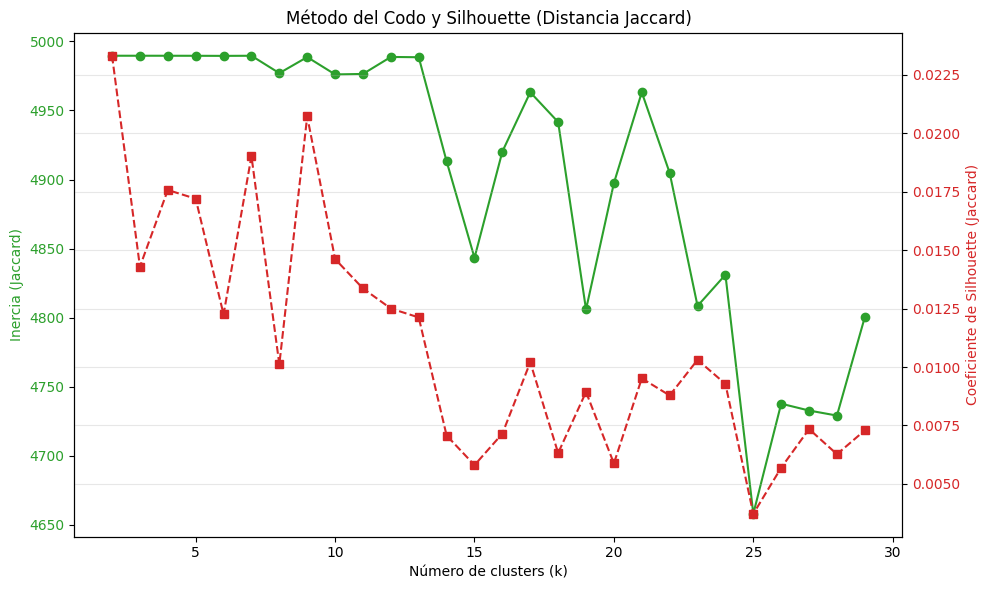

,k,inertia_jaccard,silhouette_jaccard,min_cluster_size,max_cluster_size,mean_cluster_size
0,2,4989.601368,0.023314,1861,3139,2500.000000
1,3,4989.601368,0.014292,835,2886,1666.666667
2,4,4989.590430,0.017572,792,2408,1250.000000
3,5,4989.564093,0.017198,629,2043,1000.000000
4,6,4989.501090,0.012251,307,2035,833.333333
5,7,4989.589667,0.019020,507,1588,714.285714
6,8,4976.992006,0.010115,149,1908,625.000000
7,9,4988.618864,0.020722,160,1387,555.555556
8,10,4976.085311,0.014618,218,1602,500.000000
9,11,4976.421711,0.013361,146,1490,454.545455


In [30]:
# --- Datos de entrada ---
# Convertimos a array numpy
X = df_ingredientes_onehot.values

# --- Rango de k a evaluar ---
k_range = range(2, 30)

evaluar_kmeans_jaccard(X, k_range, random_state=42, save_path=None)

Clusters encontrados: 25
Sin ruido explícito (KMeans asigna todos los puntos a algún cluster).
ANÁLISIS DE CLUSTERS

CLUSTER 0 - 73 recetas (1.46%)

Top 10 ingredientes más comunes:
  • cinnamon: 70 recetas (95.9%)
  • sugar: 63 recetas (86.3%)
  • butter: 62 recetas (84.9%)
  • flour: 37 recetas (50.7%)
  • nutmeg: 37 recetas (50.7%)
  • salt: 34 recetas (46.6%)
  • brown sugar: 28 recetas (38.4%)
  • eggs: 26 recetas (35.6%)
  • water: 25 recetas (34.2%)
  • egg: 18 recetas (24.7%)

Muestra de 3 recetas del cluster:
  - Bourbon Spiced Apple Pie
  - Cranberry Orange Rugelach
  - Raisin Cream Pie

CLUSTER 1 - 249 recetas (4.98%)

Top 10 ingredientes más comunes:
  • garlic cloves: 249 recetas (100.0%)
  • salt: 114 recetas (45.8%)
  • onion: 97 recetas (39.0%)
  • extra virgin olive oil: 63 recetas (25.3%)
  • vegetable oil: 31 recetas (12.4%)
  • water: 29 recetas (11.6%)
  • tomatoes: 26 recetas (10.4%)
  • onions: 26 recetas (10.4%)
  • black pepper: 26 recetas (10.4%)
  • parmesan 

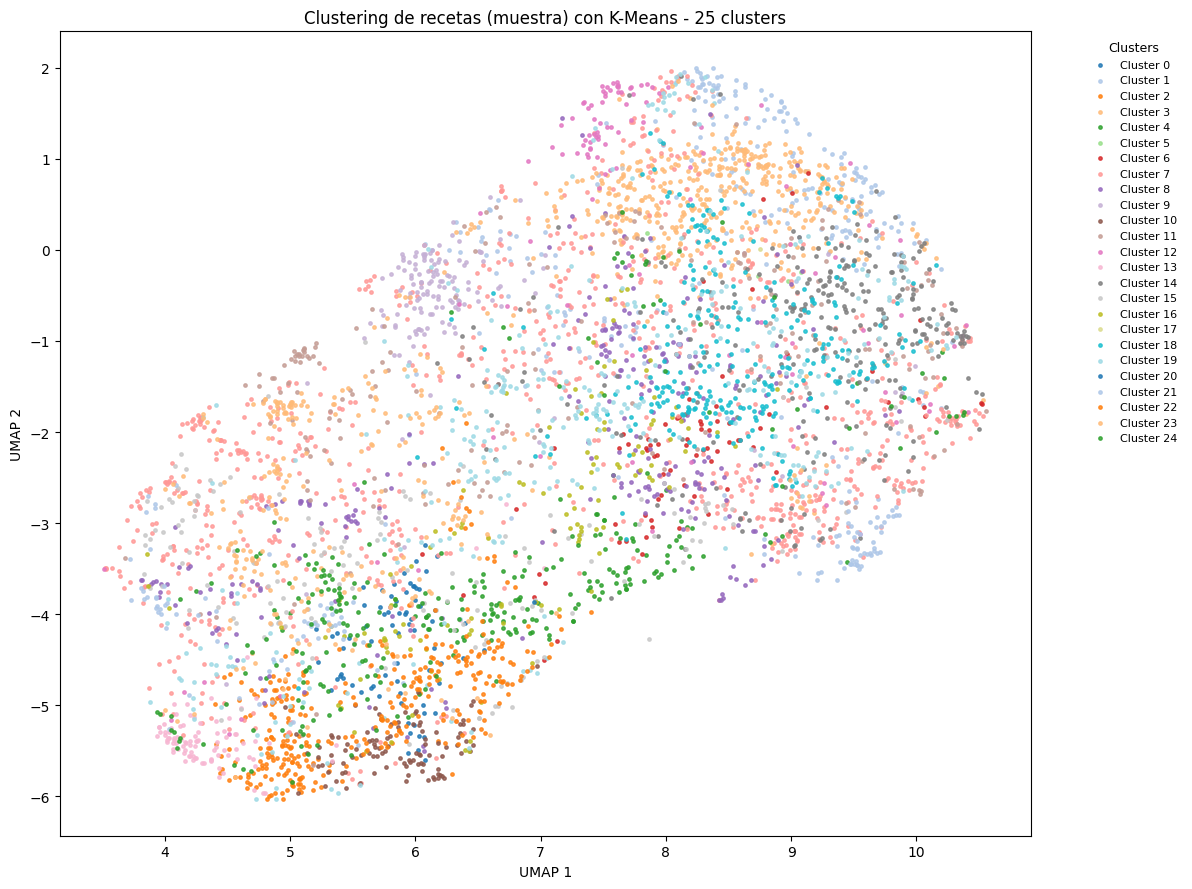

In [40]:
# =============================================================
# Clustering con K-Means sobre one-hot ingredientes (muestra)
# =============================================================

# --- Selección del número de clusters ---
# Determinado con el método del codo o silhouette.
n_clusters = 25

# --- Inicialización y entrenamiento ---
kmeans = KMeans(
        n_clusters=n_clusters,    # número de clusters elegido
        random_state=42,          # semilla para reproducibilidad
        n_init=10,                # nº de inicializaciones diferentes
        max_iter=300,             # nº máximo de iteraciones por ejecución
        init='k-means++',         # inicialización inteligente de centroides
        tol=1e-4                  # tolerancia para convergencia
)

labels_sample = kmeans.fit_predict(df_ingredientes_onehot)

print(f"Clusters encontrados: {n_clusters}")
print(f"Sin ruido explícito (KMeans asigna todos los puntos a algún cluster).")

def analizar_clusters(df_original, labels, df_ingredientes, top_n=10):
    """
    Analiza las características de cada cluster
    """
    df_analisis = df_original.copy()
    df_analisis['cluster'] = labels
    
    print("="*80)
    print("ANÁLISIS DE CLUSTERS")
    print("="*80)
    
    for cluster_id in sorted(df_analisis['cluster'].unique()):
        recetas_cluster = df_analisis[df_analisis['cluster'] == cluster_id]
        n_recetas = len(recetas_cluster)
        
        print(f"\n{'='*80}")
        print(f"CLUSTER {cluster_id} - {n_recetas} recetas ({n_recetas/len(df_analisis)*100:.2f}%)")
        print(f"{'='*80}")
        
        # Ingredientes más frecuentes en este cluster
        ingredientes_cluster = df_ingredientes.loc[recetas_cluster.index]
        freq_ingredientes = ingredientes_cluster.sum().sort_values(ascending=False).head(top_n)
        
        print(f"\nTop {top_n} ingredientes más comunes:")
        for ing, freq in freq_ingredientes.items():
            print(f"  • {ing}: {freq} recetas ({freq/n_recetas*100:.1f}%)")
        
        # Muestra de recetas
        if 'name' in recetas_cluster.columns:
            print(f"\nMuestra de 3 recetas del cluster:")
            for idx, row in recetas_cluster.head(3).iterrows():
                print(f"  - {row['name']}")


analizar_clusters(df_sample, labels_sample, df_ingredientes_onehot, top_n=10)

# =============================================================
# Visualización de los clusters (UMAP de la muestra) con leyenda
# =============================================================
reducer_sample = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

embeddings_2d_sample = reducer_sample.fit_transform(df_ingredientes_onehot)

# --- Colores de clusters ---
palette = sns.color_palette('tab20', n_colors=n_clusters)
colors = [palette[int(label % len(palette))] for label in labels_sample]

plt.figure(figsize=(12, 9))

# --- Dibujar cada cluster por separado para poder etiquetar ---
for cluster_id in range(n_clusters):
    mask = labels_sample == cluster_id
    plt.scatter(
        embeddings_2d_sample[mask, 0],
        embeddings_2d_sample[mask, 1],
        s=6,
        color=palette[cluster_id % len(palette)],
        alpha=0.8,
        label=f'Cluster {cluster_id}'
    )

# --- Títulos y etiquetas ---
plt.title(f"Clustering de recetas (muestra) con K-Means - {n_clusters} clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# --- Leyenda fuera del área del gráfico ---
plt.legend(
    title="Clusters",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=8,
    title_fontsize=9,
    frameon=False
)

plt.tight_layout()
plt.savefig(r'../Visualizaciones/kmeans_clusters_umap_one_hot_jaccard.png', dpi=300, bbox_inches='tight')
plt.show()

K-Means (incluso con métrica Jaccard) no está separando grupos naturales; el espacio binario es demasiado grande y plano.
Los valores de silhouette cercanos a 0 confirman que las distancias Jaccard no distinguen bien las recetas.

-  Silhouette muy bajo (≈ 0.01–0.02):
Esto indica que las distancias entre puntos dentro de un cluster no son mucho menores que entre clusters → los grupos están poco definidos.

-  Inercia casi constante entre k=2 y k=10:
No hay un “codo” claro: el modelo no está captando estructura real. Es típico en datos dispersos y binarios de alta dimensión.

-  Distribución de tamaños desigual:
Algunos clusters grandes y otros pequeños, lo cual puede sugerir sobreajuste o clusters que agrupan ruido.

## 2.  DBSCAN

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import pdist, squareform
import umap
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# FUNCIONES AUXILIARES
# ==============================================================================

def evaluar_dbscan_parametros(X, eps_list, min_samples_list, metric='jaccard'):
    """
    Evalúa diferentes combinaciones de hiperparámetros para DBSCAN
    
    Parámetros clave:
    - eps: Radio máximo de vecindad (epsilon)
    - min_samples: Número mínimo de puntos para formar un cluster
    """
    resultados = []
    total = len(eps_list) * len(min_samples_list)
    counter = 0
    
    for eps in eps_list:
        for min_samples in min_samples_list:
            counter += 1
            print(f"Evaluando {counter}/{total}: eps={eps:.3f}, min_samples={min_samples}...", end='\r')
            
            # Entrenar DBSCAN
            clusterer = DBSCAN(
                eps=eps,
                min_samples=min_samples,
                metric=metric,
                n_jobs=-1
            )
            
            labels = clusterer.fit_predict(X)
            
            # Calcular métricas
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            
            # Silhouette solo si hay al menos 2 clusters y no todo es ruido
            if n_clusters >= 2 and n_noise < len(labels):
                # Calcular silhouette sin puntos de ruido
                labels_no_noise = labels[labels != -1]
                X_no_noise = X[labels != -1]
                
                if len(labels_no_noise) > 0 and len(set(labels_no_noise)) > 1:
                    silhouette = silhouette_score(X_no_noise, labels_no_noise, metric=metric)
                else:
                    silhouette = -1
            else:
                silhouette = -1
            
            # Cluster sizes (sin contar ruido)
            if n_clusters > 0:
                cluster_sizes = [sum(labels == i) for i in set(labels) if i != -1]
                min_size = min(cluster_sizes) if cluster_sizes else 0
                max_size = max(cluster_sizes) if cluster_sizes else 0
                mean_size = np.mean(cluster_sizes) if cluster_sizes else 0
            else:
                min_size = max_size = mean_size = 0
            
            resultados.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_pct': (n_noise / len(labels)) * 100,
                'silhouette': silhouette,
                'min_cluster': min_size,
                'max_cluster': max_size,
                'mean_cluster': mean_size
            })
    
    print(" " * 100, end='\r')
    return pd.DataFrame(resultados)


def estimar_eps_optimo(X, k=5, metric='jaccard', sample_size=1000):
    """
    Estima un rango apropiado de eps usando k-nearest neighbors
    Calcula la distancia al k-ésimo vecino más cercano
    """
    print(f"\nEstimando rango de eps (muestreando {sample_size} puntos)...")
    
    # Muestreo para acelerar
    if len(X) > sample_size:
        indices = np.random.choice(len(X), sample_size, replace=False)
        X_sample = X[indices]
    else:
        X_sample = X
    
    # Calcular matriz de distancias
    print("Calculando distancias...")
    distances = pdist(X_sample, metric=metric)
    dist_matrix = squareform(distances)
    
    # Para cada punto, encontrar distancia al k-ésimo vecino
    k_distances = []
    for i in range(len(X_sample)):
        # Ordenar distancias (excluyendo la distancia a sí mismo)
        sorted_distances = np.sort(dist_matrix[i])
        if len(sorted_distances) > k:
            k_distances.append(sorted_distances[k])
    
    k_distances = np.array(k_distances)
    k_distances = np.sort(k_distances)
    
    # Visualizar k-distance plot
    plt.figure(figsize=(10, 6))
    plt.plot(k_distances, linewidth=2)
    plt.xlabel('Puntos ordenados', fontsize=12)
    plt.ylabel(f'{k}-distancia (Jaccard)', fontsize=12)
    plt.title(f'K-Distance Plot para Estimación de Eps (k={k})', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Sugerir rango
    percentiles = [50, 75, 90, 95]
    for p in percentiles:
        val = np.percentile(k_distances, p)
        plt.axhline(y=val, color='r', linestyle='--', alpha=0.5, 
                   label=f'Percentil {p}: {val:.3f}')
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Sugerencias
    eps_min = np.percentile(k_distances, 50)
    eps_max = np.percentile(k_distances, 95)
    
    print(f"\nRango sugerido de eps: [{eps_min:.3f}, {eps_max:.3f}]")
    print(f"Percentil 50: {eps_min:.3f}")
    print(f"Percentil 75: {np.percentile(k_distances, 75):.3f}")
    print(f"Percentil 90: {np.percentile(k_distances, 90):.3f}")
    print(f"Percentil 95: {eps_max:.3f}")
    
    return eps_min, eps_max


def visualizar_evaluacion_dbscan(df_resultados):
    """
    Visualiza los resultados de la evaluación de DBSCAN
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Pivot tables para heatmaps
    pivot_clusters = df_resultados.pivot(
        index='eps', 
        columns='min_samples', 
        values='n_clusters'
    )
    
    pivot_noise = df_resultados.pivot(
        index='eps', 
        columns='min_samples', 
        values='noise_pct'
    )
    
    pivot_silhouette = df_resultados.pivot(
        index='eps', 
        columns='min_samples', 
        values='silhouette'
    )
    
    # 1. Número de clusters
    sns.heatmap(pivot_clusters, annot=True, fmt='.0f', cmap='YlOrRd', 
                ax=axes[0, 0], cbar_kws={'label': 'N° Clusters'})
    axes[0, 0].set_title('Número de Clusters', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('min_samples', fontsize=11)
    axes[0, 0].set_ylabel('eps', fontsize=11)
    
    # 2. Porcentaje de ruido
    sns.heatmap(pivot_noise, annot=True, fmt='.1f', cmap='YlOrRd', 
                ax=axes[0, 1], cbar_kws={'label': '% Ruido'})
    axes[0, 1].set_title('Porcentaje de Ruido', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('min_samples', fontsize=11)
    axes[0, 1].set_ylabel('eps', fontsize=11)
    
    # 3. Silhouette Score
    sns.heatmap(pivot_silhouette, annot=True, fmt='.3f', cmap='RdYlGn', 
                ax=axes[1, 0], cbar_kws={'label': 'Silhouette'}, center=0)
    axes[1, 0].set_title('Silhouette Score (Jaccard)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('min_samples', fontsize=11)
    axes[1, 0].set_ylabel('eps', fontsize=11)
    
    # 4. Tabla resumen de mejores configuraciones
    axes[1, 1].axis('off')
    
    # Top 5 configuraciones por silhouette
    top_configs = df_resultados.nlargest(5, 'silhouette')[
        ['eps', 'min_samples', 'n_clusters', 'noise_pct', 'silhouette']
    ].round(3)
    
    table_data = [['eps', 'min_samples', 'clusters', 'noise%', 'silhouette']]
    for _, row in top_configs.iterrows():
        table_data.append([
            f"{row['eps']:.3f}",
            f"{int(row['min_samples'])}",
            f"{int(row['n_clusters'])}",
            f"{row['noise_pct']:.1f}",
            f"{row['silhouette']:.3f}"
        ])
    
    table = axes[1, 1].table(cellText=table_data, cellLoc='center', loc='center',
                            colWidths=[0.15, 0.18, 0.15, 0.15, 0.18])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Estilo de header
    for i in range(5):
        table[(0, i)].set_facecolor('#2196F3')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    axes[1, 1].set_title('Top 5 Configuraciones (por Silhouette)', 
                        fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()


def visualizar_clusters_pca_umap(X, labels, max_samples=5000):
    """
    Visualiza los clusters usando PCA y UMAP en paralelo
    """
    # Muestreo si es necesario
    if len(X) > max_samples:
        indices = np.random.choice(len(X), max_samples, replace=False)
        X_sample = X[indices]
        labels_sample = labels[indices]
    else:
        X_sample = X
        labels_sample = labels
    
    # Crear figura con 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Separar ruido de clusters
    noise_mask = labels_sample == -1
    cluster_mask = ~noise_mask
    n_clusters = len(set(labels_sample)) - (1 if -1 in labels_sample else 0)
    n_noise = sum(noise_mask)
    
    # === SUBPLOT 1: PCA ===
    print("Calculando PCA...")
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_sample)
    
    # Plot clusters
    if cluster_mask.any():
        scatter1 = axes[0].scatter(
            X_pca[cluster_mask, 0], 
            X_pca[cluster_mask, 1], 
            c=labels_sample[cluster_mask], 
            cmap='tab10', 
            alpha=0.6, 
            s=30
        )
        plt.colorbar(scatter1, ax=axes[0], label='Cluster ID')
    
    # Plot ruido
    if noise_mask.any():
        axes[0].scatter(
            X_pca[noise_mask, 0], 
            X_pca[noise_mask, 1], 
            c='gray', 
            alpha=0.3, 
            s=10,
            label='Ruido'
        )
    
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)', fontsize=12)
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)', fontsize=12)
    axes[0].set_title(f'PCA: {n_clusters} Clusters, {n_noise} ruido', 
                      fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # === SUBPLOT 2: UMAP ===
    print("Calculando UMAP (esto puede tardar unos minutos)...")
    reducer = umap.UMAP(
        n_components=2,
        metric='jaccard',
        n_neighbors=15,
        min_dist=0.1,
        random_state=42,
        verbose=False
    )
    X_umap = reducer.fit_transform(X_sample)
    
    # Plot clusters
    if cluster_mask.any():
        scatter2 = axes[1].scatter(
            X_umap[cluster_mask, 0], 
            X_umap[cluster_mask, 1], 
            c=labels_sample[cluster_mask], 
            cmap='tab10', 
            alpha=0.6, 
            s=30
        )
        plt.colorbar(scatter2, ax=axes[1], label='Cluster ID')
    
    # Plot ruido
    if noise_mask.any():
        axes[1].scatter(
            X_umap[noise_mask, 0], 
            X_umap[noise_mask, 1], 
            c='gray', 
            alpha=0.3, 
            s=10,
            label='Ruido'
        )
    
    axes[1].set_xlabel('UMAP 1', fontsize=12)
    axes[1].set_ylabel('UMAP 2', fontsize=12)
    axes[1].set_title(f'UMAP: {n_clusters} Clusters, {n_noise} ruido', 
                      fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print("Visualización completada.")


def analizar_clusters_dbscan(df_original, labels, df_ingredientes, top_n=10):
    """
    Analiza las características de cada cluster
    """
    df_analisis = df_original.copy()
    df_analisis['cluster'] = labels
    
    print("="*80)
    print("ANÁLISIS DE CLUSTERS DBSCAN")
    print("="*80)
    
    # Análisis de ruido
    n_noise = sum(labels == -1)
    if n_noise > 0:
        print(f"\n{'='*80}")
        print(f"RUIDO - {n_noise} recetas ({n_noise/len(df_analisis)*100:.2f}%)")
        print(f"{'='*80}")
        print("Estas recetas no se ajustan bien a ningún cluster.")
    
    # Análisis por cluster
    for cluster_id in sorted(set(labels)):
        if cluster_id == -1:
            continue
            
        recetas_cluster = df_analisis[df_analisis['cluster'] == cluster_id]
        n_recetas = len(recetas_cluster)
        
        print(f"\n{'='*80}")
        print(f"CLUSTER {cluster_id} - {n_recetas} recetas ({n_recetas/len(df_analisis)*100:.2f}%)")
        print(f"{'='*80}")
        
        # Ingredientes más frecuentes
        ingredientes_cluster = df_ingredientes.loc[recetas_cluster.index]
        freq_ingredientes = ingredientes_cluster.sum().sort_values(ascending=False).head(top_n)
        
        print(f"\nTop {top_n} ingredientes más comunes:")
        for ing, freq in freq_ingredientes.items():
            print(f"  • {ing}: {freq} recetas ({freq/n_recetas*100:.1f}%)")
        
        # Muestra de recetas
        if 'name' in recetas_cluster.columns:
            print(f"\nMuestra de 3 recetas del cluster:")
            for idx, row in recetas_cluster.head(3).iterrows():
                print(f"  - {row['name']}")


# ==============================================================================
# PIPELINE PRINCIPAL
# ==============================================================================

def pipeline_dbscan_recetas(df_ingredientes_onehot, df_original, 
                            eps_list=None, min_samples_list=None,
                            estimar_eps=True):
    """
    Pipeline completo de clustering DBSCAN para recetas
    
    Parámetros:
    -----------
    df_ingredientes_onehot : DataFrame
        Matriz binaria de ingredientes
    df_original : DataFrame
        DataFrame original con información de las recetas
    eps_list : list
        Lista de valores para eps a probar
    min_samples_list : list
        Lista de valores para min_samples a probar
    estimar_eps : bool
        Si True, estima el rango óptimo de eps antes de evaluar
    """
    
    print("="*80)
    print("CLUSTERING DBSCAN PARA RECETAS (Métrica: Jaccard)")
    print("="*80)
    print(f"\nDimensiones del dataset: {df_ingredientes_onehot.shape}")
    print(f"Sparsity: {(df_ingredientes_onehot == 0).sum().sum() / df_ingredientes_onehot.values.size * 100:.2f}%")
    
    # Convertir a array
    X = df_ingredientes_onehot.values
    
    # ESTIMACIÓN DE EPS
    if estimar_eps:
        print("\n" + "="*80)
        print("ESTIMACIÓN DE EPS ÓPTIMO")
        print("="*80)
        eps_min, eps_max = estimar_eps_optimo(X, k=5, sample_size=1000)
        
        if eps_list is None:
            # Generar lista de eps basada en la estimación
            eps_list = np.linspace(eps_min, eps_max, 5).round(3).tolist()
            print(f"\nEps generado automáticamente: {eps_list}")
    
    # Valores por defecto si no se proporcionaron
    if eps_list is None:
        eps_list = [0.3, 0.4, 0.5, 0.6, 0.7]
    
    if min_samples_list is None:
        min_samples_list = [5, 10, 20, 30]
    
    print(f"\nParámetros a evaluar:")
    print(f"  • eps: {eps_list}")
    print(f"  • min_samples: {min_samples_list}")
    print(f"  • Total combinaciones: {len(eps_list) * len(min_samples_list)}")
    
    # EVALUACIÓN DE HIPERPARÁMETROS
    print("\n" + "="*80)
    print("EVALUACIÓN DE HIPERPARÁMETROS")
    print("="*80)
    
    df_resultados = evaluar_dbscan_parametros(X, eps_list, min_samples_list)
    
    print("\nRESULTADOS COMPLETOS:")
    print(df_resultados.to_string(index=False))
    
    # RECOMENDACIÓN
    print("\n" + "="*80)
    print("RECOMENDACIÓN DE HIPERPARÁMETROS")
    print("="*80)
    
    # Filtrar configuraciones válidas
    df_validos = df_resultados[
        (df_resultados['n_clusters'] >= 2) & 
        (df_resultados['silhouette'] > 0)
    ].copy()
    
    if len(df_validos) == 0:
        print("\n⚠️  ADVERTENCIA: No se encontraron configuraciones con clustering válido.")
        print("Considera ajustar los rangos de eps y min_samples.")
        print("\nIntentando con configuraciones alternativas (al menos 1 cluster)...")
        
        # Intentar con criterios más permisivos
        df_validos = df_resultados[
            (df_resultados['n_clusters'] >= 1)
        ].copy()
        
        if len(df_validos) == 0:
            print("\n❌ No se encontró ninguna configuración que genere clusters.")
            print("Sugerencias:")
            print("  - Aumenta el rango de eps (valores más grandes)")
            print("  - Reduce min_samples")
            return None, None, df_resultados
    
    # Normalizar métricas
    silhouette_range = df_validos['silhouette'].max() - df_validos['silhouette'].min()
    if silhouette_range > 0:
        df_validos['silhouette_norm'] = (df_validos['silhouette'] - df_validos['silhouette'].min()) / silhouette_range
    else:
        df_validos['silhouette_norm'] = 0.5  # Valor neutro si todos son iguales
    
    df_validos['noise_norm'] = 1 - (df_validos['noise_pct'] / 100)
    
    # Score combinado (70% silhouette, 30% bajo ruido)
    df_validos['score_total'] = 0.7 * df_validos['silhouette_norm'] + 0.3 * df_validos['noise_norm']
    
    # Verificar que hay scores válidos
    if df_validos['score_total'].isna().all():
        print("\n❌ No se pudo calcular score válido.")
        return None, None, df_resultados
    
    mejor_config = df_validos.loc[df_validos['score_total'].idxmax()]
    
    print(f"\nCONFIGURACIÓN ÓPTIMA:")
    print(f"  • eps: {mejor_config['eps']:.3f}")
    print(f"  • min_samples: {int(mejor_config['min_samples'])}")
    print(f"\nRESULTADOS:")
    print(f"  • Número de clusters: {int(mejor_config['n_clusters'])}")
    print(f"  • Puntos de ruido: {int(mejor_config['n_noise'])} ({mejor_config['noise_pct']:.2f}%)")
    print(f"  • Silhouette Score: {mejor_config['silhouette']:.4f}")
    print(f"  • Tamaño medio cluster: {mejor_config['mean_cluster']:.0f} recetas")
    
    # VISUALIZACIONES
    print("\n" + "="*80)
    print("GENERANDO VISUALIZACIONES")
    print("="*80)
    visualizar_evaluacion_dbscan(df_resultados)
    
    # MODELO FINAL
    print("\n" + "="*80)
    print("ENTRENANDO MODELO FINAL")
    print("="*80)
    
    clusterer_final = DBSCAN(
        eps=mejor_config['eps'],
        min_samples=int(mejor_config['min_samples']),
        metric='jaccard',
        n_jobs=-1
    )
    
    labels_final = clusterer_final.fit_predict(X)
    
    # Visualizar
    print("\nGenerando visualización PCA + UMAP...")
    visualizar_clusters_pca_umap(X, labels_final)
    
    # Análisis
    analizar_clusters_dbscan(df_original, labels_final, df_ingredientes_onehot, top_n=15)
    
    return clusterer_final, labels_final, df_resultados


# ==============================================================================
# EJEMPLO DE USO
# ==============================================================================

if __name__ == "__main__":
    """
    # Ejecutar pipeline completo con estimación automática de eps
    modelo, labels, resultados = pipeline_dbscan_recetas(
        df_ingredientes_onehot=df_ingredientes_onehot,
        df_original=df,
        estimar_eps=True  # Estima el rango óptimo de eps
    )
    
    # O con parámetros personalizados
    modelo, labels, resultados = pipeline_dbscan_recetas(
        df_ingredientes_onehot=df_ingredientes_onehot,
        df_original=df,
        eps_list=[0.4, 0.5, 0.6, 0.7],
        min_samples_list=[5, 10, 20],
        estimar_eps=False
    )
    
    # Agregar labels al DataFrame original
    if labels is not None:
        df['cluster'] = labels
        print(df['cluster'].value_counts())
    """
    
    print("Script listo para ejecutar.")
    print("\nPara usar, ejecuta:")
    print("modelo, labels, resultados = pipeline_dbscan_recetas(df_ingredientes_onehot, df)")

Script listo para ejecutar.

Para usar, ejecuta:
modelo, labels, resultados = pipeline_dbscan_recetas(df_ingredientes_onehot, df)


CLUSTERING DBSCAN PARA RECETAS (Métrica: Jaccard)

Dimensiones del dataset: (5000, 4385)
Sparsity: 99.79%

ESTIMACIÓN DE EPS ÓPTIMO

Estimando rango de eps (muestreando 1000 puntos)...
Calculando distancias...


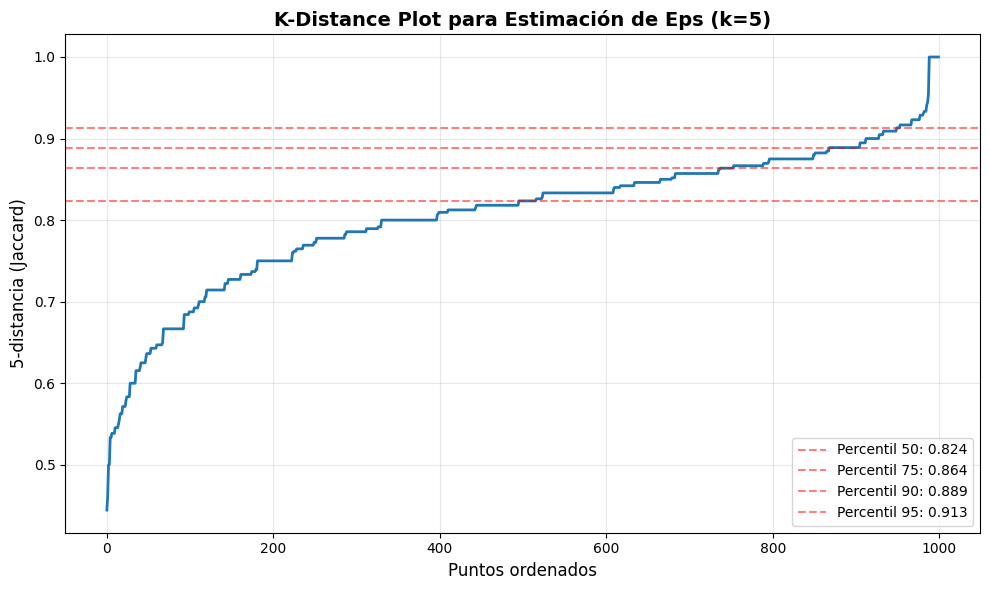


Rango sugerido de eps: [0.824, 0.913]
Percentil 50: 0.824
Percentil 75: 0.864
Percentil 90: 0.889
Percentil 95: 0.913

Eps generado automáticamente: [0.824, 0.846, 0.868, 0.891, 0.913]

Parámetros a evaluar:
  • eps: [0.824, 0.846, 0.868, 0.891, 0.913]
  • min_samples: [5, 10, 20, 30]
  • Total combinaciones: 20

EVALUACIÓN DE HIPERPARÁMETROS
                                                                                                    
RESULTADOS COMPLETOS:
  eps  min_samples  n_clusters  n_noise  noise_pct  silhouette  min_cluster  max_cluster  mean_cluster
0.824            5           2      387       7.74    0.031381            5         4608        2306.5
0.824           10           1      471       9.42   -1.000000         4529         4529        4529.0
0.824           20           1      614      12.28   -1.000000         4386         4386        4386.0
0.824           30           1      730      14.60   -1.000000         4270         4270        4270.0
0.846           

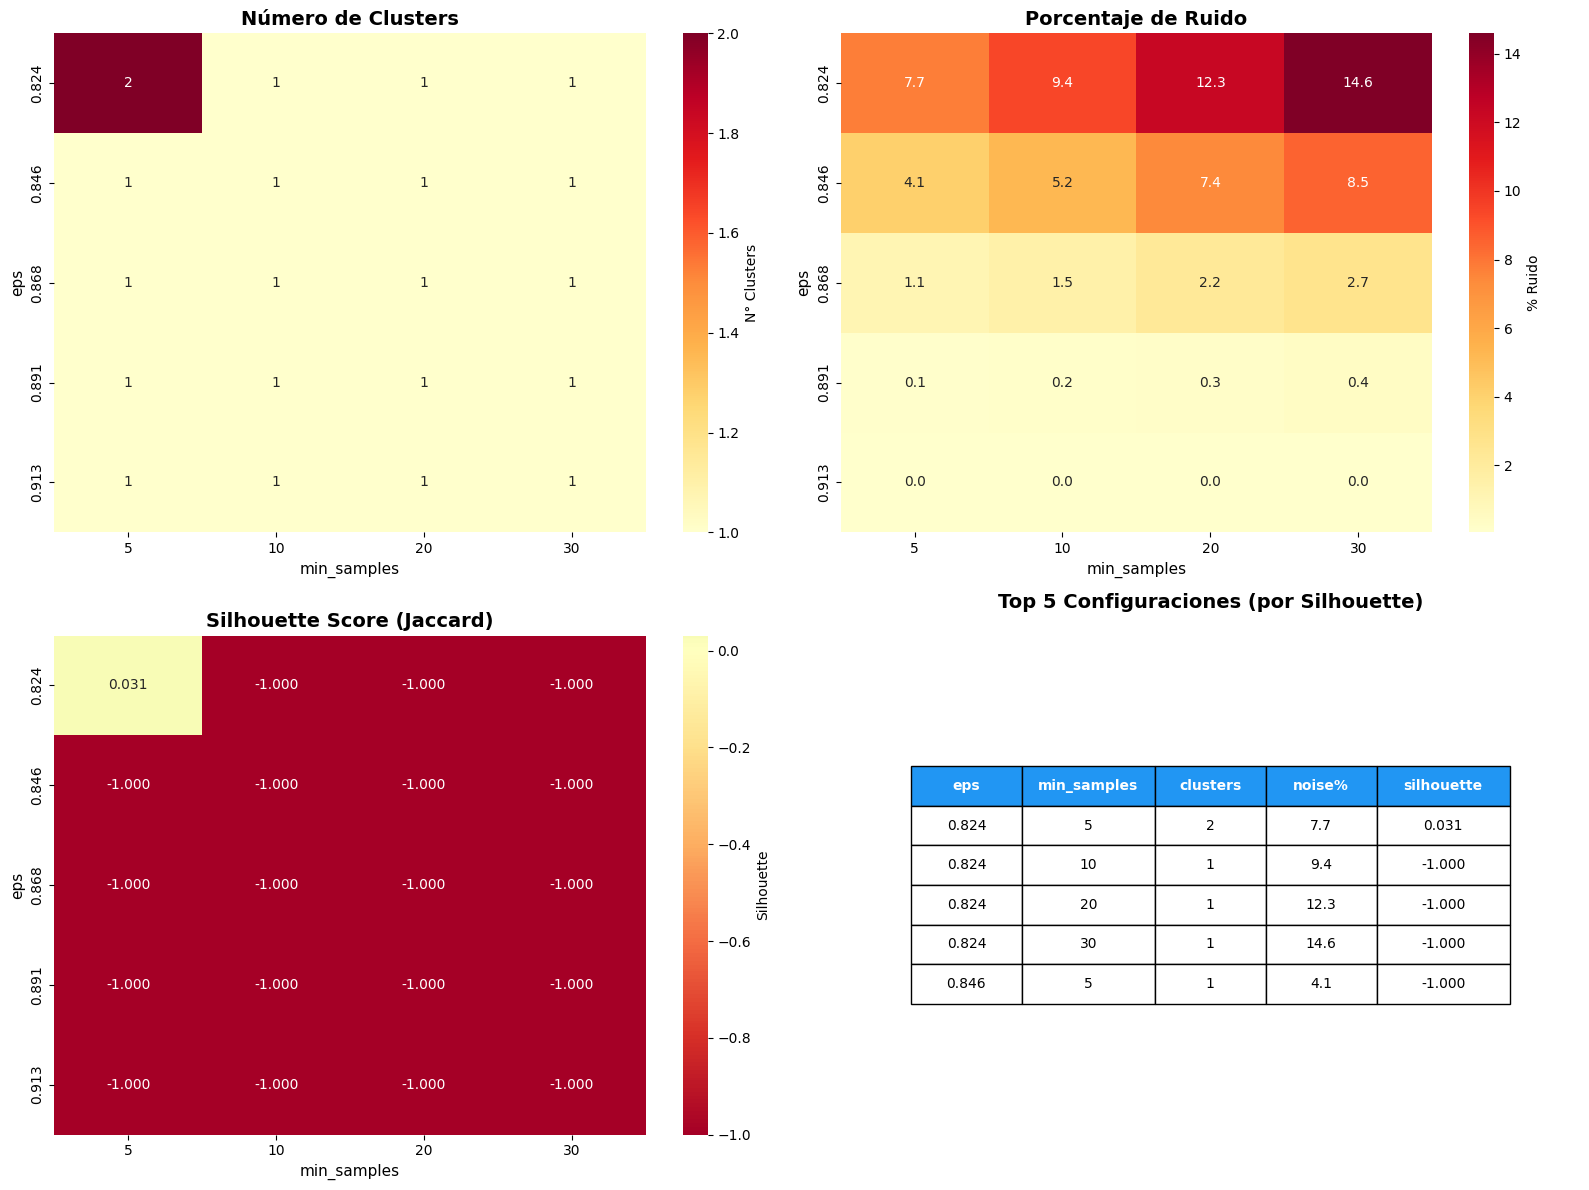


ENTRENANDO MODELO FINAL

Generando visualización PCA + UMAP...
Calculando PCA...
Calculando UMAP (esto puede tardar unos minutos)...


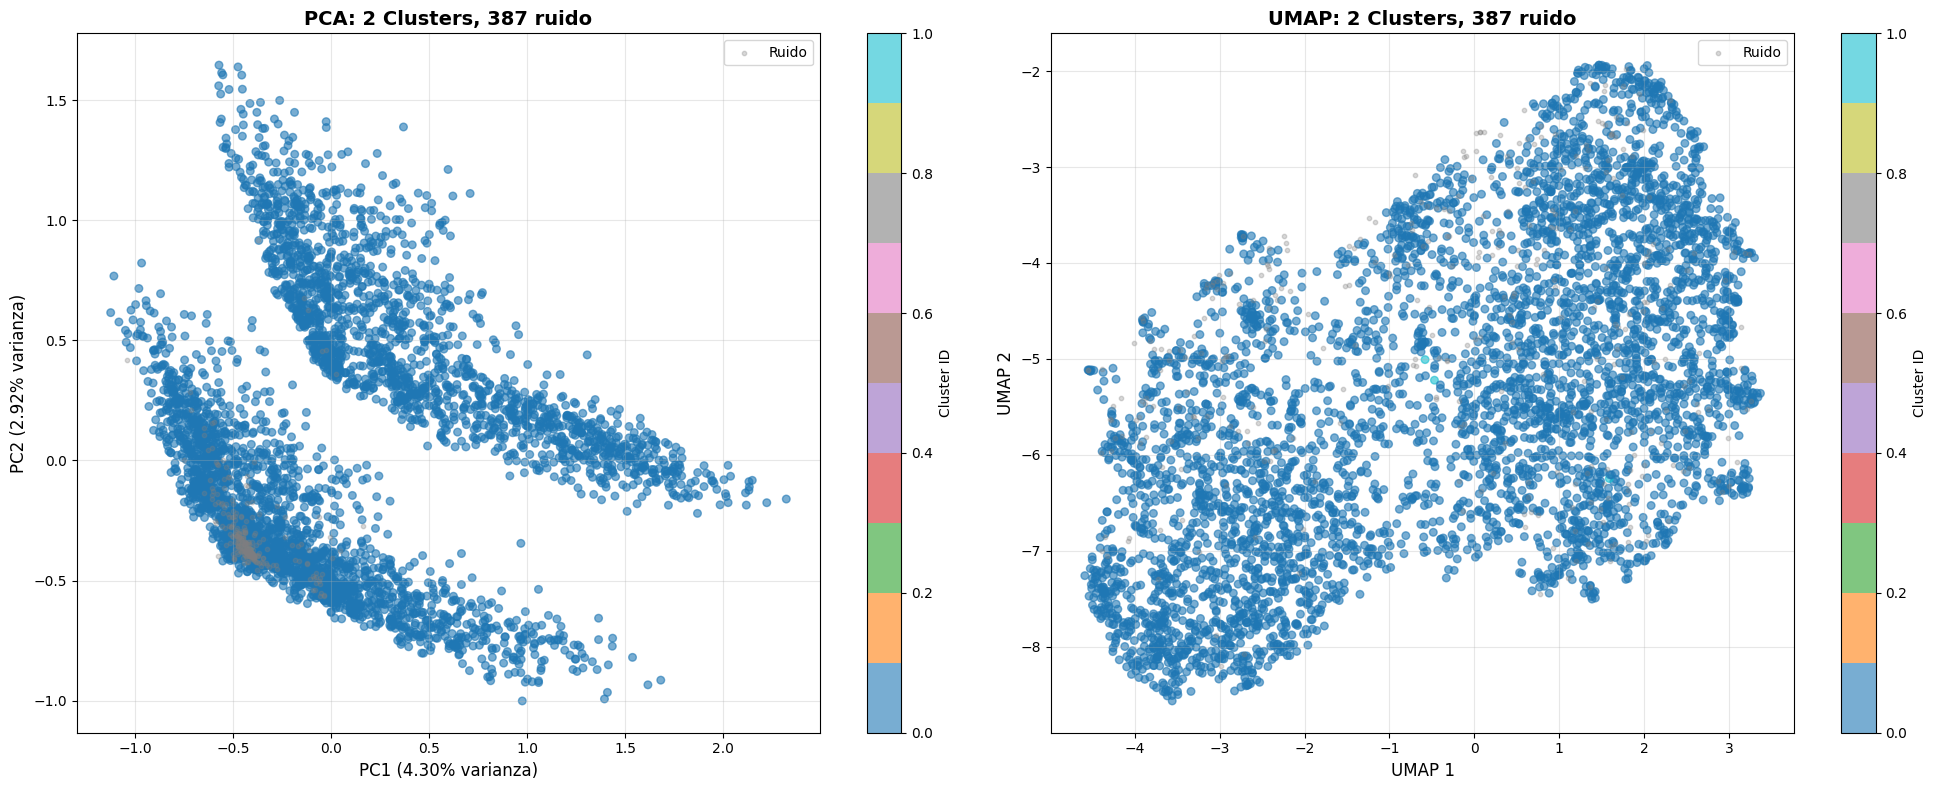

Visualización completada.
ANÁLISIS DE CLUSTERS DBSCAN

RUIDO - 387 recetas (7.74%)
Estas recetas no se ajustan bien a ningún cluster.

CLUSTER 0 - 4608 recetas (92.16%)

Top 15 ingredientes más comunes:
  • salt: 1845 recetas (40.0%)
  • butter: 1149 recetas (24.9%)
  • sugar: 977 recetas (21.2%)
  • onion: 851 recetas (18.5%)
  • eggs: 756 recetas (16.4%)
  • water: 707 recetas (15.3%)
  • olive oil: 635 recetas (13.8%)
  • flour: 595 recetas (12.9%)
  • garlic cloves: 555 recetas (12.0%)
  • milk: 529 recetas (11.5%)
  • pepper: 447 recetas (9.7%)
  • all-purpose flour: 414 recetas (9.0%)
  • baking powder: 405 recetas (8.8%)
  • brown sugar: 403 recetas (8.7%)
  • egg: 388 recetas (8.4%)

Muestra de 3 recetas del cluster:
  - Stuffed Pork Shoulder
  - Salsa and Coke Chicken
  - coffee shoofly pie

CLUSTER 1 - 5 recetas (0.10%)

Top 15 ingredientes más comunes:
  • beer: 5 recetas (100.0%)
  • hot dog: 1 recetas (20.0%)
  • frozen limeade concentrate: 1 recetas (20.0%)
  • carbonated

In [44]:
modelo, labels, resultados = pipeline_dbscan_recetas(df_ingredientes_onehot, df_sample)

---
---

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import umap
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# FUNCIÓN PRINCIPAL SIMPLIFICADA
# ==============================================================================

def dbscan_rapido(df_ingredientes_onehot, df_original, eps, min_samples, 
                  metric='jaccard', mostrar_visualizaciones=True):
    """
    Ejecuta DBSCAN de forma rápida y muestra resultados inmediatos.
    
    Parámetros:
    -----------
    df_ingredientes_onehot : DataFrame
        Matriz binaria de ingredientes (recetas x ingredientes)
    df_original : DataFrame
        DataFrame original con información de las recetas
    eps : float
        Radio máximo de vecindad
    min_samples : int
        Número mínimo de puntos para formar un cluster
    metric : str
        Métrica de distancia ('jaccard', 'hamming', 'cosine', etc.)
    mostrar_visualizaciones : bool
        Si True, muestra gráficos PCA y UMAP
    
    Returns:
    --------
    labels : array
        Etiquetas de cluster para cada receta (-1 = ruido)
    """
    
    print("="*80)
    print(f"DBSCAN: eps={eps}, min_samples={min_samples}, metric={metric}")
    print("="*80)
    
    # Convertir a array
    X = df_ingredientes_onehot.values
    
    # Entrenar DBSCAN
    print("\n⏳ Entrenando DBSCAN...")
    clusterer = DBSCAN(eps=eps, min_samples=min_samples, metric=metric, n_jobs=-1)
    labels = clusterer.fit_predict(X)
    
    # Métricas básicas
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = (n_noise / len(labels)) * 100
    
    print(f"\n📊 RESULTADOS:")
    print(f"   • Clusters encontrados: {n_clusters}")
    print(f"   • Puntos de ruido: {n_noise} ({noise_pct:.1f}%)")
    print(f"   • Recetas en clusters: {len(labels) - n_noise}")
    
    # Silhouette score (solo si hay clusters válidos)
    if n_clusters >= 2 and n_noise < len(labels):
        labels_no_noise = labels[labels != -1]
        X_no_noise = X[labels != -1]
        if len(labels_no_noise) > 0 and len(set(labels_no_noise)) > 1:
            silhouette = silhouette_score(X_no_noise, labels_no_noise, metric=metric)
            print(f"   • Silhouette Score: {silhouette:.4f}")
    
    # Tamaños de clusters
    if n_clusters > 0:
        print(f"\n📏 TAMAÑO DE CLUSTERS:")
        cluster_sizes = pd.Series(labels[labels != -1]).value_counts().sort_index()
        for cluster_id, size in cluster_sizes.items():
            pct = (size / len(labels)) * 100
            print(f"   • Cluster {cluster_id}: {size} recetas ({pct:.1f}%)")
    
    # Visualizaciones
    if mostrar_visualizaciones and n_clusters > 0:
        visualizar_clusters(X, labels)
    
    # Análisis de clusters
    if n_clusters > 0:
        analizar_clusters(df_original, df_ingredientes_onehot, labels)
    else:
        print("\n⚠️  No se encontraron clusters. Prueba con:")
        print("   - Valores de eps más bajos")
        print("   - Valores de min_samples más bajos")
        print("   - Otra métrica de distancia")
    
    return labels


def visualizar_clusters(X, labels, max_samples=5000):
    """
    Visualiza clusters usando PCA y UMAP en paralelo.
    """
    print("\n📈 Generando visualizaciones...")
    
    # Muestreo si es necesario
    if len(X) > max_samples:
        indices = np.random.choice(len(X), max_samples, replace=False)
        X_sample = X[indices]
        labels_sample = labels[indices]
    else:
        X_sample = X
        labels_sample = labels
    
    # Separar ruido de clusters
    noise_mask = labels_sample == -1
    cluster_mask = ~noise_mask
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # === PCA ===
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_sample)
    
    # Plot clusters
    if cluster_mask.any():
        unique_clusters = np.unique(labels_sample[cluster_mask])
        n_colors = len(unique_clusters)
        colors = plt.cm.tab20(np.linspace(0, 1, n_colors))
        
        for i, cluster_id in enumerate(unique_clusters):
            mask = labels_sample == cluster_id
            axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                          c=[colors[i]], label=f'Cluster {cluster_id}',
                          alpha=0.6, s=30)
    
    # Plot ruido
    if noise_mask.any():
        axes[0].scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], 
                       c='lightgray', alpha=0.3, s=10, label='Ruido')
    
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
    axes[0].set_title('Proyección PCA', fontsize=13, fontweight='bold')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # === UMAP ===
    print("   Calculando UMAP...")
    reducer = umap.UMAP(n_components=2, metric='jaccard', 
                       n_neighbors=15, min_dist=0.1, 
                       random_state=42, verbose=False)
    X_umap = reducer.fit_transform(X_sample)
    
    # Plot clusters
    if cluster_mask.any():
        for i, cluster_id in enumerate(unique_clusters):
            mask = labels_sample == cluster_id
            axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1], 
                          c=[colors[i]], label=f'Cluster {cluster_id}',
                          alpha=0.6, s=30)
    
    # Plot ruido
    if noise_mask.any():
        axes[1].scatter(X_umap[noise_mask, 0], X_umap[noise_mask, 1], 
                       c='lightgray', alpha=0.3, s=10, label='Ruido')
    
    axes[1].set_xlabel('UMAP 1', fontsize=11)
    axes[1].set_ylabel('UMAP 2', fontsize=11)
    axes[1].set_title('Proyección UMAP', fontsize=13, fontweight='bold')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print("   ✓ Visualizaciones completadas")


def analizar_clusters(df_original, df_ingredientes_onehot, labels, top_clusters=10, top_ingredientes=5):
    """
    Muestra resumen de los top N clusters con sus ingredientes más frecuentes.
    """
    print("\n" + "="*80)
    print(f"TOP {top_clusters} CLUSTERS MÁS GRANDES")
    print("="*80)
    
    # Contar tamaños de clusters (sin ruido)
    cluster_sizes = pd.Series(labels[labels != -1]).value_counts()
    top_cluster_ids = cluster_sizes.head(top_clusters).index
    
    # Analizar cada cluster
    for cluster_id in top_cluster_ids:
        mask = labels == cluster_id
        n_recetas = mask.sum()
        pct = (n_recetas / len(labels)) * 100
        
        print(f"\n{'─'*80}")
        print(f"CLUSTER {cluster_id} → {n_recetas} recetas ({pct:.1f}%)")
        print(f"{'─'*80}")
        
        # Ingredientes más frecuentes
        ingredientes_cluster = df_ingredientes_onehot[mask]
        freq_ingredientes = ingredientes_cluster.sum().sort_values(ascending=False).head(top_ingredientes)
        
        print(f"\n🥘 Top {top_ingredientes} ingredientes:")
        for ing, freq in freq_ingredientes.items():
            freq_pct = (freq / n_recetas) * 100
            print(f"   • {ing}: {int(freq)} recetas ({freq_pct:.0f}%)")
        
        # Recetas de ejemplo
        if 'name' in df_original.columns:
            recetas_ejemplo = df_original[mask]['name'].head(5).tolist()
            print(f"\n📋 Ejemplos de recetas:")
            for i, receta in enumerate(recetas_ejemplo, 1):
                print(f"   {i}. {receta}")


# ==============================================================================
# FUNCIÓN DE EXPLORACIÓN RÁPIDA
# ==============================================================================

def explorar_parametros(df_ingredientes_onehot, df_original, 
                       eps_list, min_samples_list, metric='jaccard'):
    """
    Prueba rápidamente múltiples combinaciones y muestra resumen comparativo.
    """
    resultados = []
    
    print("="*80)
    print("EXPLORACIÓN RÁPIDA DE PARÁMETROS")
    print("="*80)
    
    X = df_ingredientes_onehot.values
    total = len(eps_list) * len(min_samples_list)
    counter = 0
    
    for eps in eps_list:
        for min_samples in min_samples_list:
            counter += 1
            print(f"\n[{counter}/{total}] Probando eps={eps}, min_samples={min_samples}...")
            
            clusterer = DBSCAN(eps=eps, min_samples=min_samples, 
                             metric=metric, n_jobs=-1)
            labels = clusterer.fit_predict(X)
            
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            noise_pct = (n_noise / len(labels)) * 100
            
            # Silhouette
            if n_clusters >= 2 and n_noise < len(labels):
                labels_no_noise = labels[labels != -1]
                X_no_noise = X[labels != -1]
                if len(labels_no_noise) > 0 and len(set(labels_no_noise)) > 1:
                    silhouette = silhouette_score(X_no_noise, labels_no_noise, metric=metric)
                else:
                    silhouette = -1
            else:
                silhouette = -1
            
            resultados.append({
                'eps': eps,
                'min_samples': min_samples,
                'clusters': n_clusters,
                'ruido': n_noise,
                'ruido_%': noise_pct,
                'silhouette': silhouette
            })
            
            print(f"   → {n_clusters} clusters, {n_noise} ruido ({noise_pct:.1f}%), silhouette={silhouette:.3f}")
    
    # Mostrar tabla resumen
    df_resultados = pd.DataFrame(resultados)
    
    print("\n" + "="*80)
    print("RESUMEN COMPARATIVO")
    print("="*80)
    print(df_resultados.to_string(index=False))
    
    # Sugerencias
    print("\n" + "="*80)
    print("💡 SUGERENCIAS")
    print("="*80)
    
    # Mejor por silhouette
    df_validos = df_resultados[df_resultados['silhouette'] > 0]
    if len(df_validos) > 0:
        mejor = df_validos.loc[df_validos['silhouette'].idxmax()]
        print(f"\n✓ Mejor configuración (silhouette):")
        print(f"   eps={mejor['eps']}, min_samples={int(mejor['min_samples'])}")
        print(f"   → {int(mejor['clusters'])} clusters, silhouette={mejor['silhouette']:.3f}")
    
    # Más clusters
    mejor_clusters = df_resultados.loc[df_resultados['clusters'].idxmax()]
    if mejor_clusters['clusters'] > 0:
        print(f"\n✓ Más clusters encontrados:")
        print(f"   eps={mejor_clusters['eps']}, min_samples={int(mejor_clusters['min_samples'])}")
        print(f"   → {int(mejor_clusters['clusters'])} clusters")
    
    # Menos ruido
    if (df_resultados['clusters'] > 0).any():
        df_con_clusters = df_resultados[df_resultados['clusters'] > 0]
        menos_ruido = df_con_clusters.loc[df_con_clusters['ruido_%'].idxmin()]
        print(f"\n✓ Menos ruido (con clusters):")
        print(f"   eps={menos_ruido['eps']}, min_samples={int(menos_ruido['min_samples'])}")
        print(f"   → {menos_ruido['ruido_%']:.1f}% ruido")
    
    return df_resultados


# ==============================================================================
# EJEMPLOS DE USO
# ==============================================================================

"""
# ===== USO BÁSICO =====
# Probar una configuración específica
labels = dbscan_rapido(
    df_ingredientes_onehot=df_ingredientes_onehot,
    df_original=df,
    eps=0.5,
    min_samples=5,
    metric='jaccard'
)

# ===== EXPLORACIÓN RÁPIDA =====
# Probar múltiples configuraciones de golpe
resultados = explorar_parametros(
    df_ingredientes_onehot=df_ingredientes_onehot,
    df_original=df,
    eps_list=[0.3, 0.4, 0.5, 0.6],
    min_samples_list=[3, 5, 10],
    metric='jaccard'
)

# ===== PROBAR OTRAS MÉTRICAS =====
# Jaccard (recomendada para datos binarios)
labels_jaccard = dbscan_rapido(df_ingredientes_onehot, df, 
                                eps=0.5, min_samples=5, metric='jaccard')

# Hamming (otra opción para datos binarios)
labels_hamming = dbscan_rapido(df_ingredientes_onehot, df, 
                                eps=0.3, min_samples=5, metric='hamming')

# Cosine (para similitud angular)
labels_cosine = dbscan_rapido(df_ingredientes_onehot, df, 
                               eps=0.4, min_samples=5, metric='cosine')

# ===== GUARDAR RESULTADOS =====
# Agregar labels al DataFrame original
df['cluster_dbscan'] = labels
print(df['cluster_dbscan'].value_counts())
"""

"\n# ===== USO BÁSICO =====\n# Probar una configuración específica\nlabels = dbscan_rapido(\n    df_ingredientes_onehot=df_ingredientes_onehot,\n    df_original=df,\n    eps=0.5,\n    min_samples=5,\n    metric='jaccard'\n)\n\n# ===== EXPLORACIÓN RÁPIDA =====\n# Probar múltiples configuraciones de golpe\nresultados = explorar_parametros(\n    df_ingredientes_onehot=df_ingredientes_onehot,\n    df_original=df,\n    eps_list=[0.3, 0.4, 0.5, 0.6],\n    min_samples_list=[3, 5, 10],\n    metric='jaccard'\n)\n\n# ===== PROBAR OTRAS MÉTRICAS =====\n# Jaccard (recomendada para datos binarios)\nlabels_jaccard = dbscan_rapido(df_ingredientes_onehot, df, \n                                eps=0.5, min_samples=5, metric='jaccard')\n\n# Hamming (otra opción para datos binarios)\nlabels_hamming = dbscan_rapido(df_ingredientes_onehot, df, \n                                eps=0.3, min_samples=5, metric='hamming')\n\n# Cosine (para similitud angular)\nlabels_cosine = dbscan_rapido(df_ingredientes_oneho

## 3. HDBSCAN

In [ ]:
def visualizar_clusters_pca(X, labels, max_samples=5000):
    """
    Visualiza los clusters usando PCA
    """
    # Muestreo si es necesario
    if len(X) > max_samples:
        indices = np.random.choice(len(X), max_samples, replace=False)
        X_sample = X[indices]
        labels_sample = labels[indices]
    else:
        X_sample = X
        labels_sample = labels
    
    # PCA
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_sample)
    
    # Visualización
    plt.figure(figsize=(14, 8))
    
    # Separar ruido de clusters
    noise_mask = labels_sample == -1
    cluster_mask = ~noise_mask
    
    # Plot clusters
    if cluster_mask.any():
        scatter = plt.scatter(
            X_pca[cluster_mask, 0], 
            X_pca[cluster_mask, 1], 
            c=labels_sample[cluster_mask], 
            cmap='tab10', 
            alpha=0.6, 
            s=30,
            label='Clusters'
        )
        plt.colorbar(scatter, label='Cluster ID')
    
    # Plot ruido
    if noise_mask.any():
        plt.scatter(
            X_pca[noise_mask, 0], 
            X_pca[noise_mask, 1], 
            c='gray', 
            alpha=0.3, 
            s=10,
            label='Ruido'
        )
    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import hdbscan
import umap
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# FUNCIONES AUXILIARES
# ==============================================================================

def evaluar_hdbscan_parametros(X, min_cluster_sizes, min_samples_list, metric='jaccard'):
    """
    Evalúa diferentes combinaciones de hiperparámetros para HDBSCAN
    
    Parámetros clave:
    - min_cluster_size: Tamaño mínimo de cluster (muy importante)
    - min_samples: Controla qué tan conservador es el algoritmo
    """
    resultados = []
    total = len(min_cluster_sizes) * len(min_samples_list)
    counter = 0
    
    for min_cluster_size in min_cluster_sizes:
        for min_samples in min_samples_list:
            counter += 1
            print(f"Evaluando {counter}/{total}: min_cluster_size={min_cluster_size}, min_samples={min_samples}...", end='\r')
            
            # Entrenar HDBSCAN
            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
                metric=metric,
                core_dist_n_jobs=-1  # Usar todos los cores
            )
            
            labels = clusterer.fit_predict(X)
            
            # Calcular métricas
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            
            # Silhouette solo si hay al menos 2 clusters y no todo es ruido
            if n_clusters >= 2 and n_noise < len(labels):
                # Calcular silhouette sin puntos de ruido
                labels_no_noise = labels[labels != -1]
                X_no_noise = X[labels != -1]
                
                if len(labels_no_noise) > 0 and len(set(labels_no_noise)) > 1:
                    silhouette = silhouette_score(X_no_noise, labels_no_noise, metric=metric)
                else:
                    silhouette = -1
            else:
                silhouette = -1
            
            # Cluster sizes (sin contar ruido)
            if n_clusters > 0:
                cluster_sizes = [sum(labels == i) for i in set(labels) if i != -1]
                min_size = min(cluster_sizes) if cluster_sizes else 0
                max_size = max(cluster_sizes) if cluster_sizes else 0
                mean_size = np.mean(cluster_sizes) if cluster_sizes else 0
            else:
                min_size = max_size = mean_size = 0
            
            resultados.append({
                'min_cluster_size': min_cluster_size,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_pct': (n_noise / len(labels)) * 100,
                'silhouette': silhouette,
                'min_cluster': min_size,
                'max_cluster': max_size,
                'mean_cluster': mean_size,
                'cluster_persistence': clusterer.cluster_persistence_ if hasattr(clusterer, 'cluster_persistence_') else None
            })
    
    print(" " * 100, end='\r')
    return pd.DataFrame(resultados)


def visualizar_evaluacion_hdbscan(df_resultados):
    """
    Visualiza los resultados de la evaluación de HDBSCAN
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Pivot tables para heatmaps
    pivot_clusters = df_resultados.pivot(
        index='min_cluster_size', 
        columns='min_samples', 
        values='n_clusters'
    )
    
    pivot_noise = df_resultados.pivot(
        index='min_cluster_size', 
        columns='min_samples', 
        values='noise_pct'
    )
    
    pivot_silhouette = df_resultados.pivot(
        index='min_cluster_size', 
        columns='min_samples', 
        values='silhouette'
    )
    
    # 1. Número de clusters
    sns.heatmap(pivot_clusters, annot=True, fmt='.0f', cmap='YlOrRd', 
                ax=axes[0, 0], cbar_kws={'label': 'N° Clusters'})
    axes[0, 0].set_title('Número de Clusters', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('min_samples', fontsize=11)
    axes[0, 0].set_ylabel('min_cluster_size', fontsize=11)
    
    # 2. Porcentaje de ruido
    sns.heatmap(pivot_noise, annot=True, fmt='.1f', cmap='YlOrRd', 
                ax=axes[0, 1], cbar_kws={'label': '% Ruido'})
    axes[0, 1].set_title('Porcentaje de Ruido', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('min_samples', fontsize=11)
    axes[0, 1].set_ylabel('min_cluster_size', fontsize=11)
    
    # 3. Silhouette Score
    sns.heatmap(pivot_silhouette, annot=True, fmt='.3f', cmap='RdYlGn', 
                ax=axes[1, 0], cbar_kws={'label': 'Silhouette'}, center=0)
    axes[1, 0].set_title('Silhouette Score (Jaccard)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('min_samples', fontsize=11)
    axes[1, 0].set_ylabel('min_cluster_size', fontsize=11)
    
    # 4. Tabla resumen de mejores configuraciones
    axes[1, 1].axis('off')
    
    # Top 5 configuraciones por silhouette
    top_configs = df_resultados.nlargest(5, 'silhouette')[
        ['min_cluster_size', 'min_samples', 'n_clusters', 'noise_pct', 'silhouette']
    ].round(3)
    
    table_data = [['min_cluster', 'min_samples', 'clusters', 'noise%', 'silhouette']]
    for _, row in top_configs.iterrows():
        table_data.append([
            f"{int(row['min_cluster_size'])}",
            f"{int(row['min_samples'])}",
            f"{int(row['n_clusters'])}",
            f"{row['noise_pct']:.1f}",
            f"{row['silhouette']:.3f}"
        ])
    
    table = axes[1, 1].table(cellText=table_data, cellLoc='center', loc='center',
                            colWidths=[0.18, 0.18, 0.15, 0.15, 0.18])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Estilo de header
    for i in range(5):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    axes[1, 1].set_title('Top 5 Configuraciones (por Silhouette)', 
                        fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()


def visualizar_clusters_pca_umap(X, labels, max_samples=5000):
    """
    Visualiza los clusters usando PCA y UMAP en paralelo
    """
    # Muestreo si es necesario
    if len(X) > max_samples:
        indices = np.random.choice(len(X), max_samples, replace=False)
        X_sample = X[indices]
        labels_sample = labels[indices]
    else:
        X_sample = X
        labels_sample = labels
    
    # Crear figura con 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Separar ruido de clusters
    noise_mask = labels_sample == -1
    cluster_mask = ~noise_mask
    n_clusters = len(set(labels_sample)) - (1 if -1 in labels_sample else 0)
    n_noise = sum(noise_mask)
    
    # === SUBPLOT 1: PCA ===
    print("Calculando PCA...")
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_sample)
    
    # Plot clusters
    if cluster_mask.any():
        scatter1 = axes[0].scatter(
            X_pca[cluster_mask, 0], 
            X_pca[cluster_mask, 1], 
            c=labels_sample[cluster_mask], 
            cmap='tab10', 
            alpha=0.6, 
            s=30
        )
        plt.colorbar(scatter1, ax=axes[0], label='Cluster ID')
    
    # Plot ruido
    if noise_mask.any():
        axes[0].scatter(
            X_pca[noise_mask, 0], 
            X_pca[noise_mask, 1], 
            c='gray', 
            alpha=0.3, 
            s=10,
            label='Ruido'
        )
    
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)', fontsize=12)
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)', fontsize=12)
    axes[0].set_title(f'PCA: {n_clusters} Clusters, {n_noise} ruido', 
                      fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # === SUBPLOT 2: UMAP ===
    print("Calculando UMAP (esto puede tardar unos minutos)...")
    reducer = umap.UMAP(
        n_components=2,
        metric='jaccard',
        n_neighbors=15,
        min_dist=0.1,
        random_state=42,
        verbose=False
    )
    X_umap = reducer.fit_transform(X_sample)
    
    # Plot clusters
    if cluster_mask.any():
        scatter2 = axes[1].scatter(
            X_umap[cluster_mask, 0], 
            X_umap[cluster_mask, 1], 
            c=labels_sample[cluster_mask], 
            cmap='tab10', 
            alpha=0.6, 
            s=30
        )
        plt.colorbar(scatter2, ax=axes[1], label='Cluster ID')
    
    # Plot ruido
    if noise_mask.any():
        axes[1].scatter(
            X_umap[noise_mask, 0], 
            X_umap[noise_mask, 1], 
            c='gray', 
            alpha=0.3, 
            s=10,
            label='Ruido'
        )
    
    axes[1].set_xlabel('UMAP 1', fontsize=12)
    axes[1].set_ylabel('UMAP 2', fontsize=12)
    axes[1].set_title(f'UMAP: {n_clusters} Clusters, {n_noise} ruido', 
                      fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print("Visualización completada.")


def analizar_clusters_hdbscan(df_original, labels, df_ingredientes, top_n=10):
    """
    Analiza las características de cada cluster
    """
    df_analisis = df_original.copy()
    df_analisis['cluster'] = labels
    
    print("="*80)
    print("ANÁLISIS DE CLUSTERS HDBSCAN")
    print("="*80)
    
    # Análisis de ruido
    n_noise = sum(labels == -1)
    if n_noise > 0:
        print(f"\n{'='*80}")
        print(f"RUIDO - {n_noise} recetas ({n_noise/len(df_analisis)*100:.2f}%)")
        print(f"{'='*80}")
        print("Estas recetas no se ajustan bien a ningún cluster.")
    
    # Análisis por cluster
    for cluster_id in sorted(set(labels)):
        if cluster_id == -1:
            continue
            
        recetas_cluster = df_analisis[df_analisis['cluster'] == cluster_id]
        n_recetas = len(recetas_cluster)
        
        print(f"\n{'='*80}")
        print(f"CLUSTER {cluster_id} - {n_recetas} recetas ({n_recetas/len(df_analisis)*100:.2f}%)")
        print(f"{'='*80}")
        
        # Ingredientes más frecuentes
        ingredientes_cluster = df_ingredientes.loc[recetas_cluster.index]
        freq_ingredientes = ingredientes_cluster.sum().sort_values(ascending=False).head(top_n)
        
        print(f"\nTop {top_n} ingredientes más comunes:")
        for ing, freq in freq_ingredientes.items():
            print(f"  • {ing}: {freq} recetas ({freq/n_recetas*100:.1f}%)")
        
        # Muestra de recetas
        if 'name' in recetas_cluster.columns:
            print(f"\nMuestra de 3 recetas del cluster:")
            for idx, row in recetas_cluster.head(3).iterrows():
                print(f"  - {row['name']}")


# ==============================================================================
# PIPELINE PRINCIPAL
# ==============================================================================

def pipeline_hdbscan_recetas(df_ingredientes_onehot, df_original, 
                             min_cluster_sizes=None, min_samples_list=None):
    """
    Pipeline completo de clustering HDBSCAN para recetas
    
    Parámetros:
    -----------
    df_ingredientes_onehot : DataFrame
        Matriz binaria de ingredientes
    df_original : DataFrame
        DataFrame original con información de las recetas
    min_cluster_sizes : list
        Lista de valores para min_cluster_size a probar
    min_samples_list : list
        Lista de valores para min_samples a probar
    """
    
    print("="*80)
    print("CLUSTERING HDBSCAN PARA RECETAS (Métrica: Jaccard)")
    print("="*80)
    print(f"\nDimensiones del dataset: {df_ingredientes_onehot.shape}")
    print(f"Sparsity: {(df_ingredientes_onehot == 0).sum().sum() / df_ingredientes_onehot.values.size * 100:.2f}%")
    
    # Valores por defecto
    if min_cluster_sizes is None:
        min_cluster_sizes = [5, 10, 20, 30]
    
    if min_samples_list is None:
        min_samples_list = [5, 10, 20, 30]
    
    print(f"\nParámetros a evaluar:")
    print(f"  • min_cluster_size: {min_cluster_sizes}")
    print(f"  • min_samples: {min_samples_list}")
    print(f"  • Total combinaciones: {len(min_cluster_sizes) * len(min_samples_list)}")
    
    # Convertir a array
    X = df_ingredientes_onehot.values
    
    # EVALUACIÓN DE HIPERPARÁMETROS
    print("\n" + "="*80)
    print("EVALUACIÓN DE HIPERPARÁMETROS")
    print("="*80)
    
    df_resultados = evaluar_hdbscan_parametros(X, min_cluster_sizes, min_samples_list)
    
    print("\nRESULTADOS COMPLETOS:")
    print(df_resultados.to_string(index=False))
    
    # RECOMENDACIÓN
    print("\n" + "="*80)
    print("RECOMENDACIÓN DE HIPERPARÁMETROS")
    print("="*80)
    
    # Filtrar configuraciones válidas (al menos 2 clusters y silhouette > 0)
    df_validos = df_resultados[
        (df_resultados['n_clusters'] >= 2) & 
        (df_resultados['silhouette'] > 0)
    ].copy()
    
    if len(df_validos) == 0:
        print("\n⚠️  ADVERTENCIA: No se encontraron configuraciones con clustering válido.")
        print("Intentando con configuraciones alternativas (al menos 1 cluster)...")
        
        # Intentar con criterios más permisivos
        df_validos = df_resultados[
            (df_resultados['n_clusters'] >= 1)
        ].copy()
        
        if len(df_validos) == 0:
            print("\n❌ No se encontró ninguna configuración que genere clusters.")
            print("Sugerencias:")
            print("  - Reduce min_cluster_size")
            print("  - Reduce min_samples")
            return None, None, df_resultados
    
    # Normalizar métricas para selección
    silhouette_range = df_validos['silhouette'].max() - df_validos['silhouette'].min()
    if silhouette_range > 0:
        df_validos['silhouette_norm'] = (df_validos['silhouette'] - df_validos['silhouette'].min()) / silhouette_range
    else:
        df_validos['silhouette_norm'] = 0.5  # Valor neutro si todos son iguales
    
    df_validos['noise_norm'] = 1 - (df_validos['noise_pct'] / 100)  # Penalizar mucho ruido
    
    # Score combinado (70% silhouette, 30% bajo ruido)
    df_validos['score_total'] = 0.7 * df_validos['silhouette_norm'] + 0.3 * df_validos['noise_norm']
    
    # Verificar que hay scores válidos
    if df_validos['score_total'].isna().all():
        print("\n❌ No se pudo calcular score válido.")
        return None, None, df_resultados
    
    mejor_config = df_validos.loc[df_validos['score_total'].idxmax()]
    
    print(f"\nCONFIGURACIÓN ÓPTIMA:")
    print(f"  • min_cluster_size: {int(mejor_config['min_cluster_size'])}")
    print(f"  • min_samples: {int(mejor_config['min_samples'])}")
    print(f"\nRESULTADOS:")
    print(f"  • Número de clusters: {int(mejor_config['n_clusters'])}")
    print(f"  • Puntos de ruido: {int(mejor_config['n_noise'])} ({mejor_config['noise_pct']:.2f}%)")
    print(f"  • Silhouette Score: {mejor_config['silhouette']:.4f}")
    print(f"  • Tamaño medio cluster: {mejor_config['mean_cluster']:.0f} recetas")
    
    # VISUALIZACIONES
    print("\n" + "="*80)
    print("GENERANDO VISUALIZACIONES")
    print("="*80)
    visualizar_evaluacion_hdbscan(df_resultados)
    
    # MODELO FINAL
    print("\n" + "="*80)
    print("ENTRENANDO MODELO FINAL")
    print("="*80)
    
    clusterer_final = hdbscan.HDBSCAN(
        min_cluster_size=int(mejor_config['min_cluster_size']),
        min_samples=int(mejor_config['min_samples']),
        metric='jaccard',
        core_dist_n_jobs=-1
    )
    
    labels_final = clusterer_final.fit_predict(X)
    
    # Visualizar
    print("\nGenerando visualización PCA + UMAP...")
    visualizar_clusters_pca_umap(X, labels_final)
    
    # Análisis
    analizar_clusters_hdbscan(df_original, labels_final, df_ingredientes_onehot, top_n=15)
    
    return clusterer_final, labels_final, df_resultados


# ==============================================================================
# EJEMPLO DE USO
# ==============================================================================

if __name__ == "__main__":
    """
    # Ejecutar pipeline completo
    modelo, labels, resultados = pipeline_hdbscan_recetas(
        df_ingredientes_onehot=df_ingredientes_onehot,
        df_original=df,
        min_cluster_sizes=[50, 100, 200, 300],
        min_samples_list=[5, 10, 20]
    )
    
    # Agregar labels al DataFrame original
    if labels is not None:
        df['cluster'] = labels
        
        # Ver distribución
        print(df['cluster'].value_counts())
    """
    
    print("Script listo para ejecutar.")
    print("\nPara usar, ejecuta:")
    print("modelo, labels, resultados = pipeline_hdbscan_recetas(df_ingredientes_onehot, df)")

Script listo para ejecutar.

Para usar, ejecuta:
modelo, labels, resultados = pipeline_hdbscan_recetas(df_ingredientes_onehot, df)


Si la mayoría de las recetas no comparten ingredientes, HDBSCAN no puede formar densidades suficientemente altas.

In [ ]:
modelo, labels, metricas = pipeline_hdbscan_recetas(df_ingredientes_onehot, df_sample)

CLUSTERING HDBSCAN PARA RECETAS (Métrica: Jaccard)

Dimensiones del dataset: (5000, 4385)
Sparsity: 99.79%

Parámetros a evaluar:
  • min_cluster_size: [10]
  • min_samples: [15]
  • Total combinaciones: 1

EVALUACIÓN DE HIPERPARÁMETROS
                                                                                                    
RESULTADOS COMPLETOS:
 min_cluster_size  min_samples  n_clusters  n_noise  noise_pct  silhouette  min_cluster  max_cluster  mean_cluster cluster_persistence
               10           15           0     5000      100.0          -1            0            0             0                  []

RECOMENDACIÓN DE HIPERPARÁMETROS

⚠️  ADVERTENCIA: No se encontraron configuraciones con clustering válido.
Considera ajustar los rangos de hiperparámetros.


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Visualiza el conjunto de datos original (la proyección 2D obtenida con <code>UMAP</code>) 
    coloreando cada punto según el <strong>cluster</strong> al que pertenece. 
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Para interpretar el clustering y comprobar su coherencia, selecciona los <strong>10 clusters</strong> más grandes y muestra, para cada uno:
  <ol>
    <li>
      Las <strong>5 recetas más cercanas al centroide</strong> del cluster (si el método lo define). 
      Si no hay centroide, usa el <em>centroide empírico</em> (media del vector del cluster) o el <em>medoide</em> 
      (receta con menor distancia media al resto). Emplea una métrica adecuada a la representación.
    </li>
    <li>
      También, para cada cluster, muestra los <strong>ingredientes más repetidos</strong> del cluster (por ejemplo, top-3 o top-5), opcionalmente puedes indicar su frecuencia relativa
      para caracterizar el “tema” del grupo. Puedes agrupar y contar con utilidades tipo 
      <code>Counter</code> o transformaciones previas del one-hot.
    </li>
  </ol>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Analiza los resultados del clustering y valora si los <strong>clusters obtenidos tienen sentido</strong> 
    desde un punto de vista culinario. Observa los ingredientes más frecuentes y las recetas prototipo 
    de cada grupo, e identifica si existe un patrón claro que relacione los platos entre sí.
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Compara los resultados obtenidos en este apartado (basados en la representación <strong>one-hot de ingredientes</strong>)
    con los del primer apartado (embeddings semánticos generados con <strong>MiniLM</strong>).
    Analiza si los grupos que aparecen son similares o diferentes, reflexiona sobre cómo influye el tipo de representación y explica las principales diferencias observadas.
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Reflexiona sobre los posibles <strong>casos de uso</strong> de los dos enfoques de clustering aplicados:
  <ul>
    <li>
      ¿Para qué tipo de problema o aplicación sería más útil el clustering basado en los 
      <strong>embeddings semánticos</strong> (MiniLM)?
    </li>
    <li>
      ¿Y en qué tipo de situación resultaría más adecuado el clustering obtenido con la 
      <strong>representación one-hot de ingredientes</strong>?
    </li>
  </ul>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Piensa en <strong>otras maneras de generar una representación</strong> de las recetas, distintas de las vistas en la práctica 
    (como los embeddings semánticos o los vectores one-hot de ingredientes). 
    Describe brevemente cómo construirías esa nueva representación y qué tipo de información capturaría.
</div>